In [500]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import pandas as pd 
import numpy as np
import scipy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from scipy.stats import chi2_contingency
import scipy.stats as stats
import warnings

from math import ceil
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from collections import Counter

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.feature_selection import VarianceThreshold
import plotly.express as px
import joblib

import hdbscan
from sklearn.metrics.pairwise import haversine_distances
from sklearn_extra.cluster import KMedoids

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)



# 0. Import Datasets:

In [501]:
customers_db = pd.read_csv("datasets/customer_db_with_outliers.csv", sep=",", index_col=0)
flights_db = pd.read_csv("datasets/flights_db_with_outliers.csv", sep=",", index_col=0)

# Dataset Merging with Temporal Information Preservation

### Merging Strategy
We begin by aligning customer and flight datasets using `Loyalty#` as the common key. To ensure consistency and avoid join issues, the key is explicitly cast to an integer type in both datasets. A **left join** is then applied so that all customers are retained in the merged dataset, even if they have no associated flight records.

At this stage, the datasets are successfully merged at the record level, preserving all customer attributes alongside their corresponding flight entries.

---

### Problem: Loss of Temporal Granularity in Standard Merges
A straightforward merge is not sufficient when the data contains **time-dependent information**. Each customer can have multiple flight records across different months, and simply aggregating after a merge risks losing:
- Month-wise flight activity
- Seasonal and usage patterns
- Information about when a customer was active or inactive

In particular, `Year` and `Month` exist at the flight level, and without special handling, this temporal structure cannot be preserved in a single customer-level table.

---

### Solution: Explicit Year–Month Construction and Controlled Aggregation
To address this, a `YearMonth` feature is explicitly created in `YYYY-MM` format. This acts as a stable temporal key that allows us to:
- Track customer activity at a monthly resolution
- Aggregate flight data without collapsing the time dimension prematurely

Using this key, multiple controlled aggregations are performed:
- **Customer-level aggregation** to preserve static attributes and summarize overall flight behavior
- **Month-wise indicators and counts** to capture whether a customer flew in a given month and how frequently
- **Activity window features** to identify first activity, last activity, total active months, and recency

---

### Action Taken
- Performed a left merge to retain all customer records
- Created a `YearMonth` temporal key to preserve monthly flight information
- Aggregated customer attributes and flight metrics in a structured manner
- Generated additional tables to explicitly retain month-wise usage patterns
- Merged all components into a final customer-level dataset that preserves both **behavioral totals** and **temporal dynamics**

This approach ensures that no critical time-based information is lost during merging, while still producing a clean, model-ready customer table.
# 1. Merge Customer and Flight Data

In [502]:
customers_db['Loyalty#'] = customers_db['Loyalty#'].astype(int)
flights_db['Loyalty#'] = flights_db['Loyalty#'].astype(int)
customer_flights_combined = pd.merge(customers_db, flights_db, on='Loyalty#', how='left')
customer_flights_combined.columns.values

array(['Loyalty#', 'Customer Name', 'Province or State', 'City',
       'Latitude', 'Longitude', 'Postal code', 'Gender', 'Education',
       'Location Code', 'Income', 'Marital Status', 'LoyaltyStatus',
       'EnrollmentDateOpening', 'Customer Lifetime Value',
       'EnrollmentType', 'IsCancelled', 'Tenure_months', 'Year', 'Month',
       'YearMonthDate', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'avg_distance_per_flight',
       'companion_share'], dtype=object)

In [503]:
customer_flights_combined["YearMonth"] = (
    customer_flights_combined["Year"].astype(str)
    + "-"
    + customer_flights_combined["Month"].astype(str).str.zfill(2)
)

customer_agg = (
    customer_flights_combined
    .groupby("Loyalty#", as_index=False)
    .agg(
        customer_name=("Customer Name", "first"),
        province=("Province or State", "first"),
        city=("City", "first"),
        latitude=("Latitude", "first"),
        longitude=("Longitude", "first"),
        postal_code=("Postal code", "first"),
        gender=("Gender", "first"),
        education=("Education", "first"),
        location_code=("Location Code", "first"),
        income=("Income", "first"),
        marital_status=("Marital Status", "first"),
        loyalty_status=("LoyaltyStatus", "first"),
        enrollment_date=("EnrollmentDateOpening", "first"),
        enrollment_type=("EnrollmentType", "first"),
        customer_lifetime_value=("Customer Lifetime Value", "first"),
        is_cancelled=("IsCancelled", "max"),
        tenure_months=("Tenure_months", "max"),
        NumFlights=("NumFlights", "sum"),
        NumFlightsWithCompanions=("NumFlightsWithCompanions", "sum"),
        DistanceKM=("DistanceKM", "sum"),
        PointsAccumulated=("PointsAccumulated", "sum"),
        PointsRedeemed=("PointsRedeemed", "sum"),
        DollarCostPointsRedeemed=("DollarCostPointsRedeemed", "sum"),
    )
)


flights_count_ym = (
    customer_flights_combined
    .groupby(["Loyalty#", "YearMonth"])["NumFlights"]
    .sum()
    .unstack(fill_value=0)
    .add_prefix("flights_taken_")
    .reset_index()
)

usage_window = (
    customer_flights_combined
    .groupby("Loyalty#", as_index=False)
    .agg(
        last_active_month=("YearMonth", "max"),
    )
)

final_customer_table = (
    customer_agg
    .merge(usage_window, on="Loyalty#", how="left")
    .merge(flights_count_ym, on="Loyalty#", how="left")
)

customer_flights_combined = final_customer_table

## 1.1 Data Consistency and empty rows check

In [504]:
zero_not_allowed_cols = [
    "DistanceKM",
]

invalid_zero_mask = (customer_flights_combined[zero_not_allowed_cols] == 0).any(axis=1)

print(f"Rows to be dropped due to invalid zeros: {invalid_zero_mask.sum()}")

customer_flights_combined = customer_flights_combined.loc[~invalid_zero_mask].reset_index(drop=True)


Rows to be dropped due to invalid zeros: 1452


In [505]:
customer_flights_combined.columns.values

array(['Loyalty#', 'customer_name', 'province', 'city', 'latitude',
       'longitude', 'postal_code', 'gender', 'education', 'location_code',
       'income', 'marital_status', 'loyalty_status', 'enrollment_date',
       'enrollment_type', 'customer_lifetime_value', 'is_cancelled',
       'tenure_months', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'last_active_month',
       'flights_taken_2019-01', 'flights_taken_2019-02',
       'flights_taken_2019-03', 'flights_taken_2019-04',
       'flights_taken_2019-05', 'flights_taken_2019-06',
       'flights_taken_2019-07', 'flights_taken_2019-08',
       'flights_taken_2019-09', 'flights_taken_2019-10',
       'flights_taken_2019-11', 'flights_taken_2019-12',
       'flights_taken_2020-01', 'flights_taken_2020-02',
       'flights_taken_2020-03', 'flights_taken_2020-04',
       'flights_taken_2020-05', 'flights_taken_2020-06',
       'flights_taken

In [506]:
customer_flights_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14923 entries, 0 to 14922
Data columns (total 61 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  14923 non-null  int32  
 1   customer_name             14923 non-null  object 
 2   province                  14923 non-null  object 
 3   city                      14923 non-null  object 
 4   latitude                  14923 non-null  float64
 5   longitude                 14923 non-null  float64
 6   postal_code               14923 non-null  object 
 7   gender                    14923 non-null  object 
 8   education                 14923 non-null  object 
 9   location_code             14923 non-null  object 
 10  income                    14923 non-null  float64
 11  marital_status            14923 non-null  object 
 12  loyalty_status            14923 non-null  object 
 13  enrollment_date           14923 non-null  object 
 14  enroll

In [507]:
customer_flights_combined.isna().sum()[
    customer_flights_combined.isna().sum() > 0
].sort_values(ascending=False)



Series([], dtype: int64)

# 2 Feature Engineering

## 2.1 Feature Engineering

In [508]:
fe_df = customer_flights_combined.copy()

## 2.1.1 Temporal Feature Engineering

Temporal feature engineering focuses on extracting meaningful patterns from time-based flight activity that has already been expanded into **month-level indicators and counts**. Instead of relying on raw year and month columns, this approach leverages derived monthly features to preserve temporal behavior while remaining compatible with a customer-level dataset.

---

### 1. is_peak_season_proxy

**Description**  
`is_peak_season_proxy` is a binary feature that indicates whether a customer has taken **at least one flight during peak summer months (June, July, or August)**. A value of 1 represents any flight activity in these months, while 0 indicates no summer travel.

**Why this feature is created**  
Direct indicators for travel purpose, holidays, or vacation periods are not available in the dataset. However, summer months are strongly associated with leisure and vacation travel. Since flight activity has already been transformed into month-specific features (`flight_taken_YYYY-MM`), this proxy allows us to detect peak-season behavior without reintroducing raw temporal columns.

**How it will be used**  
This feature helps differentiate customers who travel during peak vacation periods from those who do not. It introduces seasonal behavioral context into downstream analysis and can support clustering or segmentation by separating leisure-oriented travelers from more routine or off-season travelers.

---

### 2. season_flight_count (Winter, Spring, Summer, Fall)

**Description**  
Seasonal flight count features represent the **total number of flights taken by a customer in each season**:
- `winter_flight_count`
- `spring_flight_count`
- `summer_flight_count`
- `fall_flight_count`

Each feature is computed by summing month-wise flight counts (`flights_taken_YYYY-MM`) that fall within the corresponding season.

**Why this feature is created**  
Month-level features provide fine-grained detail but can become high-dimensional and harder to interpret. Aggregating them into seasonal counts reduces dimensionality while still preserving meaningful temporal structure. This allows us to capture broader travel patterns without losing behavioral signal.

**How it will be used**  
These features quantify how a customer’s travel is distributed across seasons. They can be used directly in clustering models or exploratory analysis to identify customers with strong seasonal preferences, such as summer-heavy or winter-heavy travelers.

---

### 3. season (Dominant Travel Season)

**Description**  
The `season` feature identifies the **dominant travel season** for each customer. It is derived by selecting the season with the highest flight count among winter, spring, summer, and fall.

**Why this feature is created**  
While seasonal counts capture volume, a single dominant season provides a concise and interpretable summary of a customer’s primary travel pattern. This reduces complexity and highlights behavioral tendencies in a categorical form.

**How it will be used**  
After encoding, this feature can be used in clustering and segmentation to group customers based on their predominant travel season. It also improves interpretability by making seasonal preferences explicit in the final customer profile.

---

### Summary

The temporal features in this section are derived entirely from **month-wise flight indicators and counts**, ensuring that temporal information is preserved even after aggregation. Together, these features capture peak-season behavior, seasonal intensity, and dominant travel periods, enabling richer behavioral insights and more meaningful customer segmentation based on *when* customers travel.


In [509]:
summer_cols = [
    c for c in fe_df.columns
    if c.startswith("flights_taken_")
    and c.endswith(("-06", "-07", "-08"))
]

fe_df["is_peak_season_proxy"] = (fe_df[summer_cols].sum(axis=1) > 0).astype(int)


season_months = {
    "winter": ("-12", "-01", "-02"),
    "spring": ("-03", "-04", "-05"),
    "summer": ("-06", "-07", "-08"),
    "fall":   ("-09", "-10", "-11"),
}

for season, suffixes in season_months.items():
    cols = [
        c for c in fe_df.columns
        if c.startswith("flights_taken_") and c.endswith(suffixes)
    ]
    fe_df[f"{season}_flight_count"] = fe_df[cols].sum(axis=1)

fe_df["season"] = (
    fe_df[["winter_flight_count", "spring_flight_count",
           "summer_flight_count", "fall_flight_count"]]
    .idxmax(axis=1)
    .str.replace("_flight_count", "")
)
fe_df = fe_df.drop(
    columns=[c for c in fe_df.columns if c.startswith("flights_taken_")]
)

In [510]:
fe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14923 entries, 0 to 14922
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  14923 non-null  int32  
 1   customer_name             14923 non-null  object 
 2   province                  14923 non-null  object 
 3   city                      14923 non-null  object 
 4   latitude                  14923 non-null  float64
 5   longitude                 14923 non-null  float64
 6   postal_code               14923 non-null  object 
 7   gender                    14923 non-null  object 
 8   education                 14923 non-null  object 
 9   location_code             14923 non-null  object 
 10  income                    14923 non-null  float64
 11  marital_status            14923 non-null  object 
 12  loyalty_status            14923 non-null  object 
 13  enrollment_date           14923 non-null  object 
 14  enroll

In [511]:
fe_df.describe(include="all")

,Loyalty#,customer_name,province,city,latitude,longitude,postal_code,gender,education,location_code,income,marital_status,loyalty_status,enrollment_date,enrollment_type,customer_lifetime_value,is_cancelled,tenure_months,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,last_active_month,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,season
count,14923.000000,14923,14923,14923,14923.000000,14923.000000,14923,14923,14923,14923,14923.000000,14923,14923,14923,14923,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923
unique,NaN,14923,11,29,NaN,NaN,46,2,5,3,NaN,3,3,2442,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Mina Smida,Ontario,Toronto,NaN,NaN,V5R 1W3,female,Bachelor,Suburban,NaN,Married,Star,2021-04-13,Standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12,NaN,NaN,NaN,NaN,NaN,summer
freq,NaN,1,4829,3009,NaN,NaN,2961,7471,9318,5061,NaN,8650,6863,23,13831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14739,NaN,NaN,NaN,NaN,NaN,7040
mean,549176.637807,NaN,NaN,NaN,47.169153,-91.842905,NaN,NaN,NaN,NaN,37692.527307,NaN,NaN,NaN,NaN,7944.771725,0.075186,82.945721,156.766267,39.517724,312011.007492,31194.957266,9438.030885,93.269450,NaN,0.929706,33.945587,36.577163,50.055083,36.188434,NaN
std,258365.217281,NaN,NaN,NaN,3.305936,22.245932,NaN,NaN,NaN,NaN,30413.396973,NaN,NaN,NaN,NaN,6762.543018,0.263700,29.496135,69.621720,21.380966,138982.012468,13896.070635,8677.430593,85.820236,NaN,0.255651,20.204543,23.334881,29.586797,20.267512,NaN
min,100018.000000,NaN,NaN,NaN,42.984924,-135.056840,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1898.010000,0.000000,1.100000,1.000000,0.000000,473.000000,47.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,326864.000000,NaN,NaN,NaN,44.231171,-120.237660,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,3963.110000,0.000000,62.050000,114.000000,24.000000,225318.600000,22527.910000,2702.500000,27.000000,NaN,1.000000,17.000000,18.000000,27.000000,21.000000,NaN
50%,549404.000000,NaN,NaN,NaN,46.087818,-79.383186,NaN,NaN,NaN,NaN,34200.000000,NaN,NaN,NaN,NaN,5776.340000,0.000000,83.900000,171.000000,40.000000,341754.400000,34169.210000,7839.000000,77.900000,NaN,1.000000,34.000000,37.000000,50.000000,36.000000,NaN
75%,771814.500000,NaN,NaN,NaN,49.282730,-74.596184,NaN,NaN,NaN,NaN,62421.000000,NaN,NaN,NaN,NaN,8932.320000,0.000000,107.200000,208.000000,54.000000,413721.350000,41364.035000,14504.100000,143.000000,NaN,1.000000,48.000000,54.000000,71.000000,51.000000,NaN


## 2.2.2 Behavioral Feature Engineering

Behavioral feature engineering focuses on capturing **how customers travel**, not just how much they travel. These features normalize raw activity counts and introduce ratios that reflect travel intensity, engagement, and usage patterns. This normalization is especially important for clustering, as customers with similar totals may exhibit very different behaviors once tenure and usage style are taken into account.

---

### 1. flights_per_month

**Description**  
`flights_per_month` measures the average number of flights taken by a customer per active month. It reflects how frequently a customer travels over their observed activity span.

**Why this feature is created**  
Total flight counts are strongly influenced by how long a customer has been active. By normalizing the number of flights by `activity_span_months`, we enable fair comparison between customers with short and long tenures, while safely handling edge cases where the activity span may be zero.

**How it will be used**  
This feature will be used directly in clustering to distinguish frequent travelers from occasional ones. It helps identify high-engagement customers and separates consistent travel behavior from sporadic usage.

---

### 2. points_per_flight

**Description**  
`points_per_flight` represents the average number of loyalty points accumulated per flight by a customer.

**Why this feature is created**  
Raw points accumulated are largely driven by the number of flights taken. Normalizing points by flight count reveals differences in travel value per trip, which may be influenced by distance, fare type, or cabin class. Division-by-zero cases are explicitly handled to maintain numerical stability.

**How it will be used**  
This feature helps differentiate customers who earn higher value per flight from those who primarily take shorter or lower-value trips. It supports the identification of premium or long-haul traveler segments.

---

### 3. redeem_ratio

**Description**  
`redeem_ratio` measures the proportion of accumulated loyalty points that a customer has redeemed.

**Why this feature is created**  
Earning points and redeeming points represent distinct behavioral patterns. This ratio captures how actively a customer engages with the loyalty program beyond accumulation, while safely handling customers with zero accumulated points.

**How it will be used**  
This feature helps distinguish reward-focused customers from long-term accumulators who rarely redeem. It adds an engagement dimension to clustering and behavioral segmentation.

---

### 4. avg_distance_per_flight

**Description**  
`avg_distance_per_flight` captures the average distance traveled per flight by a customer.

**Why this feature is created**  
Total distance alone does not reflect trip characteristics. Normalizing distance by flight count reveals whether a customer typically takes short-haul or long-haul trips. Zero-flight cases are handled explicitly to avoid invalid values.

**How it will be used**  
This feature supports differentiation between regional travelers and long-distance travelers and contributes to identifying customer segments based on travel style.

---

### 5. companion_share

**Description**  
`companion_share` represents the proportion of flights taken with companions relative to total flights.

**Why this feature is created**  
Traveling alone versus with companions reflects different behavioral and possibly purpose-driven patterns (e.g., business vs. leisure travel). This ratio captures that behavioral signal while remaining independent of total flight volume.

**How it will be used**  
This feature helps separate solo travelers from group or family travelers and enhances behavioral clustering by incorporating travel context.

---

### Summary

The behavioral features in this section transform raw counts into normalized, interpretable metrics that capture **travel frequency, value per trip, loyalty engagement, travel distance, and companionship behavior**. Together, these features provide a more nuanced and comparable representation of customer behavior, significantly improving clustering quality and interpretability.


In [512]:
fe_df['flights_per_month'] = fe_df['NumFlights'] / fe_df['tenure_months']

fe_df['points_per_flight'] = fe_df['PointsAccumulated'] / fe_df['NumFlights']
fe_df['redeem_ratio'] = fe_df['PointsRedeemed'] / fe_df['PointsAccumulated']

fe_df["avg_distance_per_flight"] = fe_df["DistanceKM"] / fe_df["NumFlights"]

fe_df["companion_share"] = fe_df["NumFlightsWithCompanions"] / fe_df["NumFlights"]


In [513]:
fe_df.isna().sum()[
    fe_df.isna().sum() > 0
].sort_values(ascending=False)


Series([], dtype: int64)

## 2.2.3 Geographic Feature Engineering

Geographic feature engineering focuses on incorporating spatial information into the dataset to capture location-based travel patterns. Geographic features are especially important when the final objective includes geo-based clustering, as they allow the model to identify spatial similarities and regional travel behaviors among customers.

---

### 1. geo_point

**Description**  
geo_point is a composite geographic feature that represents a customer’s location as a pair of latitude and longitude coordinates. Together, these coordinates define a precise point on the Earth’s surface.

**Why this feature is created**  
Latitude and longitude stored separately are not directly suitable for spatial analysis or distance-based clustering. Combining them into a single geographic point preserves spatial relationships and enables the use of geographic distance metrics.

**How it will be used**  
This feature will be used as the foundation for geographic clustering and spatial analysis. It enables the identification of region-based customer segments, supports distance-based clustering methods, and allows analysis of geographic travel concentration. It is particularly useful for detecting clusters of customers with similar geographic origins or travel patterns.

---

### Summary

The geographic feature introduced in this section provides spatial context that complements temporal and behavioral features. By incorporating location information, the clustering process can capture regional similarities and produce more meaningful, geographically informed customer segments.


In [514]:
fe_df['geo_point'] = list(zip(fe_df['latitude'], fe_df['longitude']))

#fe_df.drop(columns=['latitude', 'longitude'], inplace=True)

## 2.2.4 Data Inconsistency check for new features

In [515]:
fe_df.isna().sum()[
    fe_df.isna().sum() > 0
].sort_values(ascending=False)

Series([], dtype: int64)

In [516]:
rule_counts = {}

rule_counts["high_flights_low_tenure_<=1m"] = (
    (fe_df["tenure_months"] <= 1) & (fe_df["NumFlights"] > 10)
).sum()

rule_counts["high_flights_low_tenure_<=3m"] = (
    (fe_df["tenure_months"] <= 3) & (fe_df["NumFlights"] > 30)
).sum()

rule_counts["distance_without_flights"] = (
    (fe_df["NumFlights"] == 0) & (fe_df["DistanceKM"] > 0)
).sum()

rule_counts["flights_without_distance"] = (
    (fe_df["NumFlights"] > 0) & (fe_df["DistanceKM"] == 0)
).sum()

rule_counts["points_without_flights"] = (
    (fe_df["NumFlights"] == 0) & (fe_df["PointsAccumulated"] > 0)
).sum()

rule_counts["flights_without_points"] = (
    (fe_df["NumFlights"] > 0) & (fe_df["PointsAccumulated"] == 0)
).sum()

rule_counts["redeemed_exceeds_accumulated"] = (
    fe_df["PointsRedeemed"] > fe_df["PointsAccumulated"]
).sum()

rule_counts["companions_exceed_flights"] = (
    fe_df["NumFlightsWithCompanions"] > fe_df["NumFlights"]
).sum()

rule_counts["seasonal_flights_exceed_total"] = (
    fe_df[
        ["winter_flight_count", "spring_flight_count",
         "summer_flight_count", "fall_flight_count"]
    ].sum(axis=1) > fe_df["NumFlights"]
).sum()

rule_counts["peak_season_flag_without_summer"] = (
    (fe_df["is_peak_season_proxy"] == 1) &
    (fe_df["summer_flight_count"] == 0)
).sum()

pd.Series(rule_counts).sort_values(ascending=False)


redeemed_exceeds_accumulated       461
high_flights_low_tenure_<=3m         3
high_flights_low_tenure_<=1m         0
distance_without_flights             0
flights_without_distance             0
points_without_flights               0
flights_without_points               0
companions_exceed_flights            0
seasonal_flights_exceed_total        0
peak_season_flag_without_summer      0
dtype: int64

In [517]:
bad_rows_mask = (
    ((fe_df["tenure_months"] <= 1) & (fe_df["NumFlights"] > 10)) |
    ((fe_df["tenure_months"] <= 3) & (fe_df["NumFlights"] > 30)) |
    ((fe_df["NumFlights"] == 0) & (fe_df["DistanceKM"] > 0)) |
    ((fe_df["NumFlights"] > 0) & (fe_df["DistanceKM"] == 0)) |
    ((fe_df["NumFlights"] == 0) & (fe_df["PointsAccumulated"] > 0)) |
    ((fe_df["NumFlights"] > 0) & (fe_df["PointsAccumulated"] == 0)) |
    (fe_df["PointsRedeemed"] > fe_df["PointsAccumulated"]) |
    (fe_df["NumFlightsWithCompanions"] > fe_df["NumFlights"]) |
    (
        fe_df[
            ["winter_flight_count", "spring_flight_count",
             "summer_flight_count", "fall_flight_count"]
        ].sum(axis=1) > fe_df["NumFlights"]
    ) |
    (
        (fe_df["is_peak_season_proxy"] == 1) &
        (fe_df["summer_flight_count"] == 0)
    )
)

rows_before = len(fe_df)
fe_df = fe_df.loc[~bad_rows_mask].reset_index(drop=True)
rows_after = len(fe_df)

rows_before, rows_after, rows_before - rows_after


(14923, 14459, 464)

In [518]:
fe_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  14459 non-null  int32  
 1   customer_name             14459 non-null  object 
 2   province                  14459 non-null  object 
 3   city                      14459 non-null  object 
 4   latitude                  14459 non-null  float64
 5   longitude                 14459 non-null  float64
 6   postal_code               14459 non-null  object 
 7   gender                    14459 non-null  object 
 8   education                 14459 non-null  object 
 9   location_code             14459 non-null  object 
 10  income                    14459 non-null  float64
 11  marital_status            14459 non-null  object 
 12  loyalty_status            14459 non-null  object 
 13  enrollment_date           14459 non-null  object 
 14  enroll

## 3. Discretization and Binning of Customer-Level Features

This section focuses on discretizing (binning) numerical features **after customer-level aggregation has already been completed**. No merging or aggregation is performed here. All operations assume that the input dataframe (`fe_df`) already contains **one row per customer**, with flight-level information previously summarized.

Discretization is applied to improve interpretability, reduce the influence of skewed distributions, and create stable categorical representations suitable for clustering and behavioral analysis.

---

### Distribution Analysis Using Histograms and Skewness

**Why distribution analysis was performed**  
For all selected numerical features, histograms were plotted along with mean and median indicators. Skewness values were explicitly computed and displayed for each feature.

Many customer-level metrics showed strong right skew, indicating that a small subset of customers had disproportionately high values.

**How this informed discretization**  
Using raw numerical values in such cases could distort distance-based clustering and reduce interpretability. Discretization was therefore applied to convert continuous variables into behaviorally meaningful ranges while limiting the influence of extreme values.

---

### Binned Feature Definitions and Thresholds

#### clv_band (Customer Lifetime Value)

Customer lifetime value was discretized into:
- **low_value**: up to 5,000  
- **mid_value**: 5,001 to 15,000  
- **high_value**: 15,001 to 30,000  
- **very_high_value**: above 30,000  

This separates low-impact customers from high-value and premium customers while controlling for extreme CLV values.

---

#### points_redeemed_band

Points redemption behavior was binned as:
- **none**: 0 points redeemed  
- **low**: up to 1,000 points  
- **medium**: 1,001 to 5,000 points  
- **high**: above 5,000 points  

These bands reflect increasing levels of engagement with the loyalty rewards system.

---

#### companion_flights_band

Companion travel behavior was grouped as:
- **solo_only**: no companion flights  
- **occasional_companion**: 1 to 2 companion flights  
- **family_traveler**: 3 to 6 companion flights  
- **group_traveler**: more than 6 companion flights  

These categories capture differences between solo, family, and group travel patterns.

---

#### avg_distance_per_flight_band

Average distance per flight was first computed and then discretized into:
- **no_flights**: no recorded flights  
- **short_haul_traveler**: up to 1,500 km  
- **medium_haul_traveler**: 1,501 to 3,500 km  
- **long_haul_traveler**: above 3,500 km  

This separates regional travelers from long-haul flyers.

---

#### redeem_ratio_band

Reward usage intensity was captured using redemption ratios:
- **no_points**: no accumulated points  
- **rare_redeemer**: up to 10% redeemed  
- **light_redeemer**: 10% to 40% redeemed  
- **active_redeemer**: 40% to 80% redeemed  
- **heavy_redeemer**: above 80% redeemed  

This feature highlights how actively customers convert earned points into rewards.

---

#### tenure_band

Customer tenure was discretized into lifecycle stages:
- **new_customer**: up to 12 months  
- **established**: 13 to 36 months  
- **loyal**: 37 to 72 months  
- **veteran**: more than 72 months  

These stages represent progression in customer maturity and loyalty.

---

#### income_band

Income levels were grouped into:
- **low_income**: up to 30,000  
- **mid_income**: 30,001 to 60,000  
- **upper_mid_income**: 60,001 to 100,000  
- **high_income**: above 100,000  

Income bands add socio-economic context that supports interpretation of customer segments.

---

### Missing Value Review

After discretization, missing values were explicitly reviewed to identify any remaining gaps. This step ensures transparency and allows targeted handling of incomplete data before modeling.

---

### Summary

Discretization was applied to selected customer-level numerical features after careful distribution analysis. By converting skewed continuous variables into interpretable categorical bands, this step improves clustering stability, reduces sensitivity to outliers, and produces customer segments that are easier to explain and analyze.


In [519]:
numeric_cols = [
    c for c in fe_df
        .select_dtypes(include=["int64", "float64"])
        .columns
    if c != "Loyalty#"
    and fe_df[c].nunique() > 2
    and not c.startswith("flights_taken_")
]



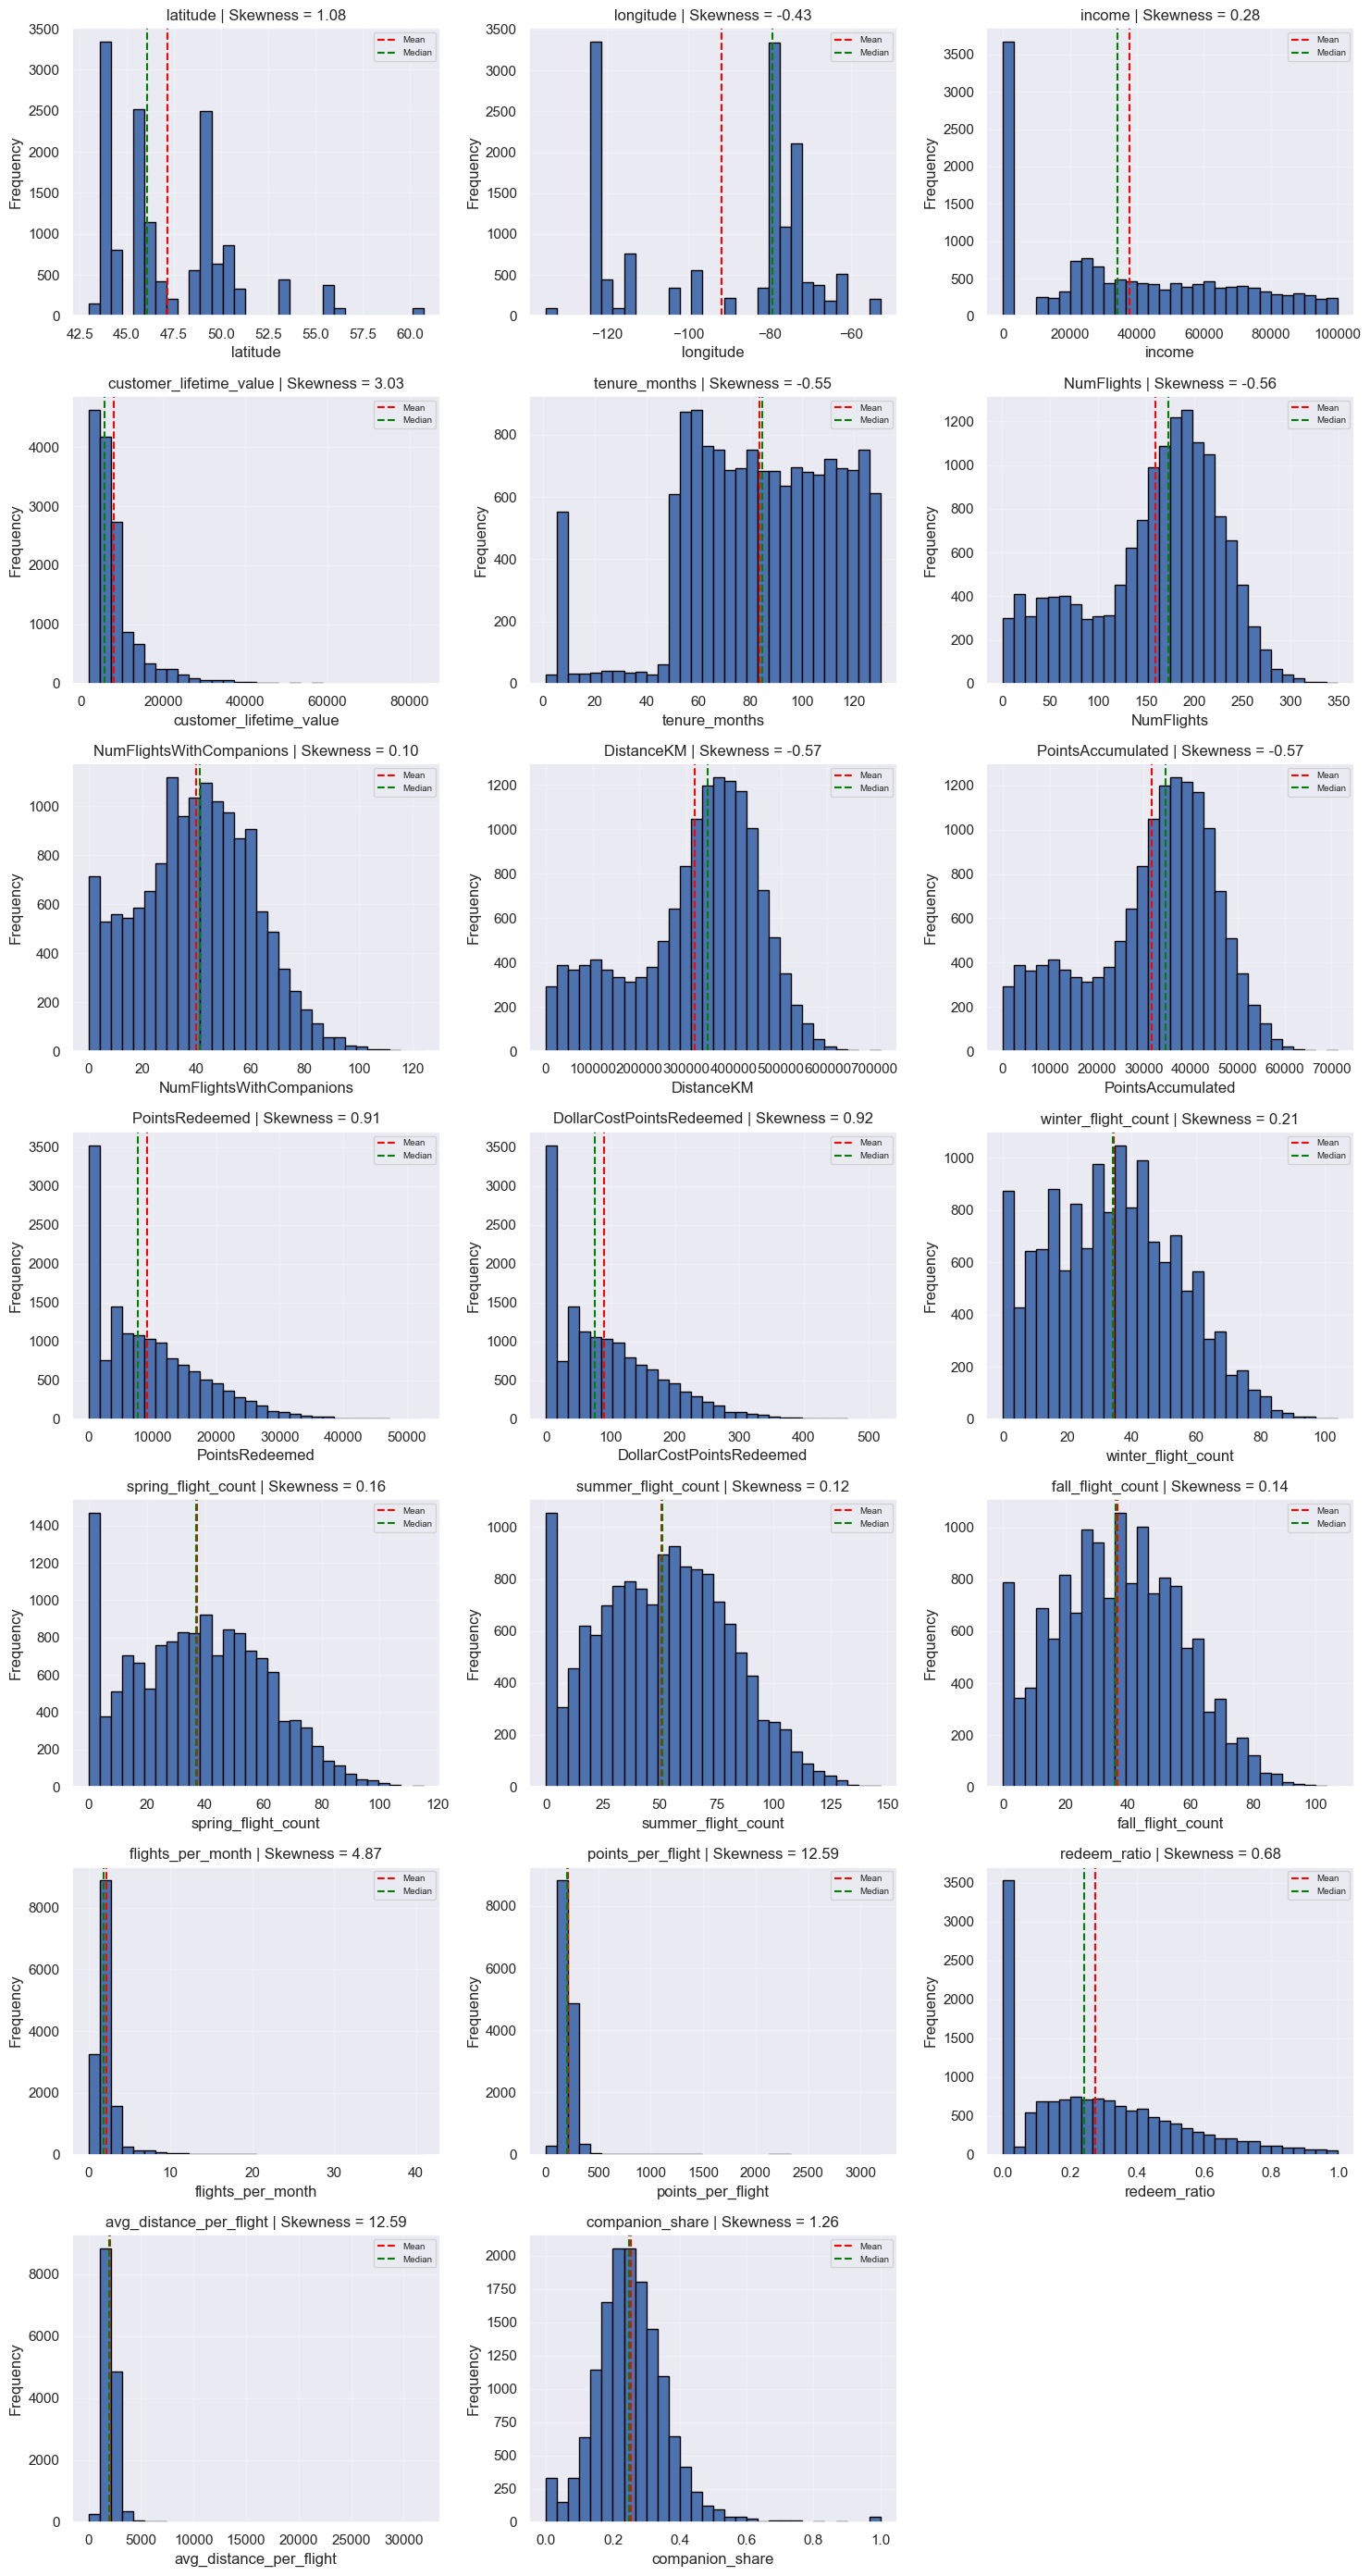

In [520]:
def plot_skewness_grid(df, cols, bins=30, figsize=(15, 4)):

    n = len(cols)
    if n == 0:
        return

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize[0], figsize[1] * nrows)
    )
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c].dropna()
        if s.empty:
            ax.set_visible(False)
            continue

        skew = s.skew()

        ax.hist(s, bins=bins, edgecolor="black")
        ax.axvline(s.mean(), color="red", linestyle="--", label="Mean")
        ax.axvline(s.median(), color="green", linestyle="--", label="Median")

        ax.set_title(f"{c} | Skewness = {skew:.2f}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()



plot_skewness_grid(fe_df, numeric_cols)

In [521]:
fe_df.describe()

,Loyalty#,latitude,longitude,income,customer_lifetime_value,is_cancelled,tenure_months,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,flights_per_month,points_per_flight,redeem_ratio,avg_distance_per_flight,companion_share
count,14459.00000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000
mean,549178.60184,47.168924,-91.875607,37752.549139,7928.935649,0.070959,83.742154,159.218687,39.939484,317680.512172,31761.818732,9194.917014,90.861692,0.937409,34.432049,37.177951,50.902483,36.706204,2.158414,209.018724,0.276025,2090.618615,0.254564
std,258338.55505,3.309556,22.255222,30386.824764,6737.293259,0.256766,29.125927,68.275695,21.180374,135777.133164,13575.647671,8369.443799,82.770837,0.242234,20.079032,23.160051,29.316182,20.093918,1.678890,90.198050,0.239922,902.105890,0.112291
min,100018.00000,42.984924,-135.056840,0.000000,1898.010000,0.000000,1.100000,1.000000,0.000000,473.000000,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017953,2.533200,0.000000,25.612000,0.000000
25%,326763.50000,44.231171,-120.237660,0.000000,3954.340000,0.000000,63.300000,120.000000,25.000000,239229.650000,23917.065000,2497.500000,24.000000,1.000000,18.000000,19.000000,29.000000,22.000000,1.437549,171.253961,0.063660,1712.889989,0.187500
50%,549612.00000,46.087818,-79.383186,34335.000000,5765.500000,0.000000,84.800000,173.000000,41.000000,345741.100000,34568.780000,7687.400000,76.000000,1.000000,34.000000,37.000000,51.000000,36.000000,1.880435,199.742126,0.242751,1997.707336,0.248227
75%,771890.50000,49.282730,-74.596184,62447.500000,8927.350000,0.000000,107.700000,208.000000,55.000000,415541.450000,41545.545000,14238.050000,140.650000,1.000000,49.000000,54.000000,72.000000,51.000000,2.411018,233.069455,0.429112,2331.181818,0.312835
max,999986.00000,60.721188,-52.712578,99981.000000,83325.380000,1.000000,130.300000,349.000000,124.000000,712729.600000,71264.460000,52556.500000,518.800000,1.000000,104.000000,115.000000,147.000000,107.000000,40.888889,3187.000000,0.998514,31875.000000,1.000000


In [522]:
fe_df['clv_band'] = pd.cut(
    fe_df['customer_lifetime_value'].fillna(0),
    bins=[-1, 5000, 15000, 30000, np.inf],
    labels=['low_value', 'mid_value', 'high_value', 'very_high_value']
)

fe_df['points_redeemed_band'] = pd.cut(
    fe_df['PointsRedeemed'].fillna(0),
    bins=[-1, 0, 1000, 5000, np.inf],
    labels=['none', 'low', 'medium', 'high']
)

fe_df['num_flights_band'] = pd.cut(
    fe_df['NumFlights'].fillna(0),
    bins=[-1, 0, 3, 8, np.inf],
    labels=['no_travel', 'occasional', 'regular', 'frequent']
)

fe_df['companion_flights_band'] = pd.cut(
    fe_df['NumFlightsWithCompanions'].fillna(0),
    bins=[-1, 0, 2, 6, np.inf],
    labels=['solo_only', 'occasional_companion', 'family_traveler', 'group_traveler']
)

fe_df['avg_distance_per_flight'] = np.where(
    fe_df['NumFlights'] > 0,
    fe_df['DistanceKM'] / fe_df['NumFlights'],
    0
)

fe_df['avg_distance_per_flight_band'] = pd.cut(
    fe_df['avg_distance_per_flight'],
    bins=[-1, 0, 1500, 3500, np.inf],
    labels=['no_flights', 'short_haul_traveler', 'medium_haul_traveler', 'long_haul_traveler']
)

fe_df['redeem_ratio'] = np.where(
    fe_df['PointsAccumulated'] > 0,
    fe_df['PointsRedeemed'] / fe_df['PointsAccumulated'],
    0
)

fe_df['redeem_ratio_band'] = pd.cut(
    fe_df['redeem_ratio'],
    bins=[-1, 0, 0.1, 0.4, 0.8, np.inf],
    labels=['no_points', 'rare_redeemer', 'light_redeemer', 'active_redeemer', 'heavy_redeemer']
)

fe_df['tenure_band'] = pd.cut(
    fe_df['tenure_months'].fillna(0),
    bins=[-1, 12, 36, 72, np.inf],
    labels=['new_customer', 'established', 'loyal', 'veteran']
)

fe_df['income_band'] = pd.cut(
    fe_df['income'].fillna(0),
    bins=[-1, 30000, 60000, 100000, np.inf],
    labels=['low_income', 'mid_income', 'upper_mid_income', 'high_income']
)
fe_df.isna().sum()[
    fe_df.isna().sum() > 0
].sort_values(ascending=False)

Series([], dtype: int64)

In [523]:
fe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Loyalty#                      14459 non-null  int32   
 1   customer_name                 14459 non-null  object  
 2   province                      14459 non-null  object  
 3   city                          14459 non-null  object  
 4   latitude                      14459 non-null  float64 
 5   longitude                     14459 non-null  float64 
 6   postal_code                   14459 non-null  object  
 7   gender                        14459 non-null  object  
 8   education                     14459 non-null  object  
 9   location_code                 14459 non-null  object  
 10  income                        14459 non-null  float64 
 11  marital_status                14459 non-null  object  
 12  loyalty_status                14459 non-null  

In [524]:
cols_to_drop = [
    "customer_lifetime_value",
    "PointsRedeemed",
    "NumFlights",
    "NumFlightsWithCompanions",
    "DistanceKM",
    "tenure_months",
    "income",
    "avg_distance_per_flight",
    "redeem_ratio"
]

fe_df.drop(columns=cols_to_drop, inplace=True)


In [525]:
fe_df.filter(like="_band").head()


,clv_band,points_redeemed_band,num_flights_band,companion_flights_band,avg_distance_per_flight_band,redeem_ratio_band,tenure_band,income_band
0,mid_value,high,frequent,group_traveler,medium_haul_traveler,light_redeemer,veteran,upper_mid_income
1,low_value,high,frequent,group_traveler,short_haul_traveler,active_redeemer,veteran,low_income
2,low_value,medium,frequent,group_traveler,medium_haul_traveler,light_redeemer,veteran,low_income
3,low_value,high,frequent,group_traveler,medium_haul_traveler,light_redeemer,veteran,mid_income
4,mid_value,high,frequent,group_traveler,medium_haul_traveler,light_redeemer,veteran,upper_mid_income


In [526]:
numeric_cols = [
    c for c in fe_df
        .select_dtypes(include=["int64", "float64"])
        .columns
    if c != "Loyalty#"
    and fe_df[c].nunique() > 2
    and not c.startswith("flights_taken_")
]

# OUTLIERS (IQR):

In [527]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

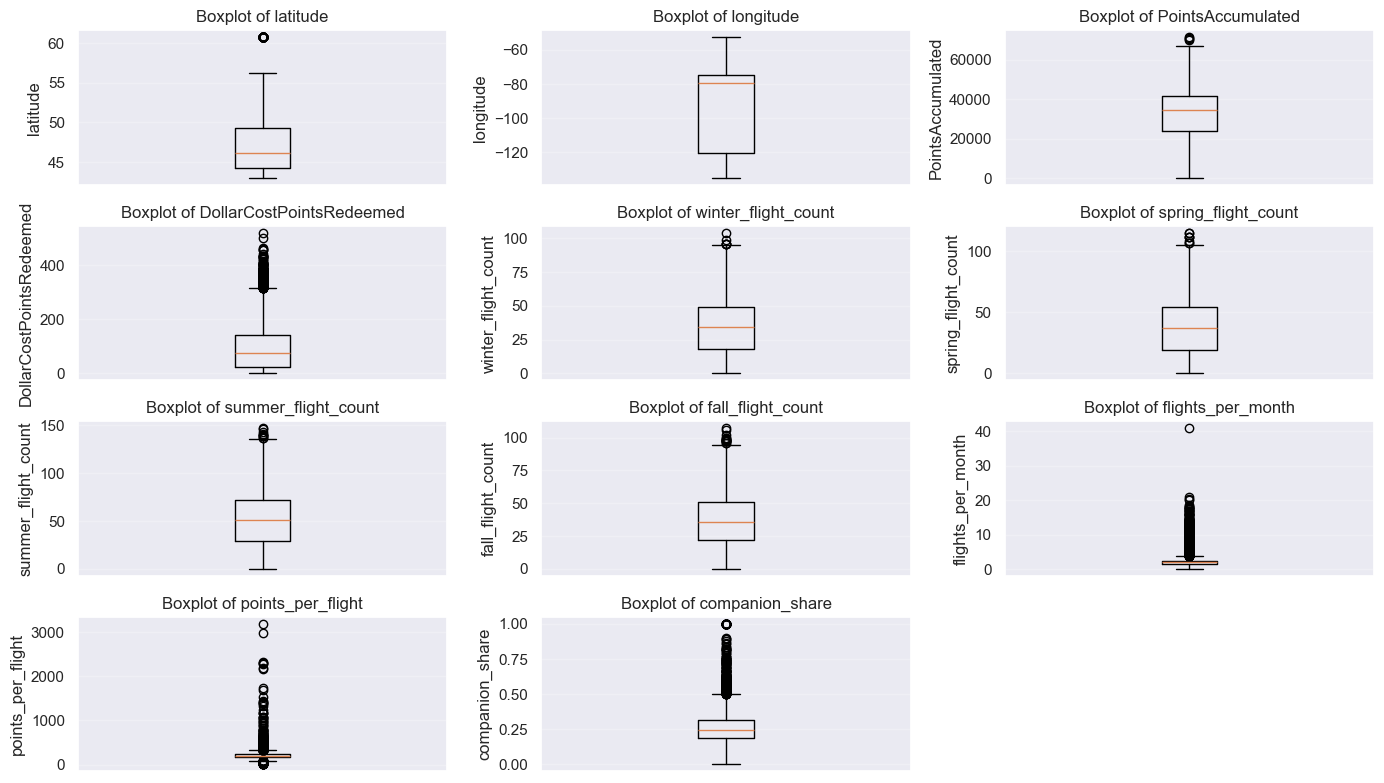

In [528]:
boxplot_grid(fe_df, numeric_cols, ncols=3, figsize=(14, 8), showfliers=True)

In [529]:
def iqr_outlier_summary(df: pd.DataFrame, cols, k: float = 1.5):

    rows = []
    masks = {}

    n = len(df)

    for col in cols:
        s = df[col].dropna()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        mask = (df[col] < lower) | (df[col] > upper)
        n_out = mask.sum()
        pct_out = n_out / n * 100

        masks[col] = mask

        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": n_out,
            "pct_outliers": pct_out
        })

    summary_df = pd.DataFrame(rows)

    print("-" * 70)
    print("IQR outlier summary")
    print("-" * 70)
    for _, r in summary_df.iterrows():
        print(f"Feature        : {r['feature']}")
        print(f"  Q1           : {r['Q1']:.3f}")
        print(f"  Q3           : {r['Q3']:.3f}")
        print(f"  IQR          : {r['IQR']:.3f}")
        print(f"  Lower bound  : {r['lower_bound']:.3f}")
        print(f"  Upper bound  : {r['upper_bound']:.3f}")
        print(f"  Outliers     : {int(r['n_outliers'])} "
              f"({r['pct_outliers']:.2f}% of rows)")
        print("-" * 70)

    return summary_df, masks


In [530]:
iqr_summary, iqr_masks = iqr_outlier_summary(fe_df, numeric_cols)

----------------------------------------------------------------------
IQR outlier summary
----------------------------------------------------------------------
Feature        : latitude
  Q1           : 44.231
  Q3           : 49.283
  IQR          : 5.052
  Lower bound  : 36.654
  Upper bound  : 56.860
  Outliers     : 97 (0.67% of rows)
----------------------------------------------------------------------
Feature        : longitude
  Q1           : -120.238
  Q3           : -74.596
  IQR          : 45.641
  Lower bound  : -188.700
  Upper bound  : -6.134
  Outliers     : 0 (0.00% of rows)
----------------------------------------------------------------------
Feature        : PointsAccumulated
  Q1           : 23917.065
  Q3           : 41545.545
  IQR          : 17628.480
  Lower bound  : -2525.655
  Upper bound  : 67988.265
  Outliers     : 4 (0.03% of rows)
----------------------------------------------------------------------
Feature        : DollarCostPointsRedeemed
  Q1      

In [531]:
manual_cols = [
    "points_per_flight",
    "flights_per_month"
]

qs = [0.99, 0.995, 0.999]  

rows = []
n = len(fe_df)

for col in manual_cols:
    s = fe_df[col].dropna()

    for q in qs:
        thr = float(s.quantile(q))
        removed_pct = 100 * (fe_df[col] > thr).mean()  
        rows.append({
            "feature": col,
            "quantile": q,
            "suggested_thr": thr,
            "pct_above_thr": removed_pct
        })

suggest_df = pd.DataFrame(rows).sort_values(["feature", "quantile"])
display(suggest_df)

,feature,quantile,suggested_thr,pct_above_thr
3,flights_per_month,0.990,10.123457,0.989003
4,flights_per_month,0.995,12.337383,0.504876
5,flights_per_month,0.999,16.919389,0.103742
0,points_per_flight,0.990,415.970671,1.002836
1,points_per_flight,0.995,556.903333,0.504876
2,points_per_flight,0.999,1381.901055,0.103742


In [532]:
q = 0.999
manual_quantile_cols = [
    "points_per_flight",
]

manual_thresholds = {
    col: float(fe_df[col].dropna().quantile(q))
    for col in manual_quantile_cols
}

base_index = customers_db.index

per_feature_flags = {}
rows = []

for col, iqr_mask in iqr_masks.items():
    iqr_mask = iqr_mask.reindex(base_index, fill_value=False)

    if col in fe_df.columns:
        x = fe_df[col].reindex(base_index)
    else:
        x = None

    if col in manual_thresholds:
        thr = manual_thresholds[col]
        manual_mask = (x > thr)
        flag = iqr_mask & manual_mask
        rule = f"IQR & manual(q={q})"

    elif col == "total_active_months":
        tam = fe_df["total_active_months"].reindex(base_index)
        ten = fe_df["tenure_months"].reindex(base_index)
        manual_mask = (tam > ten)
        flag = iqr_mask & manual_mask
        rule = "IQR & manual(tam > tenure)"

    else:
        flag = iqr_mask
        rule = "IQR"

    per_feature_flags[col] = flag

    n = int(flag.sum())
    pct = 100 * n / len(base_index)

    rows.append({
        "feature": col,
        "rule": rule,
        "n_removed_by_feature": n,
        "pct_removed_by_feature": pct
    })

summary_df = pd.DataFrame(rows).sort_values("pct_removed_by_feature", ascending=False)

out_remove_total = pd.Series(False, index=base_index)
for flag in per_feature_flags.values():
    out_remove_total |= flag

total_n = int(out_remove_total.sum())
total_pct = 100 * total_n / len(base_index)

print(f"TOTAL to remove: {total_n} / {len(base_index)}  ({total_pct:.2f}%)")
print("\nTop features by % removed:")
display(summary_df.head(20))

print("\nManual thresholds (q=0.999):")
for k, v in manual_thresholds.items():
    print(f"  {k}: {v}")

TOTAL to remove: 1412 / 16375  (8.62%)

Top features by % removed:


,feature,rule,n_removed_by_feature,pct_removed_by_feature
8,flights_per_month,IQR,848,5.178626
10,companion_share,IQR,269,1.642748
3,DollarCostPointsRedeemed,IQR,195,1.190840
0,latitude,IQR,97,0.592366
7,fall_flight_count,IQR,15,0.091603
9,points_per_flight,IQR & manual(q=0.999),15,0.091603
6,summer_flight_count,IQR,10,0.061069
5,spring_flight_count,IQR,8,0.048855
4,winter_flight_count,IQR,6,0.036641
2,PointsAccumulated,IQR,4,0.024427



Manual thresholds (q=0.999):
  points_per_flight: 1381.9010550000069


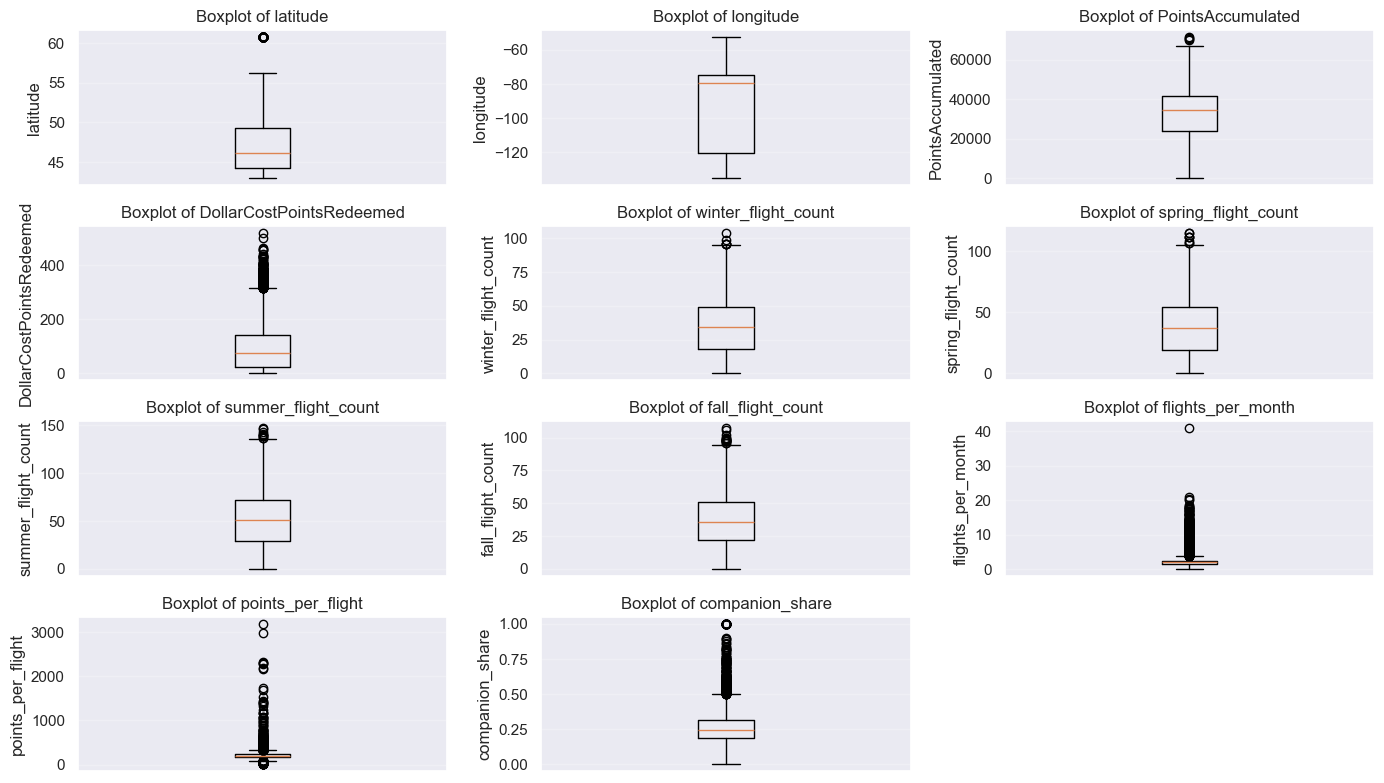

In [533]:
boxplot_grid(fe_df, numeric_cols, ncols=3, figsize=(14, 8), showfliers=True)

We identified potential outliers using a two-step strategy combining an univariate IQR rule and targeted manual filters. First, for each numeric feature we computed IQR-based bounds (Q1 − 1.5·IQR, Q3 + 1.5·IQR) and flagged observations falling outside these limits. For a small set of highly skewed, business-critical variables (e.g., points_per_flight, avg_distance_per_flight, and customer_lifetime_value), we additionally applied manual upper thresholds defined at the 99.9th percentile, and removed records only when both the IQR criterion and the corresponding manual threshold were triggered. Finally, we enforced a consistency rule by flagging and removing cases where total_active_months exceeded tenure_months, since active months cannot logically surpass the total observed membership duration.

In total we removed ~5% of the total data.

## 4. Feature Encoding

After completing feature engineering and discretization, encoding was applied to transform categorical variables into numerical representations. All encoding in this section is performed on a **single dataset (`fe_df`)**, producing an encoded dataset (`fe_df_encoded`) without changing row cardinality.

Encoding choices were driven by **cardinality and semantic meaning** of the features to ensure compatibility with clustering while preserving interpretability.

---

### Dataset Structure at This Stage

At this point in the pipeline:

- **`fe_df`** represents a customer-level dataset with one row per customer
- It contains demographic, temporal, behavioral, and discretized (binned) features
- No further aggregation or merging is performed in this step

The output of this stage is:

- **`fe_df_encoded`**, which retains the same customer-level structure with encoded categorical features

---

### Encoding Strategy Overview

Two encoding strategies are applied based on feature characteristics:

- **One-hot encoding** for low-cardinality nominal categorical features
- **Ordinal encoding** for discretized (binned) features with an inherent order

This hybrid approach balances numerical suitability for clustering with interpretability and behavioral meaning.

---

### One-Hot Encoding of Low-Cardinality Nominal Features

#### Encoded Features

One-hot encoding was applied only to categorical columns with **very few unique string values**:

- `gender`  
- `education`  
- `location_code`  
- `marital_status`  
- `loyalty_status`  
- `season`  

These features represent independent categories and do not have a natural order.

#### Why One-Hot Encoding Was Used

- These columns have **low cardinality**, keeping dimensionality manageable
- One-hot encoding avoids imposing artificial ordinal relationships
- Each category contributes independently to distance-based similarity
- All categories were retained (`drop_first=False`) to preserve interpretability  
- Multicollinearity is not a concern, as the dataset is intended for clustering rather than regression

---

### Ordinal Encoding of Discretized (Binned) Features

#### Encoded Features

All discretized features created during the binning stage were encoded using ordinal encoding:

- `clv_band`  
- `points_redeemed_band`  
- `num_flights_band`  
- `companion_flights_band`  
- `avg_distance_per_flight_band`  
- `redeem_ratio_band`  
- `tenure_band`  
- `income_band`  

---

### Choice of Ordinal Encoding

#### Why Ordinal Encoding Was Used

- These features have a **clear and meaningful order**
- Ordinal encoding preserves relative magnitude between categories
- It allows clustering algorithms to recognize progression and intensity rather than treating categories as unrelated

Examples of preserved ordering include:
- low_value < mid_value < high_value < very_high_value  
- no_travel < occasional < regular < frequent  
- new_customer < established < loyal < veteran  

#### Controlled Category Ordering

Each ordinal feature was encoded using a **predefined category order**, ensuring:
- Semantic correctness
- Consistent numerical mappings
- Reproducibility across runs

---

### Resulting Encoded Dataset

The final output, `fe_df_encoded`:
- Maintains one row per customer
- Includes one-hot encoded low-cardinality categorical features
- Includes ordinal-encoded behavioral and value-based bands
- Is fully numerical and suitable for clustering and distance-based analysis

---

### Summary

Feature encoding was applied using a principled, feature-aware strategy. Low-cardinality nominal features were one-hot encoded to preserve category independence, while discretized behavioral features were ordinally encoded to retain meaningful order. This approach ensures numerical readiness for clustering while maintaining interpretability and minimizing unnecessary dimensional expansion.


In [534]:
fe_df_encoded = fe_df.copy()

fe_categorical_cols = [
    'gender',
    'education',
    'location_code',
    'marital_status',
    'loyalty_status',
    'season',
]

fe_df_encoded = pd.get_dummies(
    fe_df_encoded,
    columns=fe_categorical_cols,
    drop_first=False
)


In [535]:
ordinal_columns = [
    'clv_band',
    'points_redeemed_band',
    'num_flights_band',
    'companion_flights_band',
    'avg_distance_per_flight_band',
    'redeem_ratio_band',
    'tenure_band',
    'income_band'
]

ordinal_categories = [
    ['low_value', 'mid_value', 'high_value', 'very_high_value'],
    ['none', 'low', 'medium', 'high'],
    ['no_travel', 'occasional', 'regular', 'frequent'],
    ['solo_only', 'occasional_companion', 'family_traveler', 'group_traveler'],
    ['no_flights', 'short_haul_traveler', 'medium_haul_traveler', 'long_haul_traveler'],
    ['no_points', 'rare_redeemer', 'light_redeemer', 'active_redeemer', 'heavy_redeemer'],
    ['new_customer', 'established', 'loyal', 'veteran'],
    ['low_income', 'mid_income', 'upper_mid_income', 'high_income']
]
fe_df_encoded = fe_df_encoded.copy()

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

fe_df_encoded[ordinal_columns] = ordinal_encoder.fit_transform(
    fe_df_encoded[ordinal_columns]
)


In [536]:
fe_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Loyalty#                        14459 non-null  int32  
 1   customer_name                   14459 non-null  object 
 2   province                        14459 non-null  object 
 3   city                            14459 non-null  object 
 4   latitude                        14459 non-null  float64
 5   longitude                       14459 non-null  float64
 6   postal_code                     14459 non-null  object 
 7   enrollment_date                 14459 non-null  object 
 8   enrollment_type                 14459 non-null  object 
 9   is_cancelled                    14459 non-null  int64  
 10  PointsAccumulated               14459 non-null  float64
 11  DollarCostPointsRedeemed        14459 non-null  float64
 12  last_active_month               

## 6. Log Transformation of Skewed Features

Before applying feature scaling, numerical variables were examined for skewness to identify distributions that could negatively affect distance-based clustering. This step focuses on reducing distributional imbalance caused by extreme values while preserving the interpretability of customer behavior.

---

### Why Log Transformation Was Necessary

Several customer-level numerical features in the dataset represent accumulated quantities or long-tailed measures, such as flight counts, monetary values, travel distance, and loyalty points. These types of features often exhibit **right-skewed distributions**, where a small subset of customers holds disproportionately large values.

If left uncorrected, such skewness can dominate distance calculations and reduce the ability of clustering algorithms to identify meaningful structure among the majority of customers.

---

### Skewness Assessment

Skewness was systematically assessed for a predefined set of candidate numerical features, including:
- Flight volume and companion travel counts
- Distance and monetary redemption metrics
- Loyalty value, tenure, and income-related attributes

The assessment combined:
- **Absolute statistical skewness values**, used to rank features by severity
- **Histogram visualizations**, used to inspect distribution shape, spread, and the presence of extreme values

This dual approach allowed both quantitative and visual identification of highly skewed variables.

---

### Selection of Log Transformation Candidates

Based on the skewness ranking and histogram inspection, the following features were selected for log transformation:
- **Customer Lifetime Value**
- **Average Distance per Flight**
- **Points Redeemed**

These features exhibited strong right skew and long-tailed distributions that could not be sufficiently corrected through discretization alone.

Other numerical features were reviewed but not transformed when:
- Skewness was comparatively lower
- The feature had already been discretized into categorical bands
- The variable represented bounded or ratio-based behavior
- Log transformation would reduce interpretability without clear benefit

---

### Application of Log Transformation

Log transformation was applied using a `log1p` function, ensuring numerical stability and safe handling of zero-valued observations. This transformation compresses extreme values while preserving relative differences among lower and mid-range observations.

---

### Effect of Log Transformation

After transformation, the selected features showed substantially reduced skewness and more symmetric distributions. Histogram comparisons before and after transformation confirmed:
- Reduced influence of extreme outliers
- Improved distribution balance
- Better suitability for subsequent scaling and clustering

---

### Why Log Transformation Was Applied Selectively

Log transformation was not applied uniformly across all numerical features.

**Reasons for selective application include:**
- Avoiding unnecessary distortion of already stable distributions
- Preserving interpretability of behavioral ratios and binned features
- Preventing over-normalization that could obscure meaningful customer differences

This selective approach ensures an effective balance between normalization and behavioral fidelity, improving clustering performance without sacrificing interpretability.

---

### Summary

Log transformation was applied selectively to a small set of highly skewed numerical features identified through statistical and visual analysis. By reducing the impact of extreme values while preserving meaningful variation, this step improves the stability and effectiveness of downstream scaling and clustering.


In [537]:
skew_check = (
    fe_df_encoded[numeric_cols]
    .skew()
    .abs()
    .sort_values(ascending=False)
)

skew_check

points_per_flight           12.588551
flights_per_month            4.874896
companion_share              1.263417
latitude                     1.083975
DollarCostPointsRedeemed     0.917278
PointsAccumulated            0.573619
longitude                    0.431032
winter_flight_count          0.205433
spring_flight_count          0.156436
fall_flight_count            0.138013
summer_flight_count          0.117851
dtype: float64

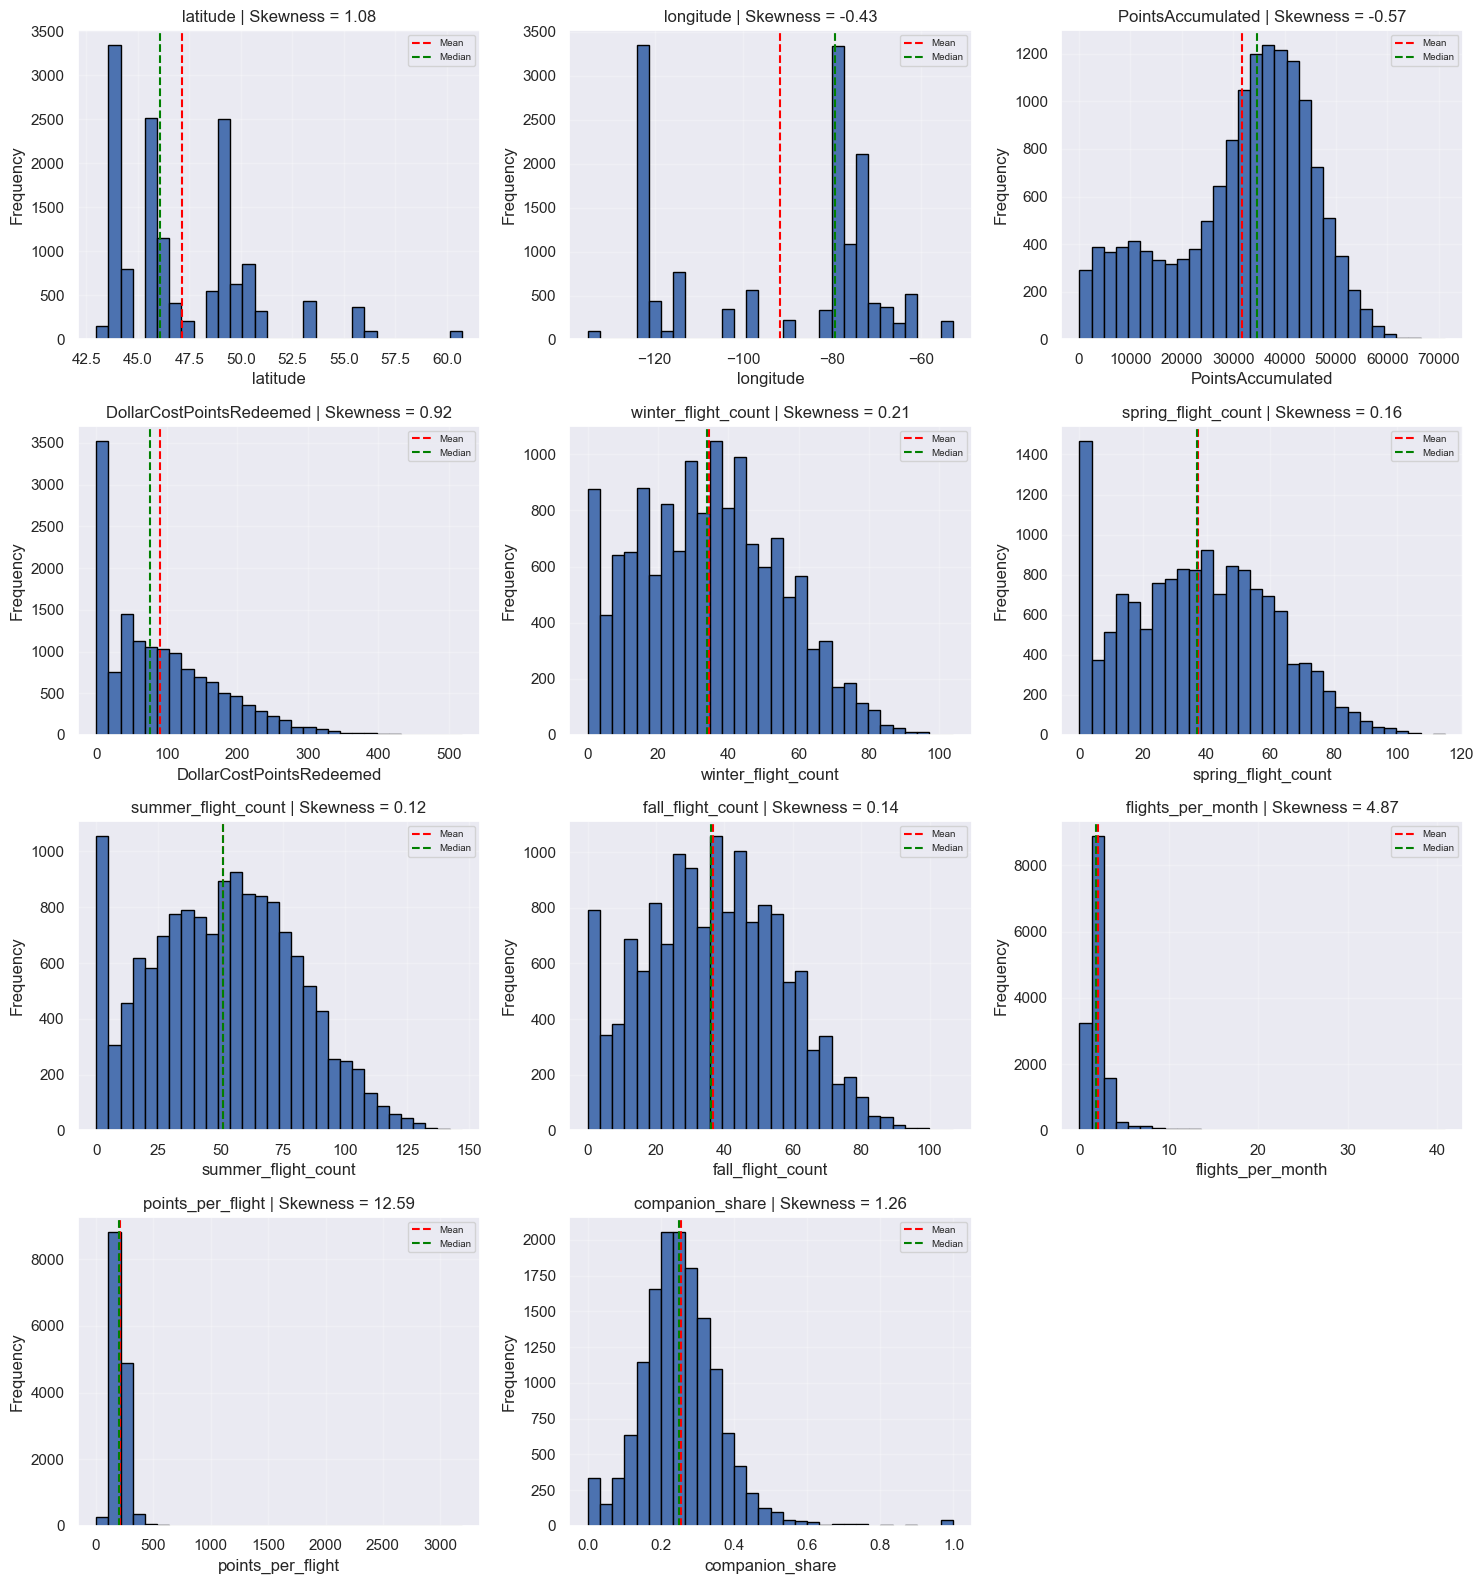

In [538]:
plot_skewness_grid(fe_df_encoded, numeric_cols)

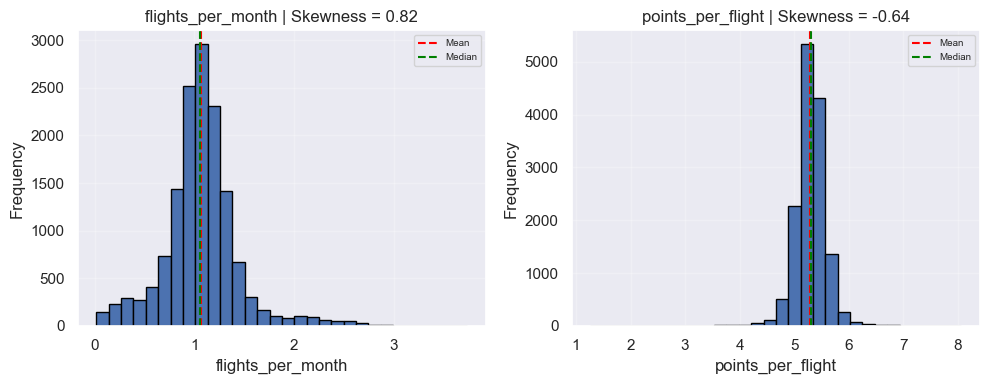

In [539]:
log_transformed_cols = ['flights_per_month', 'points_per_flight']
fe_df_log = fe_df_encoded.copy()

for col in log_transformed_cols:
    fe_df_log[col] = np.log1p(fe_df_log[col])

plot_skewness_grid(fe_df_log, log_transformed_cols)

## 7. Feature Scaling and Normalization

After addressing skewness through log transformation, numerical features were scaled to ensure equal contribution during distance-based clustering.

---

### Why Feature Scaling Is Required

The dataset contains numerical features with very different units and ranges, including:
- Counts (e.g., number of flights)
- Distances (kilometers)
- Monetary values
- Ratios and averages

Without scaling, features with larger numeric ranges would disproportionately influence similarity calculations.

---

### Scaling Strategy for Customer-Level Data

For the customer-level dataset, numerical features representing behavioral intensity, monetary value, and engagement were scaled.

**Why these features were scaled**
- They vary significantly in magnitude
- They are directly used in clustering
- Equal weighting across features is required for fair distance computation

Standardization ensures that each feature contributes proportionately.

---

### Scaling Strategy for Flight-Level Data

Numerical features in the flight-level dataset were also scaled to support consistent analysis and potential reuse for modeling or exploration.

Categorical and geographic features were excluded from scaling to preserve their original meaning and structure.

---

### Scaling Method Used

Standardization (z-score normalization) was applied.

**Why standardization was chosen**
- Centers features around zero
- Scales to unit variance
- Works well with distance-based clustering algorithms

---


In [540]:
fe_df_scaled = fe_df_log.copy()

scaler_fe = RobustScaler()

to_be_scaled_columns = numeric_cols + ordinal_columns 

fe_df_scaled[to_be_scaled_columns] = scaler_fe.fit_transform(
    fe_df_scaled[to_be_scaled_columns]
)

In [541]:
fe_df_scaled.isna().sum()[fe_df_scaled.isna().sum() > 0].sort_values(ascending=True)

Series([], dtype: int64)

In [542]:
fe_df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Loyalty#                        14459 non-null  int32  
 1   customer_name                   14459 non-null  object 
 2   province                        14459 non-null  object 
 3   city                            14459 non-null  object 
 4   latitude                        14459 non-null  float64
 5   longitude                       14459 non-null  float64
 6   postal_code                     14459 non-null  object 
 7   enrollment_date                 14459 non-null  object 
 8   enrollment_type                 14459 non-null  object 
 9   is_cancelled                    14459 non-null  int64  
 10  PointsAccumulated               14459 non-null  float64
 11  DollarCostPointsRedeemed        14459 non-null  float64
 12  last_active_month               

## 8. Feature Selection

Since clustering is an unsupervised learning task, feature selection focuses on:
- Relevancy – retaining informative features
- Redundancy – removing highly correlated features
- Dimensionality Reduction – compact representation using PCA

In [543]:
fe_df_scaled_num = fe_df_scaled.select_dtypes(include=["number"])

print("Shape of numeric feature matrix:", fe_df_scaled_num.shape)

Shape of numeric feature matrix: (14459, 22)


In [544]:
feature_variance = fe_df_scaled_num.var().sort_values()

print("Variance of each numeric feature:")
print(feature_variance)

Variance of each numeric feature:
num_flights_band                2.230374e-02
is_peak_season_proxy            5.867723e-02
is_cancelled                    6.592861e-02
avg_distance_per_flight_band    1.265830e-01
income_band                     1.748977e-01
longitude                       2.377631e-01
companion_flights_band          2.549923e-01
redeem_ratio_band               3.395884e-01
winter_flight_count             4.195292e-01
latitude                        4.292285e-01
spring_flight_count             4.378677e-01
summer_flight_count             4.648126e-01
clv_band                        4.753179e-01
fall_flight_count               4.801017e-01
DollarCostPointsRedeemed        5.034835e-01
tenure_band                     5.242085e-01
PointsAccumulated               5.930501e-01
companion_share                 8.026836e-01
points_per_flight               9.805791e-01
flights_per_month               1.267163e+00
points_redeemed_band            1.575530e+00
Loyalty#             

In [545]:
variance_threshold = 0.01

selected_features = feature_variance[feature_variance >= variance_threshold].index

X_var = fe_df_scaled_num[selected_features]

print("\nSelected features after variance filtering:")
print(selected_features)
print("Shape after variance filtering:", X_var.shape)


Selected features after variance filtering:
Index(['num_flights_band', 'is_peak_season_proxy', 'is_cancelled',
       'avg_distance_per_flight_band', 'income_band', 'longitude',
       'companion_flights_band', 'redeem_ratio_band', 'winter_flight_count',
       'latitude', 'spring_flight_count', 'summer_flight_count', 'clv_band',
       'fall_flight_count', 'DollarCostPointsRedeemed', 'tenure_band',
       'PointsAccumulated', 'companion_share', 'points_per_flight',
       'flights_per_month', 'points_redeemed_band', 'Loyalty#'],
      dtype='object')
Shape after variance filtering: (14459, 22)


Features with variance below 0.01 were considered near-constant and removed, as they provide limited information for distinguishing between observations.
Because the data was standardized, this threshold is conservative and ensures that only truly uninformative features are eliminated.

### Redundancy Analysis – Correlation Matrix
After eliminating non-informative features, a redundancy analysis is conducted to detect variables with strong correlations. Features that are highly correlated tend to represent overlapping information and may bias distance-based clustering methods. To identify this redundancy, a correlation matrix is employed.

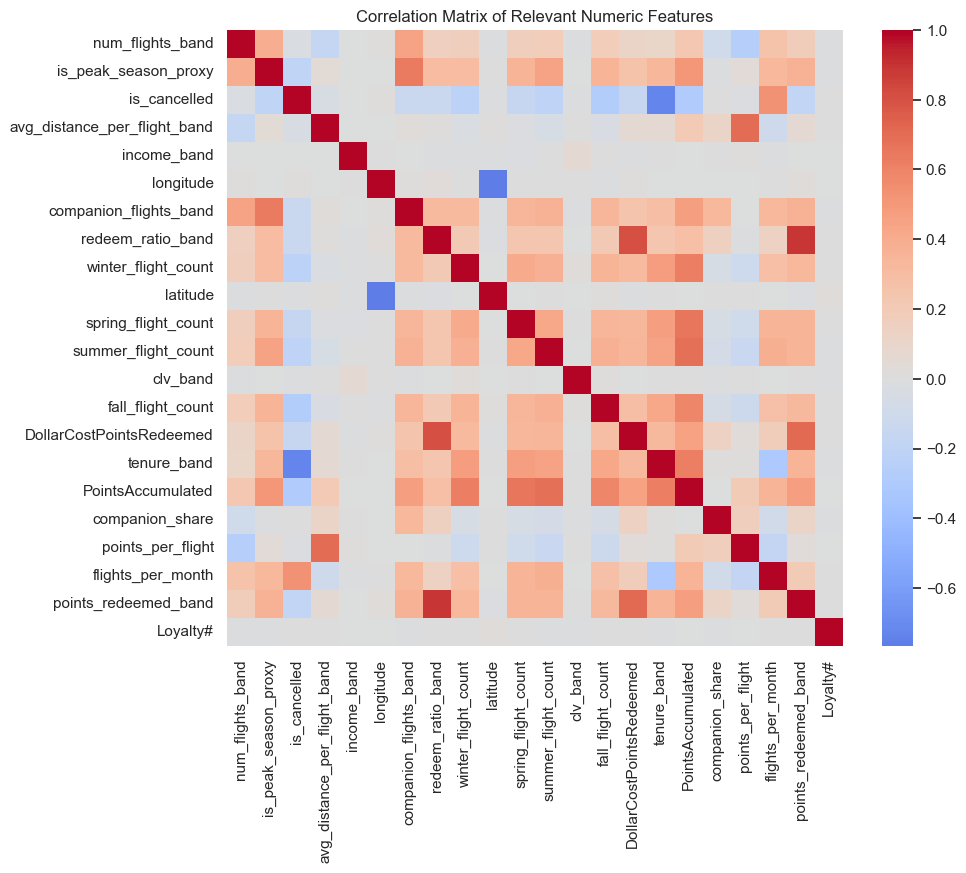

In [546]:
plt.figure(figsize=(10,8))
sns.heatmap(
    X_var.corr(),
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation Matrix of Relevant Numeric Features")
plt.show()

Strong correlations between a variety of flight-related features are shown in the correlation matrix, suggesting redundancy in the feature space. Companion share, tenure, and redemption behavior, on the other hand, show lower connections and represent different facets of consumer behavior. As a result, only one feature from each strongly correlated pair was kept, and feature pairings with an absolute correlation coefficient higher than 0.9 were considered redundant.


In [547]:
# corr_matrix = X_var.corr().abs()

# upper_triangle = corr_matrix.where(
#     np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
# )

# to_drop = [
#     column for column in upper_triangle.columns
#     if any(upper_triangle[column] > 0.9)
# ]

# X_uncorrelated = X_var.drop(columns=to_drop)

# print("Dropped correlated features:")
# print(to_drop)
# print("Shape after correlation filtering:", X_uncorrelated.shape)

### Dimensionality Reduction – Principal Component Analysis (PCA)

After removing irrelevant and redundant features, dimensionality reduction is applied using
Principal Component Analysis (PCA).
PCA transforms the original feature space into a smaller set of orthogonal components that:
Preserve maximum variance
Remove multicollinearity
Improve clustering efficiency

In [548]:
# pca = PCA()
# X_pca = pca.fit_transform(X_uncorrelated)

# explained_variance = pca.explained_variance_ratio_

# plt.figure(figsize=(8,5))
# plt.plot(
#     range(1, len(explained_variance)+1),
#     np.cumsum(explained_variance),
#     marker='o'
# )
# plt.xlabel("Number of Principal Components")
# plt.ylabel("Cumulative Explained Variance")
# plt.title("PCA – Cumulative Explained Variance")
# plt.grid()
# plt.show()

According to the cumulative explained variance plot, the first main components account for the majority of the variance, and the gains decrease as more components are added. This pattern facilitates the use of PCA to provide a compact representation for clustering and validates redundancy in the original feature space.

The PCA-transformed dataset preserves over 90% of the original variance while significantly reducing dimensionality.
This reduced feature space is used as input for the clustering algorithms.

In [549]:
# pca = PCA(n_components=0.9)
# X_pca_final = pca.fit_transform(X_uncorrelated)

# print("Number of principal components retained:", pca.n_components_)
# print("Final PCA dataset shape:", X_pca_final.shape)

In [550]:
fe_df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Loyalty#                        14459 non-null  int32  
 1   customer_name                   14459 non-null  object 
 2   province                        14459 non-null  object 
 3   city                            14459 non-null  object 
 4   latitude                        14459 non-null  float64
 5   longitude                       14459 non-null  float64
 6   postal_code                     14459 non-null  object 
 7   enrollment_date                 14459 non-null  object 
 8   enrollment_type                 14459 non-null  object 
 9   is_cancelled                    14459 non-null  int64  
 10  PointsAccumulated               14459 non-null  float64
 11  DollarCostPointsRedeemed        14459 non-null  float64
 12  last_active_month               

In [551]:
fe_df_scaled.head()

,Loyalty#,customer_name,province,city,latitude,longitude,postal_code,enrollment_date,enrollment_type,is_cancelled,PointsAccumulated,DollarCostPointsRedeemed,last_active_month,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,flights_per_month,points_per_flight,companion_share,geo_point,clv_band,points_redeemed_band,num_flights_band,companion_flights_band,avg_distance_per_flight_band,redeem_ratio_band,tenure_band,income_band,gender_female,gender_male,education_Bachelor,education_College,education_Doctor,education_High School or Below,education_Master,location_code_Rural,location_code_Suburban,location_code_Urban,marital_status_Divorced,marital_status_Married,marital_status_Single,loyalty_status_Aurora,loyalty_status_Nova,loyalty_status_Star,season_fall,season_spring,season_summer,season_winter
0,100018,Mina Smida,Alberta,Edmonton,1.476093,-0.747297,T9G 1W3,2019-08-09,Standard,0,1.046348,1.079297,2021-12,1,0.354839,0.285714,0.093023,1.655172,0.968515,0.450764,-0.253535,"(53.544388, -113.49093)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,True,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False
1,100102,Rigoberto Palacio,Ontario,Toronto,-0.481949,0.000000,M1R 4K3,2016-03-09,Standard,0,-0.037713,0.944706,2021-12,1,0.838710,0.714286,-0.046512,1.413793,0.204945,-1.229014,-0.082369,"(43.653225, -79.383186)",-1.0,0.0,0.0,0.0,-1.0,0.5,0.0,-0.5,False,True,False,True,False,False,False,False,False,True,False,False,True,False,True,False,True,False,False,False
2,100140,Nakesha Klaass,British Columbia,Dawson Creek,1.914619,-0.895117,V5R 1W3,2019-07-30,Standard,0,0.489197,-0.240034,2021-12,1,0.483871,0.600000,-0.069767,0.896552,0.821712,-0.011358,0.004955,"(55.759628, -120.23766)",-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-0.5,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,False
3,100214,Loren Juenemann,British Columbia,Vancouver,0.632461,-0.958285,V5R 1W3,2018-08-06,Standard,0,0.106929,0.439777,2021-12,1,0.290323,-0.971429,-0.767442,0.413793,-0.733266,1.586013,-0.555755,"(49.28273, -123.12074)",-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,True,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False
4,100272,Siobhan Lander,Ontario,Toronto,-0.481949,0.000000,P1L 8X8,2017-01-09,Standard,0,0.475621,0.265752,2021-12,1,-0.096774,0.771429,0.441860,-0.482759,-0.170192,0.453556,0.280812,"(43.653225, -79.383186)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False


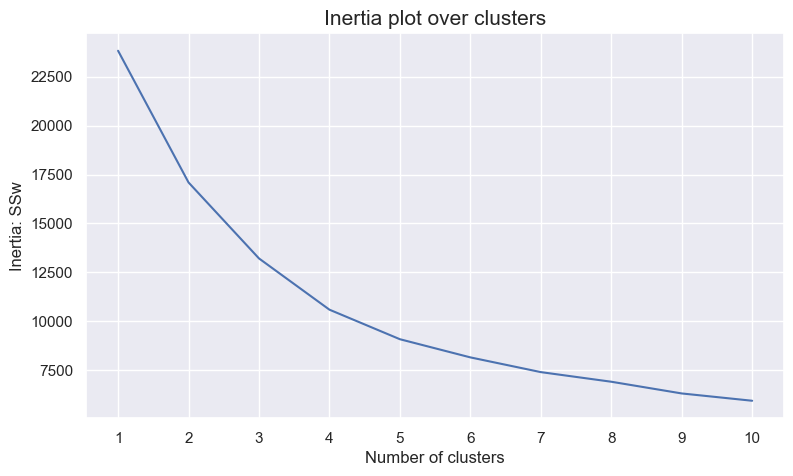

For n_clusters = 2, the average silhouette_score is : 0.3596995618857381
For n_clusters = 3, the average silhouette_score is : 0.3086863496188314
For n_clusters = 4, the average silhouette_score is : 0.3288574582706004
For n_clusters = 5, the average silhouette_score is : 0.33533931026816743
For n_clusters = 6, the average silhouette_score is : 0.33461839423961776
For n_clusters = 7, the average silhouette_score is : 0.31585774600972333
For n_clusters = 8, the average silhouette_score is : 0.32856350078774765
For n_clusters = 9, the average silhouette_score is : 0.3366944346791959
For n_clusters = 10, the average silhouette_score is : 0.32829687832679916


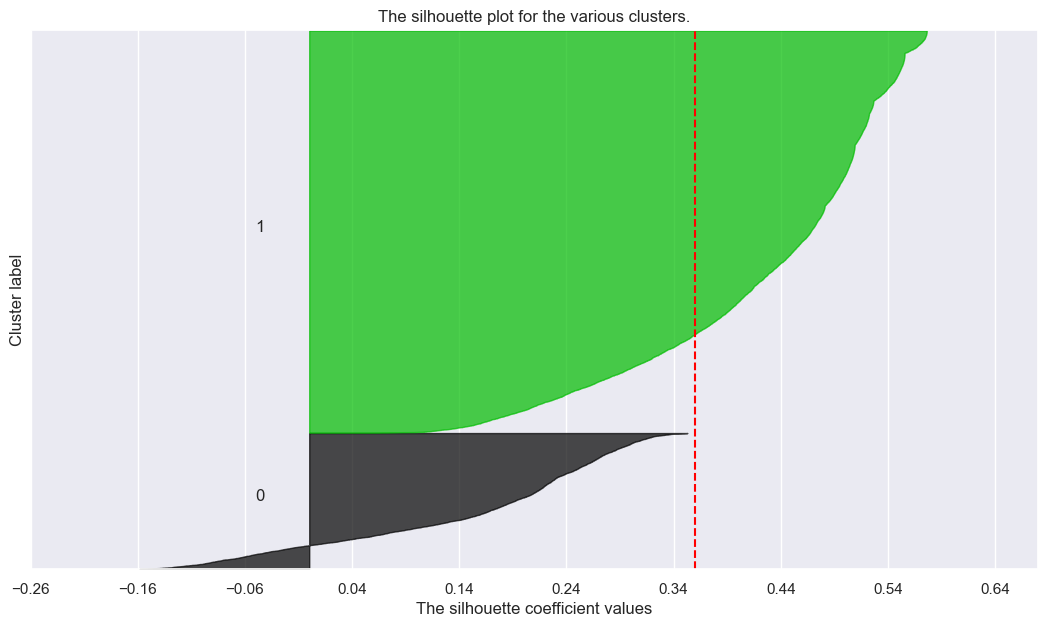

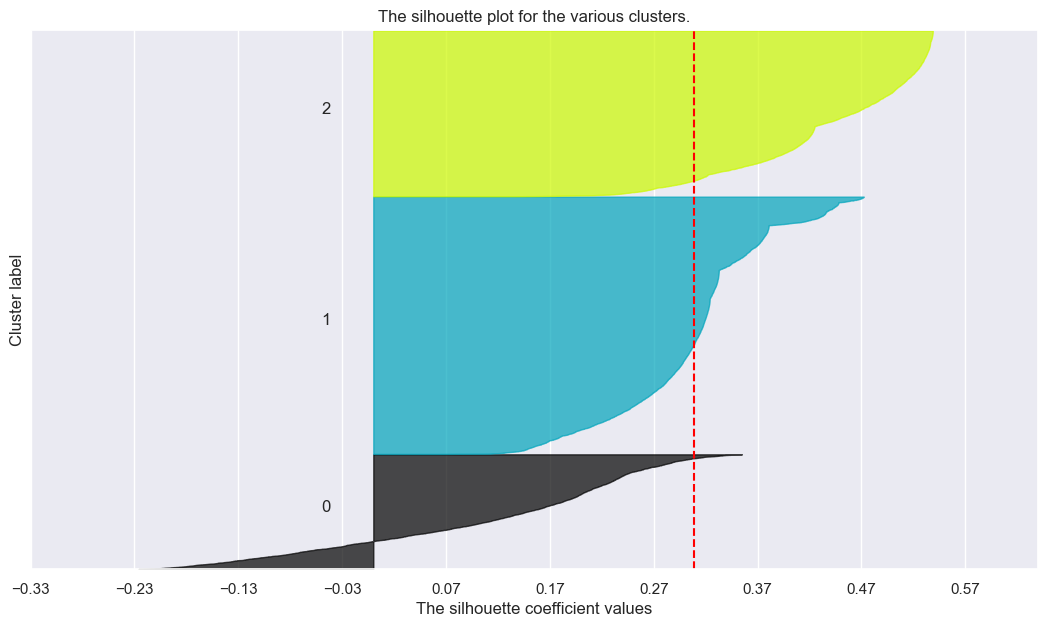

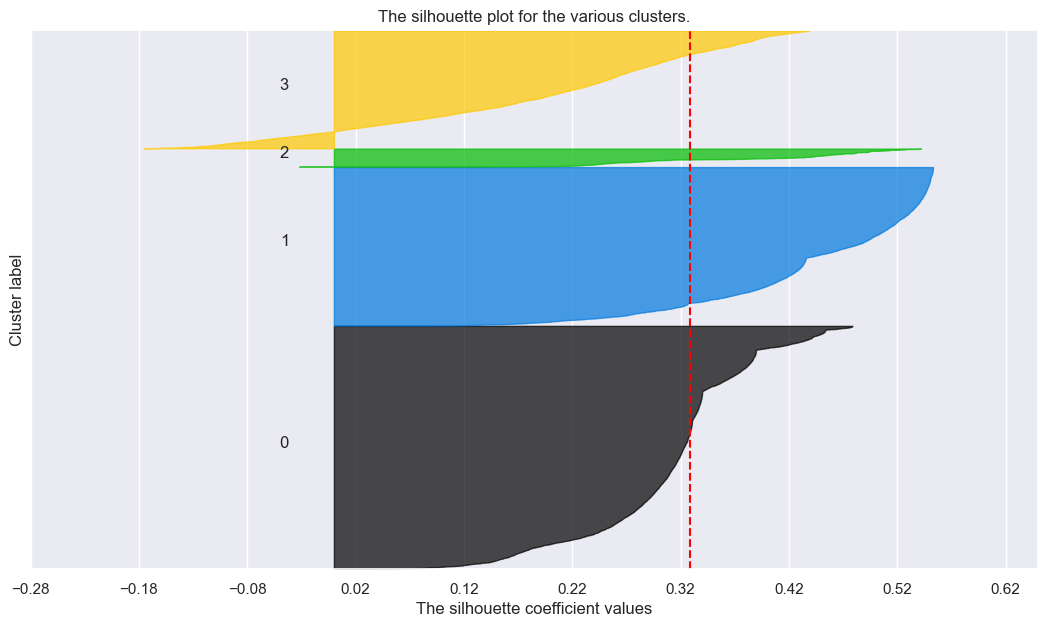

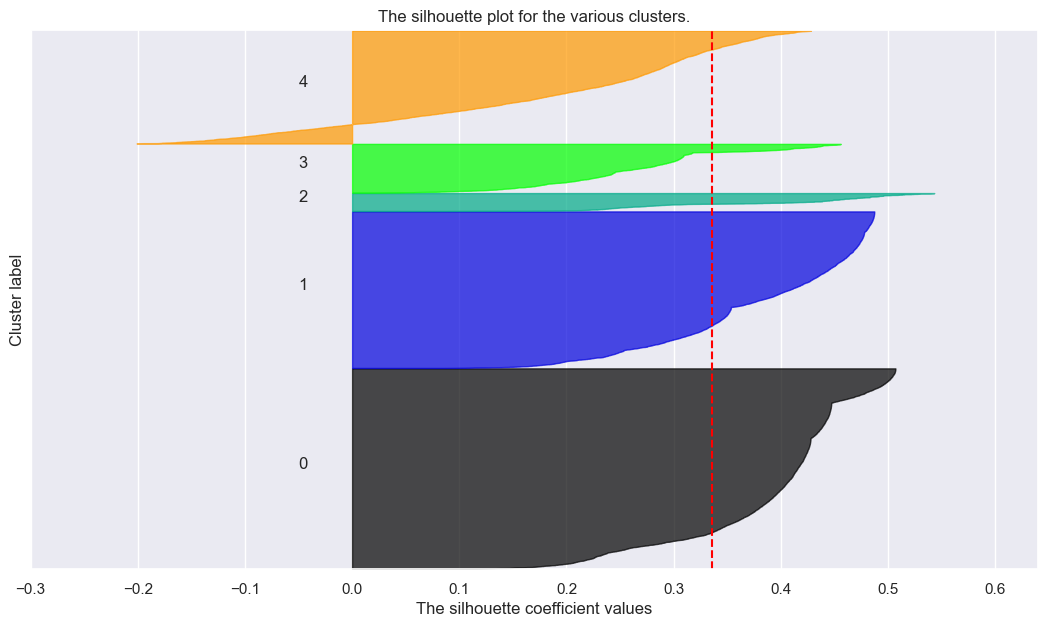

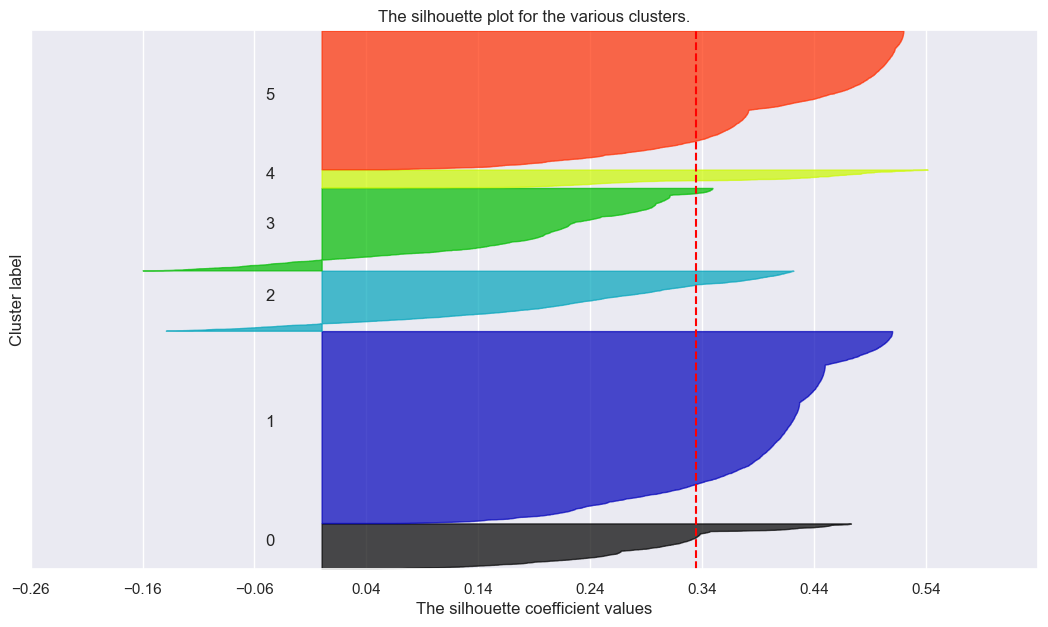

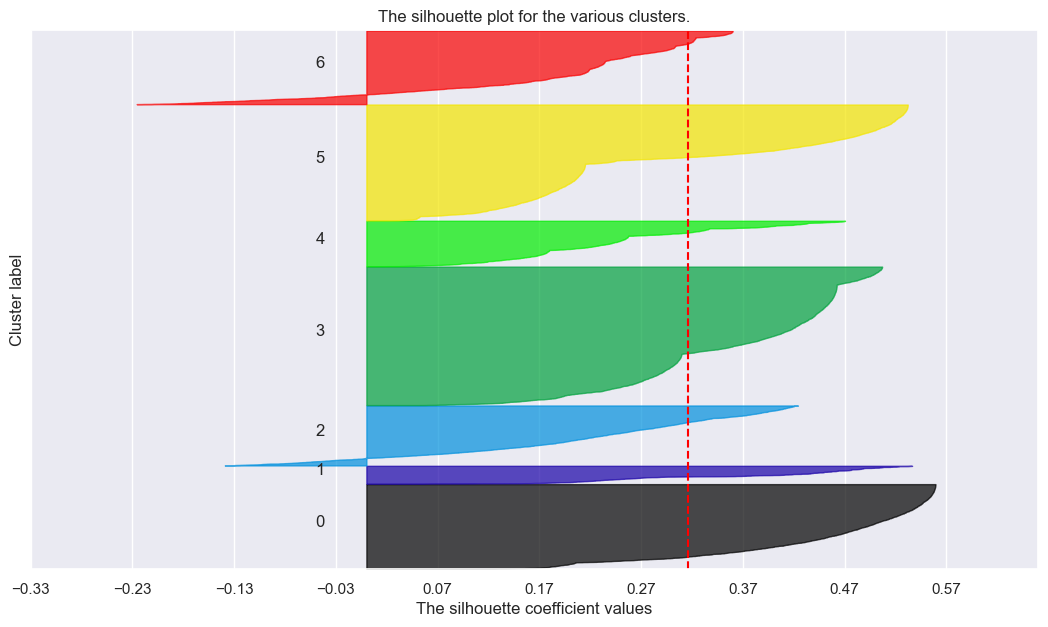

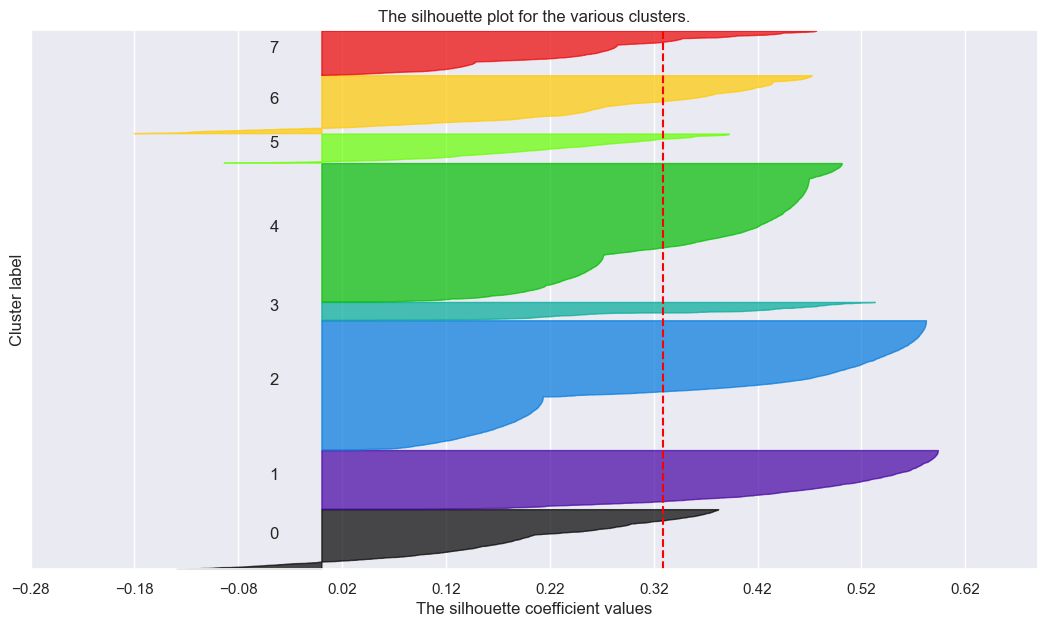

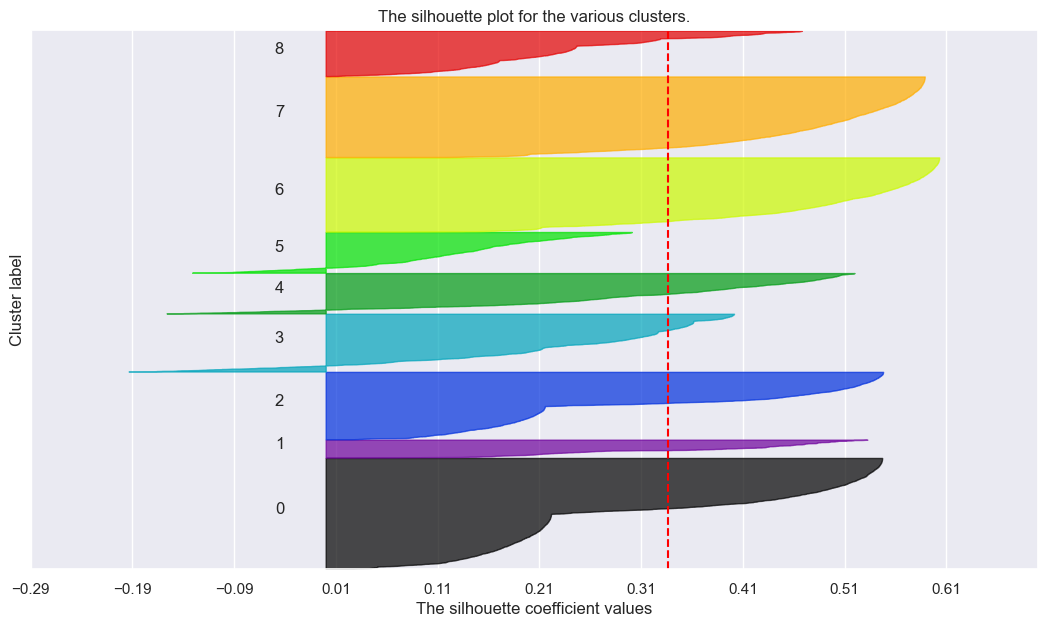

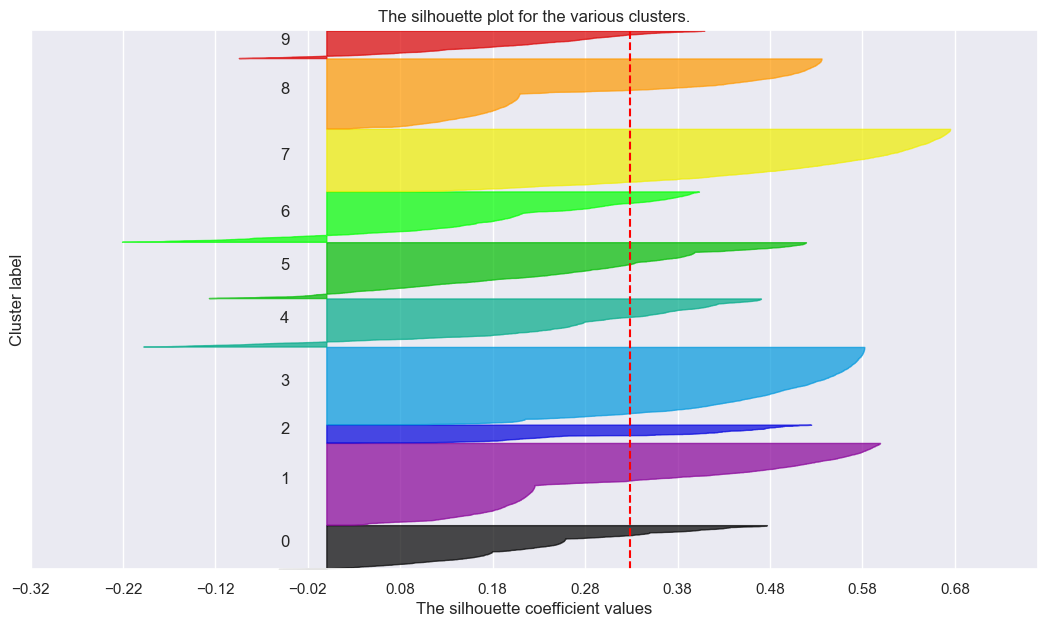

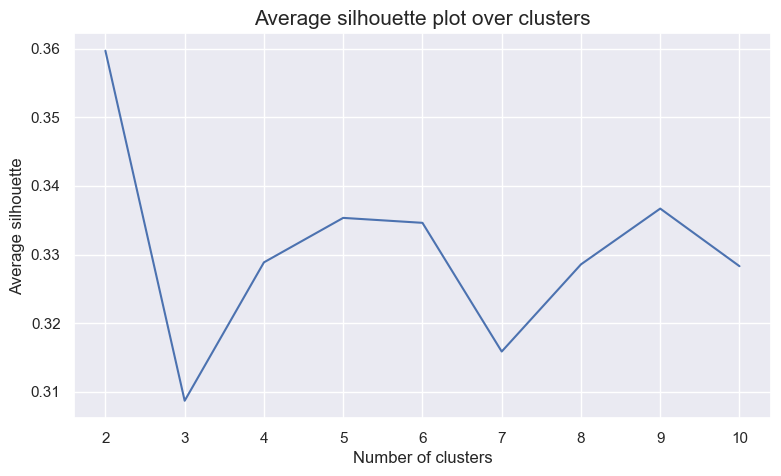

In [552]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

df = fe_df_scaled

metric_features = [
    "clv_band",
    "income_band",
    "PointsAccumulated",
    'avg_distance_per_flight_band',
    'companion_flights_band',
    'num_flights_band'
]

range_clusters = range(1, 11)

inertia = []
for n_clus in range_clusters:
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust.fit(df[metric_features])
    inertia.append(kmclust.inertia_)

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

avg_silhouette = []
for nclus in range_clusters:
    if nclus == 1:
        continue
    fig = plt.figure(figsize=(13, 7))

    kmclust = KMeans(n_clusters=nclus, init='k-means++', n_init=15, random_state=1)
    cluster_labels = kmclust.fit_predict(df[metric_features])

    silhouette_avg = silhouette_score(df[metric_features], cluster_labels)
    avg_silhouette.append(silhouette_avg)
    print(f"For n_clusters = {nclus}, the average silhouette_score is : {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(df[metric_features], cluster_labels)

    y_lower = 10
    for i in range(nclus):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / nclus)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10  # 10 for the 0 samples

    plt.title("The silhouette plot for the various clusters.")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")

    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    
    xmin, xmax = np.round(sample_silhouette_values.min() -0.1, 2), np.round(sample_silhouette_values.max() + 0.1, 2)
    plt.xlim([xmin, xmax])
    
    plt.ylim([0, len(df[metric_features]) + (nclus + 1) * 10])

    plt.yticks([])  # Clear the yaxis labels / ticks
    plt.xticks(np.arange(xmin, xmax, 0.1))

plt.figure(figsize=(9,5))


plt.plot(range_clusters[1:],
         avg_silhouette)

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters", size=15)
plt.show()

In [553]:
kmclust4 = KMeans(n_clusters=4, init='k-means++', n_init=15, random_state=1)
kmclust4.fit(df[metric_features])
kmclabels4 = kmclust4.predict(df[metric_features])

df_concat4 = pd.concat((df[metric_features], pd.Series(kmclabels4, name='labels', index=df.index)), axis=1)
df_concat4.groupby('labels').mean()

,clv_band,income_band,PointsAccumulated,avg_distance_per_flight_band,companion_flights_band,num_flights_band
labels,,,,,,
0,0.220422,-0.064965,0.233579,-0.052125,-0.001376,0.000000
1,-1.000000,-0.137046,0.182794,-0.059320,-0.002345,0.000000
2,-0.226337,-0.083333,-1.715997,-0.098765,-2.602881,-0.364198
3,-0.262476,-0.093967,-1.192673,-0.228364,-0.146557,-0.015477


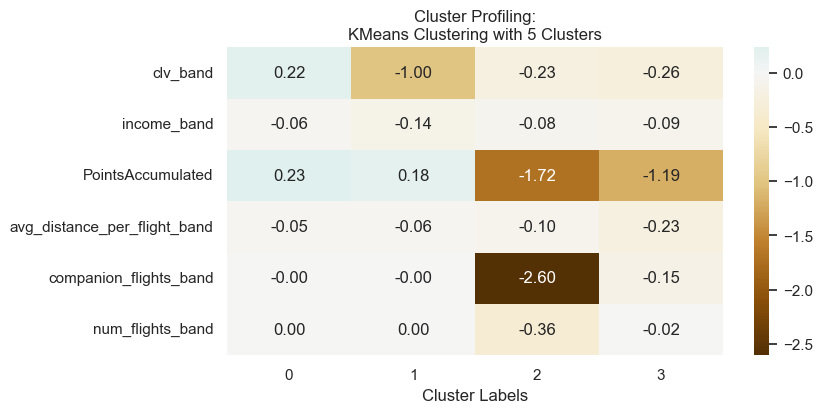

In [554]:
fig, ax = plt.subplots(figsize=(8,4))

km_profile = df_concat4.groupby('labels').mean().T

sns.heatmap(km_profile,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 5 Clusters")
plt.show()

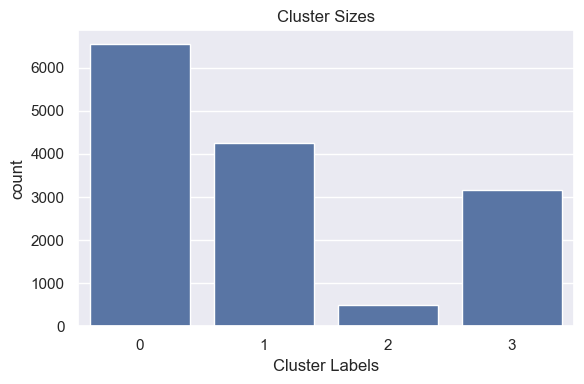

In [555]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df_concat4, x='labels')
ax.set_title("Cluster Sizes")
ax.set_xlabel("Cluster Labels")
fig.tight_layout()
plt.show()

In [556]:


# # ===================================================
# # 1. Feature definitions
# # ===================================================
# value_features = [
#     "clv_band",
#     "redeem_ratio_band",
#     "tenure_band",
#     "income_band",
#     "points_per_flight",
#     "PointsAccumulated",
#     "num_flights_band"
# ]

# categorical_features = [
#     "clv_band",
#     "redeem_ratio_band",
#     "tenure_band",
#     "income_band",
# ]

# numeric_features = [
#     "points_per_flight",
# ]

# # ===================================================
# # 2. Prepare data (NO SCALING)
# # ===================================================
# value_df_scaled = fe_df_scaled[["Loyalty#"] + value_features].copy()
# X_value = value_df_scaled[value_features].values

# # ===================================================
# # 3. Dynamic K evaluation
# # ===================================================
# results = []

# for k in range(2, 8):
#     kmeans = KMeans(
#         n_clusters=k,
#         init="k-means++",
#         n_init=20,
#         random_state=42
#     )
#     labels = kmeans.fit_predict(X_value)

#     sil = silhouette_score(X_value, labels)
#     min_cluster_share = pd.Series(labels).value_counts(normalize=True).min()

#     results.append({
#         "k": k,
#         "silhouette": sil,
#         "min_cluster_share": min_cluster_share
#     })

# k_eval_df = pd.DataFrame(results)

# print("\nK evaluation:")
# print(k_eval_df)

# # ===================================================
# # 4. Robust FINAL_K selection (NO CRASH)
# # ===================================================
# MAX_SIL = k_eval_df["silhouette"].max()
# MIN_CLUSTER_SHARE = 0.05

# eligible = k_eval_df[
#     (k_eval_df["silhouette"] >= 0.95 * MAX_SIL) &
#     (k_eval_df["min_cluster_share"] >= MIN_CLUSTER_SHARE)
# ]

# if eligible.empty:
#     FINAL_K = int(
#         k_eval_df.loc[k_eval_df["silhouette"].idxmax(), "k"]
#     )
# else:
#     FINAL_K = int(
#         eligible.sort_values("k").iloc[0]["k"]
#     )

# print(f"\nSelected FINAL_K = {FINAL_K}")

# # ===================================================
# # 5. Plot evaluation curves
# # ===================================================
# plt.figure()
# plt.plot(k_eval_df["k"], k_eval_df["silhouette"], marker="o")
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Silhouette Score")
# plt.title("Silhouette Score vs Number of Clusters")
# plt.show()

# plt.figure()
# plt.plot(k_eval_df["k"], k_eval_df["min_cluster_share"], marker="o")
# plt.axhline(MIN_CLUSTER_SHARE, linestyle="--")
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Smallest Cluster Share")
# plt.title("Cluster Stability vs Number of Clusters")
# plt.show()

# # ===================================================
# # 6. Fit final KMeans
# # ===================================================
# final_kmeans = KMeans(
#     n_clusters=FINAL_K,
#     init="k-means++",
#     n_init=20,
#     random_state=42
# )

# value_df_scaled["value_cluster"] = final_kmeans.fit_predict(X_value)

# # ===================================================
# # 7. Attach clusters to ORIGINAL data
# # ===================================================
# value_df = fe_df[["Loyalty#"] + value_features].copy()
# value_df["value_cluster"] = value_df_scaled["value_cluster"].values

# # ===================================================
# # 8. Cluster sizes
# # ===================================================
# print("\nCluster sizes:")
# print(value_df["value_cluster"].value_counts().sort_index())

# # ===================================================
# # 9. Numeric interpretation (median)
# # ===================================================
# numeric_summary = (
#     value_df
#     .groupby("value_cluster")[numeric_features]
#     .median()
# )

# print("\nNumeric feature medians:")
# print(numeric_summary)

# # ===================================================
# # 10. Categorical interpretation
# # ===================================================
# for col in categorical_features:
#     print(f"\nDistribution of {col} by cluster:")
#     print(
#         pd.crosstab(
#             value_df["value_cluster"],
#             value_df[col],
#             normalize="index"
#         ).round(2)
#     )

# # ===================================================
# # 11. Human-readable labels
# # ===================================================
# cluster_name_map = {
#     0: "Low-to-Mid Value Majority",
#     1: "High-Value Elite Customers"
# }

# value_df["value_segment"] = value_df["value_cluster"].map(cluster_name_map)

# print("\nSample labeled rows:")
# print(value_df.head())


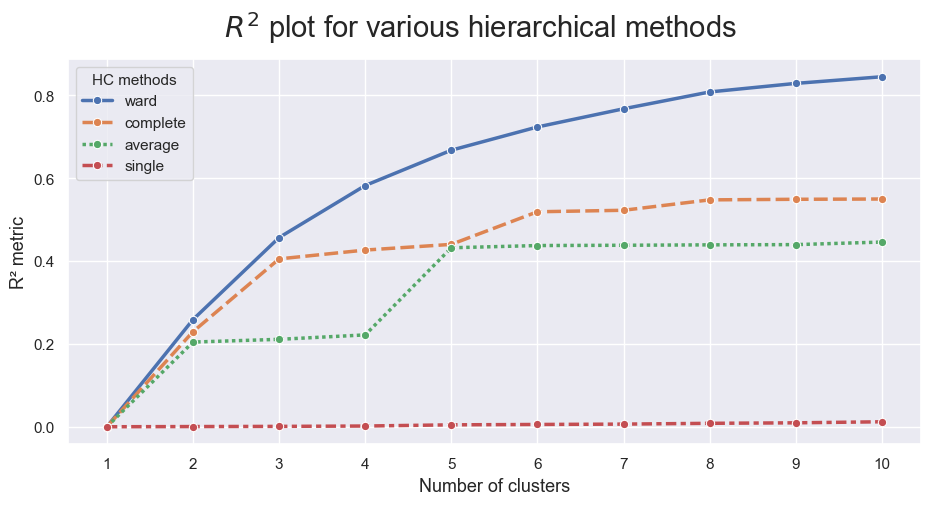

In [557]:


# ============================================================
# Feature Definitions
# ============================================================

value_features = [
    "clv_band",
    "income_band",    
    'avg_distance_per_flight_band',
    'companion_flights_band',
]

feats = value_features

# ============================================================
# Sum of Squares utilities (SST, SSB, SSW) and R²
# ============================================================

def get_ss(df, feats):
    df_ = df[feats]
    return np.sum(df_.var() * (df_.count() - 1))


def get_ssb(df, feats, label_col):
    ssb_i = 0
    X_ = df[feats].values
    X_mean = X_.mean(axis=0)

    for i in np.unique(df[label_col]):
        X_k = df.loc[df[label_col] == i, feats].values
        ssb_i += X_k.shape[0] * np.square(X_k.mean(axis=0) - X_mean)

    return np.sum(ssb_i)


def get_ssw(df, feats, label_col):
    feats_label = feats + [label_col]
    df_k = (
        df[feats_label]
        .groupby(label_col)
        .apply(lambda x: get_ss(x, feats), include_groups=False)
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    sst = get_ss(df, feats)
    ssw = get_ssw(df, feats, label_col)
    ssb = sst - ssw
    return ssb / sst


# ============================================================
# R² across different numbers of clusters (Hierarchical)
# ============================================================

def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    r2 = []
    feats = df.columns.tolist()

    for k in range(min_nclus, max_nclus + 1):
        hc = AgglomerativeClustering(
            n_clusters=k,
            metric=dist,
            linkage=link_method
        )

        labels = hc.fit_predict(df)

        df_labeled = df.copy()
        df_labeled["labels"] = labels

        r2.append(get_rsq(df_labeled, feats, "labels"))

    return np.array(r2)


# ============================================================
# Run HC R² for all linkage methods using value_features
# ============================================================

hc_methods = ["ward", "complete", "average", "single"]
max_nclus = 10

X = df[value_features]

r2_hc = np.vstack([
    get_r2_hc(
        X,
        link_method=link,
        max_nclus=max_nclus,
        min_nclus=1,
        dist="euclidean"
    )
    for link in hc_methods
])

r2_hc_methods = pd.DataFrame(
    r2_hc.T,
    index=range(1, max_nclus + 1),
    columns=hc_methods
)


# ============================================================
# Plot R² vs Number of Clusters
# ============================================================

sns.set()

fig = plt.figure(figsize=(11, 5))
sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"] * len(hc_methods))

plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R² metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods", fontsize=21)

plt.show()


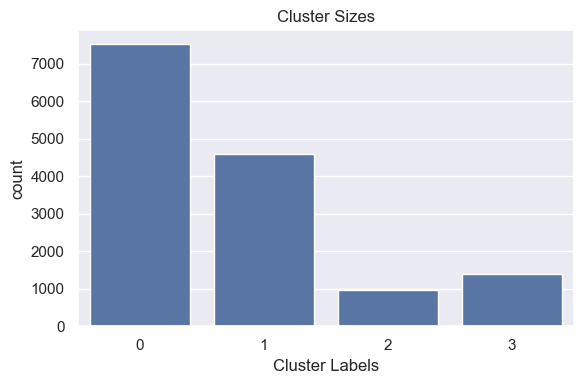

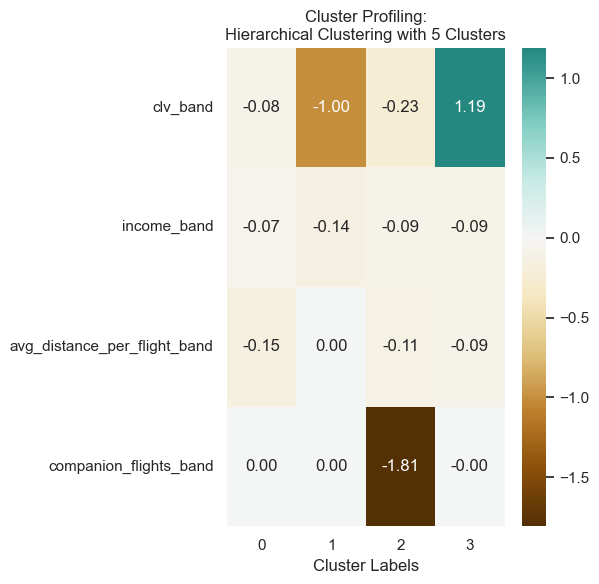

In [558]:
hclust4= AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=4)
hc_labels4 = hclust4.fit_predict(df[value_features])
hc_labels4


# add labels to dataset
labels_series = pd.Series(hc_labels4, name='labels', index=df.index)

df_concat4 = pd.concat([df[value_features], labels_series],axis=1)
df_concat4[value_features+['labels']].groupby('labels').mean()

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df_concat4, x='labels')
ax.set_title("Cluster Sizes")
ax.set_xlabel("Cluster Labels")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
hc_profile = df_concat4.groupby('labels').mean().T
sns.heatmap(hc_profile,center=0, annot=True, cmap="BrBG", fmt=".2f",ax=ax)
ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 5 Clusters")
fig.tight_layout()
plt.show()

In [559]:
# Create crosstab between km_labels and pc_km_labels

pd.crosstab(
    pd.Series(hc_labels4, name='HC6', index=df.index),
    pd.Series(kmclabels4, name='KM4', index=df.index)
    )

KM4,0,1,2,3
HC6,,,,
0,5327,302,0,1884
1,0,3953,0,646
2,8,10,486,463
3,1207,0,0,173


In [560]:
# -----------------------------
# Base dataframe (customer-level)
# -----------------------------
rfm_df = fe_df_scaled.copy()

# -----------------------------
# RECENCY
# Use last_active_month as a proxy
# -----------------------------
rfm_df["last_active_month"] = pd.to_datetime(rfm_df["last_active_month"])

analysis_date = rfm_df["last_active_month"].max() + pd.offsets.MonthEnd(1)

rfm_df["recency"] = (analysis_date - rfm_df["last_active_month"]).dt.days

# -----------------------------
# FREQUENCY
# -----------------------------
rfm_df["frequency"] = rfm_df["flights_per_month"]

# -----------------------------
# MONETARY
# -----------------------------
rfm_df["monetary"] = rfm_df["PointsAccumulated"]

# -----------------------------
# R, F, M Scoring (Quintiles)
# Use ranking to avoid duplicate bin edges
# -----------------------------
rfm_df["R_score"] = pd.qcut(
    rfm_df["recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm_df["F_score"] = pd.qcut(
    rfm_df["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm_df["M_score"] = pd.qcut(
    rfm_df["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# -----------------------------
# Combined RFM Score
# -----------------------------
rfm_df["RFM_score"] = (
    rfm_df["R_score"].astype(int) +
    rfm_df["F_score"].astype(int) +
    rfm_df["M_score"].astype(int)
)

rfm_df["RFM_code"] = (
    rfm_df["R_score"].astype(str) +
    rfm_df["F_score"].astype(str) +
    rfm_df["M_score"].astype(str)
)

# -----------------------------
# Business Segments
# -----------------------------
def rfm_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost"

rfm_df["segment"] = rfm_df["RFM_score"].apply(rfm_segment)


rfm = rfm_df[[
    "Loyalty#",
    "recency",
    "frequency",
    "monetary",
    "R_score",
    "F_score",
    "M_score",
    "RFM_score",
    "RFM_code",
    "segment"
]].copy()

rfm.head()

,Loyalty#,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_code,segment
0,100018,30,0.968515,1.046348,5,5,5,15,555,Champions
1,100102,30,0.204945,-0.037713,5,4,3,12,543,Loyal
2,100140,30,0.821712,0.489197,5,5,5,15,555,Champions
3,100214,30,-0.733266,0.106929,5,1,3,9,513,Potential Loyalists
4,100272,30,-0.170192,0.475621,5,3,4,12,534,Loyal


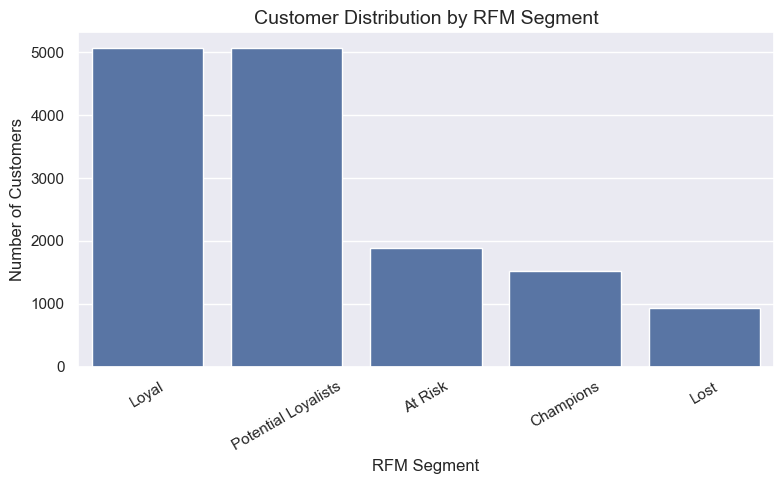

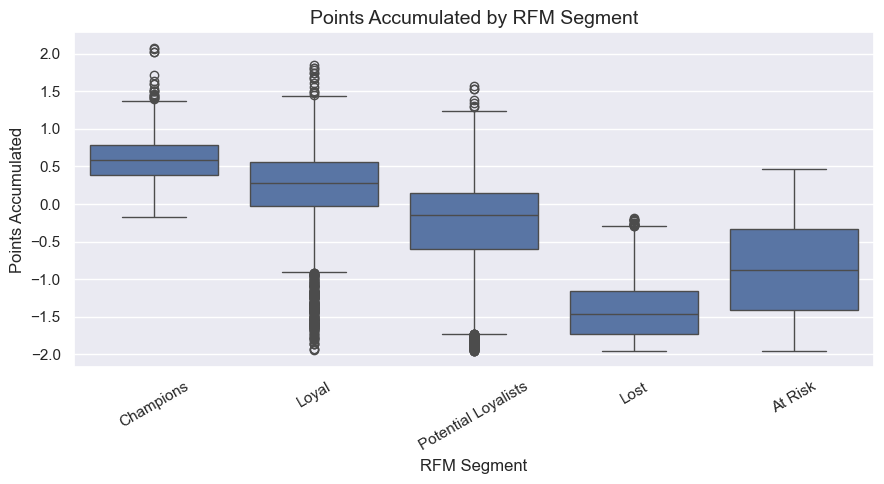

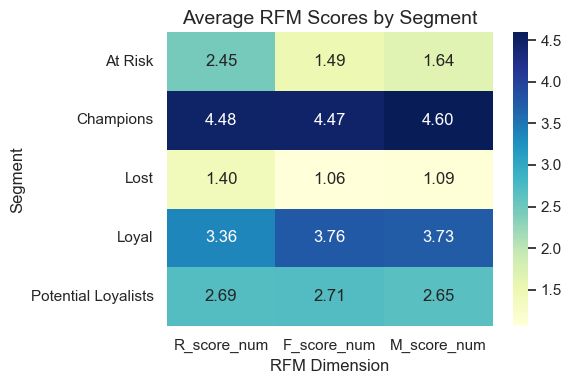

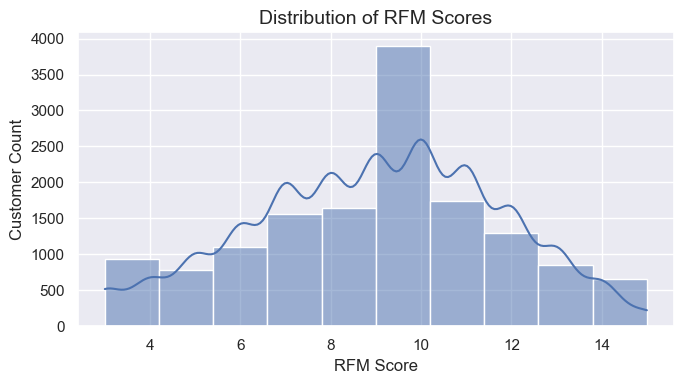

In [561]:
# ------------------------------------------------
# Customer Distribution by RFM Segment
# ------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(
    data=rfm,
    x="segment",
    order=rfm["segment"].value_counts().index
)
plt.title("Customer Distribution by RFM Segment", fontsize=14)
plt.xlabel("RFM Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# Monetary Distribution by RFM Segment
# ------------------------------------------------
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=rfm,
    x="segment",
    y="monetary"
)
plt.title("Points Accumulated by RFM Segment", fontsize=14)
plt.xlabel("RFM Segment")
plt.ylabel("Points Accumulated")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# Average RFM Scores by Segment (Heatmap)
# ------------------------------------------------
rfm_summary = (
    rfm.assign(
        R_score_num=rfm["R_score"].astype(int),
        F_score_num=rfm["F_score"].astype(int),
        M_score_num=rfm["M_score"].astype(int)
    )
    .groupby("segment")[["R_score_num", "F_score_num", "M_score_num"]]
    .mean()
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    rfm_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)
plt.title("Average RFM Scores by Segment", fontsize=14)
plt.xlabel("RFM Dimension")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# Distribution of Overall RFM Scores
# ------------------------------------------------
plt.figure(figsize=(7, 4))
sns.histplot(
    rfm["RFM_score"],
    bins=10,
    kde=True
)
plt.title("Distribution of RFM Scores", fontsize=14)
plt.xlabel("RFM Score")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

# HDBSCAN for GEO features:

In [562]:
ID_COL = "Loyalty#"
LAT_COL = "latitude"
LON_COL = "longitude"

geo = fe_df_log[[ID_COL, LAT_COL, LON_COL]].copy()

geo.head()

,Loyalty#,latitude,longitude
0,100018,53.544388,-113.490930
1,100102,43.653225,-79.383186
2,100140,55.759628,-120.237660
3,100214,49.282730,-123.120740
4,100272,43.653225,-79.383186


In [563]:
# Convert coordinates to radians to use haversine distance

X_rad = np.radians(geo[[LAT_COL, LON_COL]].to_numpy(dtype=float))
X_rad[:3]

array([[ 0.93452587, -1.9807904 ],
       [ 0.76189251, -1.38549797],
       [ 0.9731891 , -2.09854305]])

In [564]:
def fit_hdbscan_haversine(X_rad: np.ndarray, min_cluster_size: int, min_samples: int | None):
    model = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="haversine"
    )
    labels = model.fit_predict(X_rad)  
    return labels, model


def summarize_labels(labels: np.ndarray) -> dict:
    n = len(labels)
    noise = int((labels == -1).sum())
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    sizes = pd.Series(labels[labels != -1]).value_counts()
    return {
        "n_clusters": int(n_clusters),
        "noise_pct": float(noise / n * 100),
        "min_cluster_actual": int(sizes.min()) if len(sizes) else 0,
        "median_cluster_size": float(sizes.median()) if len(sizes) else 0,
        "max_cluster_size": int(sizes.max()) if len(sizes) else 0,
    }


In [565]:
min_cluster_sizes = [1000, 1200, 1400]
min_samples_list  = [30, 40, 50,  None]

rows = []
for mcs in min_cluster_sizes:
    for ms in min_samples_list:
        labels, _ = fit_hdbscan_haversine(X_rad, mcs, ms)
        rows.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            **summarize_labels(labels)
        })

results = pd.DataFrame(rows).sort_values(["noise_pct", "n_clusters", "min_cluster_actual"])
results

,min_cluster_size,min_samples,n_clusters,noise_pct,min_cluster_actual,median_cluster_size,max_cluster_size
0,1000,30.0,6,2.123245,1077,2329.0,3679
1,1000,40.0,6,2.123245,1077,2329.0,3679
2,1000,50.0,5,7.351822,1077,2932.0,4658
8,1400,30.0,3,9.896950,3679,4658.0,4691
9,1400,40.0,3,9.896950,3679,4658.0,4691
4,1200,30.0,4,9.896950,1238,3549.5,4691
5,1200,40.0,4,9.896950,1238,3549.5,4691
3,1000,NaN,4,11.660557,1077,3065.0,5566
6,1200,50.0,3,22.574175,2932,3605.0,4658
10,1400,50.0,3,22.574175,2932,3605.0,4658


We performed a grid search over the two key HDBSCAN hyperparameters (**min_cluster_size** and **min_samples**) to systematically explore the **granularity–coverage trade-off** for geographic territories. We tested **min_cluster_size = [1000, 1200, 1400]** to move from more fine-grained partitions (more clusters, smaller territories) to coarser, campaign-actionable territories (fewer clusters, larger regions). For density strictness, we evaluated **min_samples = [30, 40, 50, None]**, where larger values impose a stricter definition of “dense area” (typically increasing the proportion of points labelled as noise), while **None** uses HDBSCAN’s default behaviour.

In [566]:
def pick_config(results: pd.DataFrame,
                target_clusters_range=(8, 25),
                max_noise_pct=25.0,
                min_cluster_actual_at_least=100) -> dict:
    lo, hi = target_clusters_range
    cand = results[
        results["n_clusters"].between(lo, hi) &
        (results["noise_pct"] <= max_noise_pct) &
        (results["min_cluster_actual"] >= min_cluster_actual_at_least)
    ].copy()

    if len(cand) == 0:
        cand = results.copy()  

    cand = cand.sort_values(["noise_pct", "n_clusters", "min_cluster_actual"],
                            ascending=[True, True, False])
    return cand.iloc[0].to_dict()

best_cfg = pick_config(
    results,
    target_clusters_range=(6, 25),
    max_noise_pct=25.0,
    min_cluster_actual_at_least=100
)

best_cfg


{'min_cluster_size': 1000.0,
 'min_samples': 30.0,
 'n_clusters': 6.0,
 'noise_pct': 2.1232450376927865,
 'min_cluster_actual': 1077.0,
 'median_cluster_size': 2329.0,
 'max_cluster_size': 3679.0}

To avoid choosing HDBSCAN parameters by eye, we used a simple selection heuristic (pick_config) that filters and ranks the grid-search results according to campaign-oriented constraints. We restricted the search to solutions with 6–25 clusters, noise ≤ 25%, and minimum observed cluster size ≥ 100. Among candidates meeting these criteria, we ranked solutions by lowest noise, then fewer clusters (simpler execution), and finally largest minimum cluster (more robust territories).

In this grid, the tested settings produced 3–6 clusters. The selected solution was min_cluster_size=1000 and min_samples=30, yielding 6 territories with ~2.12% noise, and a minimum observed cluster size of 1077 (median 2329; max 3679), providing high coverage with large, stable territories.

In [567]:
final_labels, final_model = fit_hdbscan_haversine(
    X_rad,
    min_cluster_size=int(best_cfg["min_cluster_size"]),
    min_samples=(None if pd.isna(best_cfg["min_samples"]) else int(best_cfg["min_samples"]))
)

print("Resumo final:", summarize_labels(final_labels))

geo["geo_cluster"] = final_labels 
geo["geo_cluster"].value_counts().sort_index()


Resumo final: {'n_clusters': 6, 'noise_pct': 2.1232450376927865, 'min_cluster_actual': 1077, 'median_cluster_size': 2329.0, 'max_cluster_size': 3679}


geo_cluster
-1     307
 0    1238
 1    3420
 2    1124
 3    3679
 4    3614
 5    1077
Name: count, dtype: int64

The final HDBSCAN model (selected via `pick_config`) used **`min_cluster_size=1000`** and **`min_samples=30`**, producing **6 geographic territories** with **high coverage**. Only **~2.12%** of customers were labelled as noise (`-1`, **307 customers**). The resulting territories are **large and campaign-actionable**, with an observed **minimum cluster size of 1077** and a **median cluster size of 2329** (max **3679**), which strongly reduces the risk of unstable micro-territories. The final cluster size distribution shows a few very large dense hubs (e.g., clusters with **~3614–3679** customers) alongside smaller but still substantial territories (e.g., **~1077–1238** customers), reflecting realistic density differences across regions.

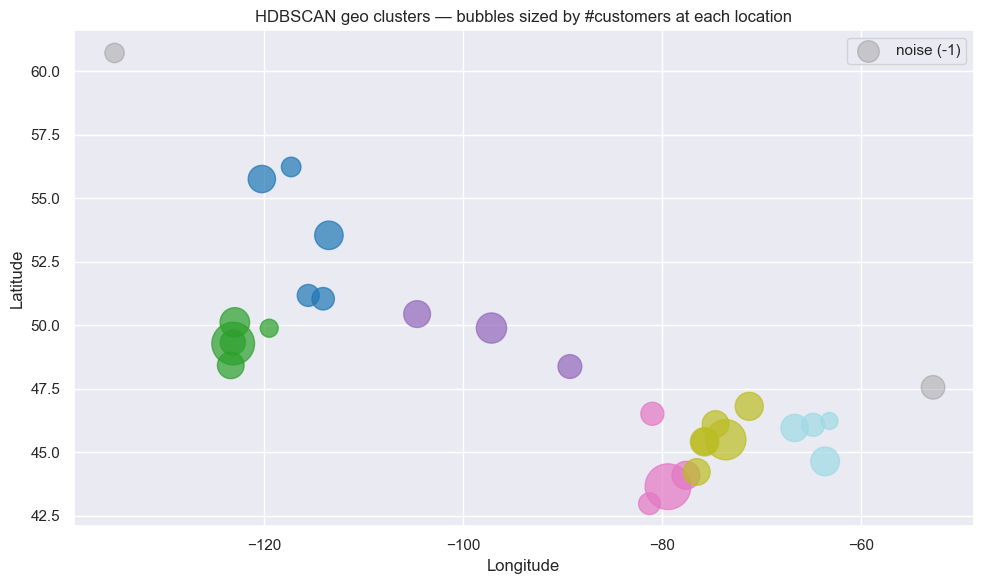

In [568]:
LAT_COL = "latitude"
LON_COL = "longitude"
CLUSTER_COL = "geo_cluster"  

loc = (
    geo.groupby([LAT_COL, LON_COL])
       .size()
       .reset_index(name="n_customers")
)

loc_cluster = (
    geo.groupby([LAT_COL, LON_COL])[CLUSTER_COL]
       .agg(lambda s: s.mode().iat[0] if len(s.mode()) else -1)
       .reset_index(name="cluster")
)

loc = loc.merge(loc_cluster, on=[LAT_COL, LON_COL], how="left")

sizes = np.sqrt(loc["n_customers"].to_numpy()) * 20  

plt.figure(figsize=(10, 6))

is_noise = loc["cluster"].to_numpy() == -1

plt.scatter(
    loc.loc[is_noise, LON_COL], loc.loc[is_noise, LAT_COL],
    s=sizes[is_noise], alpha=0.35, color="grey", label="noise (-1)"
)

plt.scatter(
    loc.loc[~is_noise, LON_COL], loc.loc[~is_noise, LAT_COL],
    s=sizes[~is_noise], alpha=0.7, c=loc.loc[~is_noise, "cluster"], cmap="tab20"
)

plt.title("HDBSCAN geo clusters — bubbles sized by #customers at each location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()


The bubble map visualizes the **HDBSCAN geographic territories** by plotting each unique location (latitude/longitude) and coloring it by its assigned **cluster**, while bubble size is proportional to the **number of customers at that location**. The figure shows that customers concentrate into a handful of **dense regional hubs** (large bubbles clustered together), with smaller bubbles forming the surrounding, less-populated pockets within the same territory. A few **grey points** correspond to **noise (`-1`)**, i.e., isolated locations that do not belong to any sufficiently dense region under the chosen HDBSCAN settings. Overall, the plot suggests that the final solution captures meaningful territorial structure: compact, high-density cores separated by wide geographic gaps, while leaving only a small set of outlier locations unassigned.

In [569]:
n_total = len(geo)
n_unique = geo[[LAT_COL, LON_COL]].drop_duplicates().shape[0]
print("Total rows:", n_total)
print("Unique (lat,lon):", n_unique)

geo.groupby([LAT_COL, LON_COL]).size().sort_values(ascending=False).head(10)


Total rows: 14459
Unique (lat,lon): 29


latitude   longitude  
43.653225  -79.383186     2932
49.282730  -123.120740    2230
45.501690  -73.567253     1768
49.895138  -97.138374      561
50.116322  -122.957360     511
44.648766  -63.575237      460
45.421532  -75.697189      444
53.544388  -113.490930     439
46.813877  -71.207977      417
44.101128  -77.576309      408
dtype: int64

In [570]:
EARTH_RADIUS_KM = 6371.0

def haversine_km(A_rad: np.ndarray, B_rad: np.ndarray) -> np.ndarray:
    lat1 = A_rad[:, 0][:, None]
    lon1 = A_rad[:, 1][:, None]
    lat2 = B_rad[:, 0][None, :]
    lon2 = B_rad[:, 1][None, :]

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

def fill_noise_with_nearest_centroid(geo: pd.DataFrame, X_rad: np.ndarray, label_col="geo_cluster") -> pd.Series:
    labels = geo[label_col].to_numpy()
    non_noise = labels != -1
    if non_noise.sum() == 0:
        return pd.Series(labels, index=geo.index)

    tmp = pd.DataFrame({
        "cluster": labels[non_noise],
        "lat": X_rad[non_noise, 0],
        "lon": X_rad[non_noise, 1],
    })
    cent = tmp.groupby("cluster")[["lat", "lon"]].median()
    cent_labels = cent.index.to_numpy()
    cent_rad = cent.to_numpy()

    noise_idx = np.where(labels == -1)[0]
    if len(noise_idx) == 0:
        return pd.Series(labels, index=geo.index)

    d = haversine_km(X_rad[noise_idx], cent_rad)
    nearest = cent_labels[np.argmin(d, axis=1)]

    filled = labels.copy()
    filled[noise_idx] = nearest
    return pd.Series(filled, index=geo.index)

geo["geo_cluster_filled"] = fill_noise_with_nearest_centroid(geo, X_rad, label_col="geo_cluster")

geo[["geo_cluster", "geo_cluster_filled"]].value_counts()


geo_cluster  geo_cluster_filled
 3           3                     3679
 4           4                     3614
 1           1                     3420
 0           0                     1238
 2           2                     1124
 5           5                     1077
-1           5                      210
             0                       97
Name: count, dtype: int64

Noise points were assigned to the **closest** geographic cluster to ensure every customer receives a usable territory label. The table shows the resulting distribution across the original HDBSCAN labels (`geo_cluster`) and the post-processed labels (`geo_cluster_filled`) after this reassignment step. The main territories remain unchanged, indicating the clustering’s core structure is stable. Importantly, the former noise customers were absorbed into existing territories: **210** customers previously labelled as **`-1`** were reassigned to cluster **5**, and the remaining **97** were reassigned to cluster **0**. As a result, `geo_cluster_filled` contains only valid cluster IDs (no `-1`).

C:\Users\marta\AppData\Local\Temp\ipykernel_33548\2993262880.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


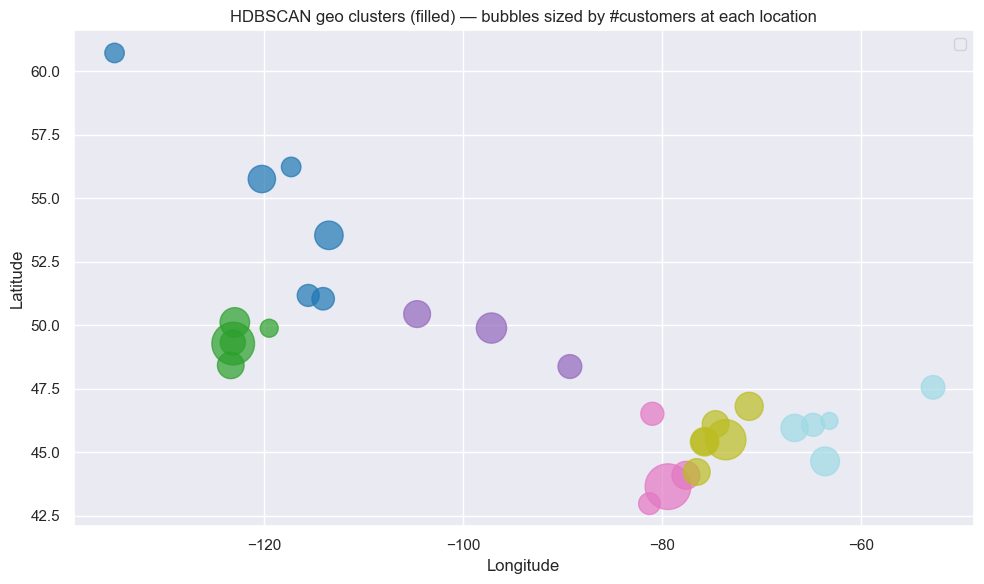

In [571]:
LAT_COL = "latitude"
LON_COL = "longitude"
CLUSTER_COL = "geo_cluster_filled"  

loc = (
    geo.groupby([LAT_COL, LON_COL])
       .size()
       .reset_index(name="n_customers")
)

def mode_ignore_nan(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.mode().iat[0]

loc_cluster = (
    geo.groupby([LAT_COL, LON_COL])[CLUSTER_COL]
       .agg(mode_ignore_nan)
       .reset_index(name="cluster")
)

loc = loc.merge(loc_cluster, on=[LAT_COL, LON_COL], how="left")

sizes = np.sqrt(loc["n_customers"].to_numpy()) * 20

plt.figure(figsize=(10, 6))

is_nan = loc["cluster"].isna().to_numpy()
is_noise = (loc["cluster"].to_numpy() == -1)  
is_valid = ~(is_nan | is_noise)

if is_nan.any():
    plt.scatter(
        loc.loc[is_nan, LON_COL], loc.loc[is_nan, LAT_COL],
        s=sizes[is_nan], alpha=0.25, color="black", label="missing cluster (NaN)"
    )

if is_noise.any():
    plt.scatter(
        loc.loc[is_noise, LON_COL], loc.loc[is_noise, LAT_COL],
        s=sizes[is_noise], alpha=0.35, color="grey", label="noise (-1)"
    )

plt.scatter(
    loc.loc[is_valid, LON_COL], loc.loc[is_valid, LAT_COL],
    s=sizes[is_valid], alpha=0.7, c=loc.loc[is_valid, "cluster"], cmap="tab20"
)

plt.title("HDBSCAN geo clusters (filled) — bubbles sized by #customers at each location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()


This bubble map shows the **post-processed HDBSCAN territories after filling noise**, where every previously unassigned location (`-1`) was reassigned to its **nearest** cluster. As a result, the plot contains **only valid territory colors** (no grey “noise” points), making the segmentation directly usable for campaign activation. The overall geographic structure remains essentially the same—large bubbles still mark the main population hubs and smaller bubbles represent lower-density pockets—but the former outliers are now absorbed into the closest territories, slightly expanding cluster boundaries at the margins while preserving the original high-density cores.

In [572]:
df_geo = fe_df_log.merge(
    geo[[ID_COL, "geo_cluster_filled"]],
    on=ID_COL,
    how="left"
)

df_geo.head()


,Loyalty#,customer_name,province,city,latitude,longitude,postal_code,enrollment_date,enrollment_type,is_cancelled,PointsAccumulated,DollarCostPointsRedeemed,last_active_month,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,flights_per_month,points_per_flight,companion_share,geo_point,clv_band,points_redeemed_band,num_flights_band,companion_flights_band,avg_distance_per_flight_band,redeem_ratio_band,tenure_band,income_band,gender_female,gender_male,education_Bachelor,education_College,education_Doctor,education_High School or Below,education_Master,location_code_Rural,location_code_Suburban,location_code_Urban,marital_status_Divorced,marital_status_Married,marital_status_Single,loyalty_status_Aurora,loyalty_status_Nova,loyalty_status_Star,season_fall,season_spring,season_summer,season_winter,geo_cluster_filled
0,100018,Mina Smida,Alberta,Edmonton,53.544388,-113.490930,T9G 1W3,2019-08-09,Standard,0,53014.30,201.9,2021-12,1,45,47,55,84,1.383379,5.440247,0.216450,"(53.544388, -113.49093)",1.0,3.0,3.0,3.0,2.0,2.0,3.0,2.0,True,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,0
1,100102,Rigoberto Palacio,Ontario,Toronto,43.653225,-79.383186,M1R 4K3,2016-03-09,Standard,0,33903.96,186.2,2021-12,1,60,62,49,77,1.126807,4.925147,0.237903,"(43.653225, -79.383186)",0.0,3.0,3.0,3.0,1.0,3.0,3.0,0.0,False,True,False,True,False,False,False,False,False,True,False,False,True,False,True,False,True,False,False,False,3
2,100140,Nakesha Klaass,British Columbia,Dawson Creek,55.759628,-120.237660,V5R 1W3,2019-07-30,Standard,0,43192.58,48.0,2021-12,1,49,58,48,62,1.334051,5.298538,0.248848,"(55.759628, -120.23766)",0.0,2.0,3.0,3.0,2.0,2.0,3.0,0.0,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,False,0
3,100214,Loren Juenemann,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,2018-08-06,Standard,0,36453.77,127.3,2021-12,1,43,3,18,48,0.811551,5.788369,0.178571,"(49.28273, -123.12074)",0.0,3.0,3.0,3.0,2.0,2.0,3.0,1.0,False,True,True,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,1
4,100272,Siobhan Lander,Ontario,Toronto,43.653225,-79.383186,P1L 8X8,2017-01-09,Standard,0,42953.25,107.0,2021-12,1,31,64,70,22,1.000754,5.441103,0.283422,"(43.653225, -79.383186)",1.0,3.0,3.0,3.0,2.0,2.0,3.0,2.0,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False,3


In [573]:
df_geo_scaled = fe_df_scaled.merge(
    geo[[ID_COL, "geo_cluster_filled"]],
    on=ID_COL,
    how="left"
)

df_geo_scaled.head()


,Loyalty#,customer_name,province,city,latitude,longitude,postal_code,enrollment_date,enrollment_type,is_cancelled,PointsAccumulated,DollarCostPointsRedeemed,last_active_month,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,flights_per_month,points_per_flight,companion_share,geo_point,clv_band,points_redeemed_band,num_flights_band,companion_flights_band,avg_distance_per_flight_band,redeem_ratio_band,tenure_band,income_band,gender_female,gender_male,education_Bachelor,education_College,education_Doctor,education_High School or Below,education_Master,location_code_Rural,location_code_Suburban,location_code_Urban,marital_status_Divorced,marital_status_Married,marital_status_Single,loyalty_status_Aurora,loyalty_status_Nova,loyalty_status_Star,season_fall,season_spring,season_summer,season_winter,geo_cluster_filled
0,100018,Mina Smida,Alberta,Edmonton,1.476093,-0.747297,T9G 1W3,2019-08-09,Standard,0,1.046348,1.079297,2021-12,1,0.354839,0.285714,0.093023,1.655172,0.968515,0.450764,-0.253535,"(53.544388, -113.49093)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,True,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,0
1,100102,Rigoberto Palacio,Ontario,Toronto,-0.481949,0.000000,M1R 4K3,2016-03-09,Standard,0,-0.037713,0.944706,2021-12,1,0.838710,0.714286,-0.046512,1.413793,0.204945,-1.229014,-0.082369,"(43.653225, -79.383186)",-1.0,0.0,0.0,0.0,-1.0,0.5,0.0,-0.5,False,True,False,True,False,False,False,False,False,True,False,False,True,False,True,False,True,False,False,False,3
2,100140,Nakesha Klaass,British Columbia,Dawson Creek,1.914619,-0.895117,V5R 1W3,2019-07-30,Standard,0,0.489197,-0.240034,2021-12,1,0.483871,0.600000,-0.069767,0.896552,0.821712,-0.011358,0.004955,"(55.759628, -120.23766)",-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-0.5,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,False,0
3,100214,Loren Juenemann,British Columbia,Vancouver,0.632461,-0.958285,V5R 1W3,2018-08-06,Standard,0,0.106929,0.439777,2021-12,1,0.290323,-0.971429,-0.767442,0.413793,-0.733266,1.586013,-0.555755,"(49.28273, -123.12074)",-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,True,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,1
4,100272,Siobhan Lander,Ontario,Toronto,-0.481949,0.000000,P1L 8X8,2017-01-09,Standard,0,0.475621,0.265752,2021-12,1,-0.096774,0.771429,0.441860,-0.482759,-0.170192,0.453556,0.280812,"(43.653225, -79.383186)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False,3


In [574]:
CLUSTER_COL = "geo_cluster_filled"  

def topk(s: pd.Series, k=3):
    return s.value_counts().head(k).index.tolist()

ZONE_COLS = ["location_code_Urban", "location_code_Suburban", "location_code_Rural"]
zone_cols = [c for c in ZONE_COLS if c in df_geo.columns]

geo_summary = (
    df_geo.groupby(CLUSTER_COL)
          .agg(
              n_customers=(ID_COL, "count"),
              centroid_lat=(LAT_COL, "median"),
              centroid_lon=(LON_COL, "median"),
              top_provinces=("province", lambda s: topk(s, k=2)),
              top_cities=("city", lambda s: topk(s, k=3)),
              pct_urban=(zone_cols[0], "mean") if "location_code_Urban" in zone_cols else (ID_COL, lambda s: np.nan),
              pct_suburban=(zone_cols[1], "mean") if "location_code_Suburban" in zone_cols else (ID_COL, lambda s: np.nan),
              pct_rural=(zone_cols[2], "mean") if "location_code_Rural" in zone_cols else (ID_COL, lambda s: np.nan),
          )
          .reset_index()
)

for c in ["pct_urban", "pct_suburban", "pct_rural"]:
    if c in geo_summary.columns:
        geo_summary[c] = (geo_summary[c] * 100).round(1)

def dominant_area(row):
    pairs = {
        "Urban": row.get("pct_urban", np.nan),
        "Suburban": row.get("pct_suburban", np.nan),
        "Rural": row.get("pct_rural", np.nan),
    }
    pairs = {k:v for k,v in pairs.items() if pd.notna(v)}
    return max(pairs, key=pairs.get) if pairs else np.nan

geo_summary["dominant_area"] = geo_summary.apply(dominant_area, axis=1)

geo_summary = geo_summary.sort_values("n_customers", ascending=False)

geo_summary


,geo_cluster_filled,n_customers,centroid_lat,centroid_lon,top_provinces,top_cities,pct_urban,pct_suburban,pct_rural,dominant_area
3,3,3679,43.653225,-79.383186,[Ontario],"[Toronto, Trenton, Sudbury]",33.1,34.7,32.2,Suburban
4,4,3614,45.501690,-73.567253,"[Quebec, Ontario]","[Montreal, Ottawa, Quebec City]",32.1,32.8,35.1,Rural
1,1,3420,49.282730,-123.120740,[British Columbia],"[Vancouver, Whistler, Victoria]",32.8,33.2,34.0,Rural
0,0,1335,53.544388,-115.570800,"[Alberta, British Columbia]","[Edmonton, Dawson Creek, Calgary]",31.5,35.8,32.7,Suburban
5,5,1287,45.963589,-63.575237,"[New Brunswick, Nova Scotia]","[Halifax, Fredericton, St. John's]",32.9,35.1,32.0,Suburban
2,2,1124,49.895138,-97.138374,"[Manitoba, Saskatchewan]","[Winnipeg, Regina, Thunder Bay]",33.2,34.0,32.8,Suburban


According to the **filled** geographic clustering (`geo_cluster_filled`), campaign territories are clearly anchored around major Canadian population hubs. The two largest territories are centred on **Toronto (Ontario)** (**3679 customers**, dominant **Suburban**) and the **Montréal / Ottawa / Quebec City** corridor (**3614 customers**, dominant **Rural**, spanning **Quebec + Ontario**). A third large West-coast territory captures **Vancouver / Whistler / Victoria** in **British Columbia** (**3420 customers**, dominant **Rural**). The remaining territories represent sizeable but more regionally distributed markets: an **Alberta/BC** segment around **Edmonton / Dawson Creek / Calgary** (**1335 customers**, dominant **Suburban**), an Atlantic cluster spanning **New Brunswick + Nova Scotia** around **Halifax / Fredericton / St. John’s** (**1287 customers**, dominant **Suburban**), and a Prairie territory spanning **Manitoba + Saskatchewan** around **Winnipeg / Regina / Thunder Bay** (**1124 customers**, dominant **Suburban**). Across territories, the Urban/Suburban/Rural split is fairly balanced (~31–35% each), but the **dominant area** differs by cluster—mostly **Suburban**, with the **Montréal/Quebec–Ontario** and **BC (Vancouver)** territories skewing slightly more **Rural**.


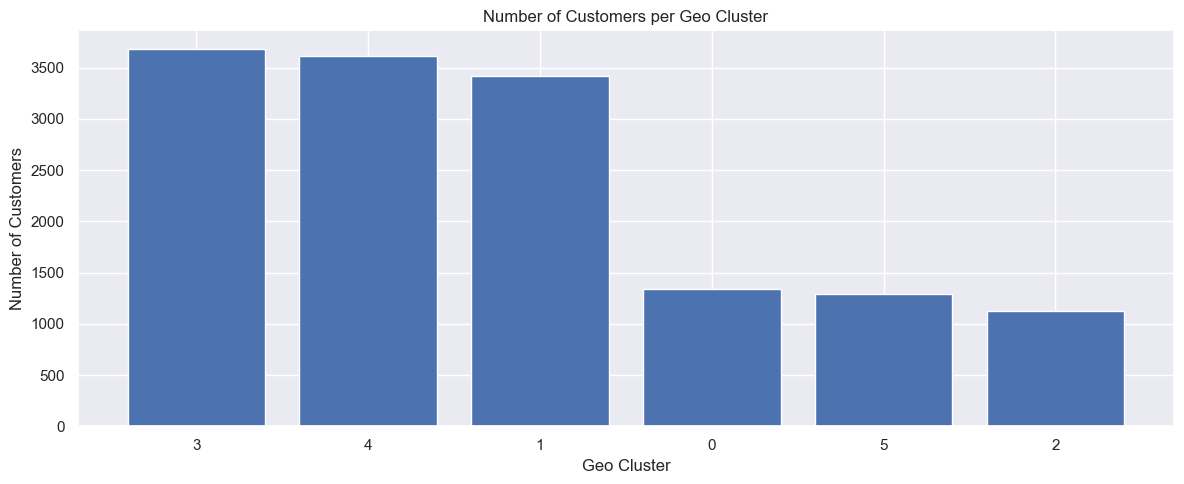

In [575]:
CLUSTER_COL = "geo_cluster_filled"  

counts = df_geo[CLUSTER_COL].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar([str(c) for c in counts.index], counts.values)
plt.title("Number of Customers per Geo Cluster")
plt.xlabel("Geo Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


This bar chart summarizes the **number of customers per filled geographic territory (`geo_cluster_filled`)**, highlighting a clearly **imbalanced size distribution**. Three territories dominate the customer base—clusters **3**, **4**, and **1** - each with roughly **3.4k–3.7k customers**, indicating that a large share of customers is concentrated in the main population hubs captured by these regions. In contrast, the remaining territories (**0**, **5**, **2**) are substantially smaller (approximately **1.1k–1.3k customers** each), representing secondary markets or more dispersed geographies. Overall, the pattern suggests a segmentation with a few high-density core territories alongside a set of smaller, still campaign-actionable regions, which is consistent with Canada’s population concentration in major metropolitan corridors.

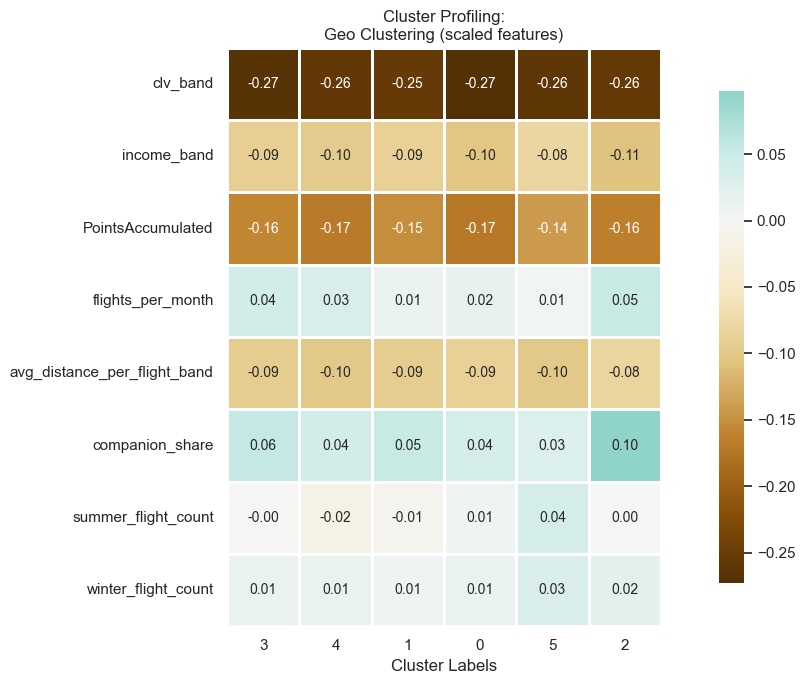

In [576]:
CLUSTER_COL = "geo_cluster_filled"

NUM_COLS = [
    "clv_band",
    "income_band",
    "PointsAccumulated",
    "flights_per_month",
    "avg_distance_per_flight_band",
    "companion_share",
    "summer_flight_count",
    "winter_flight_count",
]

num_cols = [c for c in NUM_COLS if c in df_geo_scaled.columns]
cluster_order = df_geo_scaled[CLUSTER_COL].value_counts().index

profile = (
    df_geo_scaled
    .groupby(CLUSTER_COL)[num_cols]
    .mean()
    .loc[cluster_order]
    .T
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    profile,
    center=0,
    annot=True,
    fmt=".2f",
    cmap="BrBG",
    linewidths=1.0,
    linecolor="white",
    square=True,                 
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.85},
    ax=ax
)

ax.set_xlabel("Cluster Labels")
ax.set_ylabel("")
ax.set_title("Cluster Profiling:\nGeo Clustering (scaled features)")
plt.tight_layout()
plt.show()


This profiling heatmap compares **mean scaled feature values** across the geographic clusters (columns), where values above 0 indicate **above-average** levels relative to the full customer base and values below 0 indicate **below-average** levels. Overall, the territories look **behaviourally similar**, with most clusters slightly **below average** on **CLV band**, **income band**, **PointsAccumulated**, and **average distance per flight**, suggesting broadly comparable economic/value profiles across regions. The clearest differentiator is **engagement intensity**: **flights_per_month** and **companion_share** are modestly **above average** in all clusters, but are strongest in **cluster 2** (highest flights per month and companion share), indicating a territory with relatively more frequent flying and more companion travel. Seasonal patterns are weak: **summer_flight_count** and **winter_flight_count** are close to zero for most clusters, with only small deviations (e.g., slightly higher summer/winter activity in cluster 5 and mild winter increases elsewhere), implying that seasonality does not meaningfully separate the territories compared with overall travel frequency and companion behaviour.

# K-Medoids:

In [577]:
# loc = (
#     df_src.groupby([LAT_COL, LON_COL])[ID_COL]
#           .nunique()
#           .reset_index(name="n_customers")
# )
# w = loc["n_customers"].to_numpy(dtype=float)


In [578]:
# # ============================================================
# # STEP 2 — Matriz de distâncias Haversine em KM (usa RADIANOS)
# #   - clustering/silhouette usa D_km (precomputed)
# # ============================================================
# X_deg = loc[[LAT_COL, LON_COL]].to_numpy(float)   # GRAUS
# X_rad = np.radians(X_deg)                         # RADIANOS

# lat = X_rad[:, 0][:, None]
# lon = X_rad[:, 1][:, None]
# dlat = lat - lat.T
# dlon = lon - lon.T

# a = np.sin(dlat/2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon/2)**2
# a = np.clip(a, 0.0, 1.0)  # <- aqui
# D_km = 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))


# n_unique = D_km.shape[0]
# print("Unique locations:", n_unique)

In [579]:
# def fit_kmedoids_best_weighted(D, k, w, n_init=25, random_state=42):
#     rng = np.random.default_rng(random_state)
#     best_model, best_labels = None, None
#     best_cost_w, best_inertia = np.inf, np.inf

#     for _ in range(n_init):
#         seed = int(rng.integers(0, 1_000_000_000))
#         model = KMedoids(
#             n_clusters=k,
#             metric="precomputed",
#             init="k-medoids++",
#             method="alternate",
#             random_state=seed,
#             max_iter=300,
#         )
#         labels = model.fit_predict(D)

#         inertia = float(model.inertia_)  # unweighted
#         cost_w  = weighted_cost(D, labels, model.medoid_indices_, w)  # weighted

#         if cost_w < best_cost_w:
#             best_cost_w = cost_w
#             best_inertia = inertia
#             best_model = model
#             best_labels = labels

#     return best_model, best_labels, best_inertia, best_cost_w

# def weighted_cost(D, labels, medoid_indices, w):
#     # medoid por ponto = medoid_indices[label]
#     medoid_of_point = medoid_indices[labels]
#     return float((w * D[np.arange(len(labels)), medoid_of_point]).sum())

In [580]:
# # ============================================================
# # STEP 4 — Cost (inertia-like) plot over K
# # ============================================================
# range_clusters = range(1, min(11, n_unique + 1))

# inertia = []
# cost_w  = []
# models  = {}

# for k in range_clusters:
#     model, labels, iner, cw = fit_kmedoids_best_weighted(D_km, k, w, n_init=30, random_state=42)
#     inertia.append(iner)
#     cost_w.append(cw)
#     models[k] = (model, labels)


# fig, ax = plt.subplots(figsize=(9, 5))
# ax.plot(list(range_clusters), inertia, marker="o", label="inertia (unweighted)")
# ax.plot(list(range_clusters), cost_w, marker="o", label="cost (weighted by #customers)")
# ax.set_xticks(list(range_clusters))
# ax.set_ylabel("Cost / Inertia (km)")
# ax.set_xlabel("Number of clusters (K)")
# ax.set_title("K-Medoids — Cost/Inertia plot over clusters", size=15)
# ax.legend()
# plt.tight_layout()
# plt.show()

The **inertia/cost curve** quantifies the **within-cluster distance** for K-medoids: as **K increases**, the objective (total distance to the medoids) **cannot increase** and therefore decreases. A **steep drop** from **K=1 to K=2** indicates that splitting into two territories captures a large portion of the geographic structure. Additional reductions remain noticeable up to roughly **K≈4–5**, after which the curve **flattens**, showing **diminishing returns**: each extra cluster reduces the objective only marginally and typically reflects **fine-grained partitioning** rather than major, distinct geographic territories. This “elbow” region is commonly interpreted as the point beyond which increasing K yields limited practical benefit relative to the added complexity.

In [581]:
# avg_silhouette = []

# for k in range_clusters:
#     if k == 1:
#         continue

#     model, labels = models[k]

#     s = silhouette_samples(D_km, labels, metric="precomputed")

#     sil_w = float(np.sum(w * s) / np.sum(w))          # weighted avg
#     sil_u = float(np.mean(s))                         # unweighted avg (opcional)

#     avg_silhouette.append((k, sil_w, sil_u))
#     print(f"For n_clusters = {k}, weighted avg silhouette: {sil_w:.4f} (unweighted: {sil_u:.4f})")

#     # silhouette plot (continua “por localização”; a linha é weighted)
#     plt.figure(figsize=(13, 7))
#     y_lower = 10

#     for i in range(k):
#         ith_vals = s[labels == i]
#         ith_vals.sort()
#         size_cluster_i = ith_vals.shape[0]
#         y_upper = y_lower + size_cluster_i

#         color = cm.nipy_spectral(float(i) / k)
#         plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
#                           facecolor=color, edgecolor=color, alpha=0.7)
#         plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
#         y_lower = y_upper + 10

#     plt.title(f"Silhouette plot — K-Medoids (K={k})")
#     plt.xlabel("Silhouette coefficient values")
#     plt.ylabel("Cluster label")
#     plt.axvline(x=sil_w, color="red", linestyle="--", label=f"weighted avg={sil_w:.2f}")
#     plt.legend(loc="lower right")

#     xmin = np.round(s.min() - 0.1, 2)
#     xmax = np.round(s.max() + 0.1, 2)
#     plt.xlim([xmin, xmax])
#     plt.ylim([0, n_unique + (k + 1) * 10])
#     plt.yticks([])
#     plt.xticks(np.arange(xmin, xmax + 1e-9, 0.1))
#     plt.tight_layout()
#     plt.show()

# avg_sil_df = pd.DataFrame(avg_silhouette, columns=["k", "avg_silhouette_weighted", "avg_silhouette_unweighted"])


The **individual silhouette plots** provide a cluster-by-cluster view of separation and compactness. For lower **K** (e.g., **K=2–3**), the plots show **wide, mostly positive bands** with few values near zero or negative, indicating that most locations are clearly closer to their own medoid than to neighboring clusters. As **K increases**, the silhouette panels typically become **more heterogeneous**: a subset of clusters remains well-formed (bands concentrated at higher positive values), while others display **many samples close to 0** (borderline assignments) and occasional **negative values** (potential misassignment), which is a common sign of **over-partitioning**.

At **K=6**, the silhouette plot generally reflects a **workable “territory” granularity**: several clusters stay reasonably compact, but there is usually a visible increase in **thin bands** and **values near 0** for at least one or two clusters, suggesting that the model is splitting regions where the separation is not very strong. At **K=7**, this effect typically becomes more pronounced: the plot tends to show **greater imbalance** between clusters (some strong, some weak) and a larger share of near-zero silhouettes, indicating that the additional cluster is often created by **fragmenting** an existing region rather than capturing a clearly distinct geographic group. Consistently, the **average silhouette curve** remains moderate around **K=6 (~0.55)** and **K=7 (~0.53)**, implying acceptable but weaker separation than **K=2–3**, and supporting the interpretation that **K=6** is a reasonable compromise for actionable territories, while **K=7** adds complexity with limited improvement in cluster distinctiveness.


**Conclusion:**

Based on the **inertia/cost curve**, the largest reductions occur when moving from very small K to moderate K, with a clear pattern of **diminishing returns after roughly K≈5–6**, indicating that adding more clusters beyond this point yields only marginal cost improvements while increasing complexity. The **silhouette analysis** points to the cleanest separation at **K=2–3**, but also shows that, for a more operational “territory” granularity, **K=6** provides a strong compromise: it sits near the elbow region of the cost curve and maintains a **moderate, still-positive average silhouette** with silhouette panels that remain largely positive (even if a few clusters become weaker at higher K). Overall, **K=6** is the most balanced choice when the goal is actionable geographic territories rather than a very coarse regional split.


In [582]:
# # ------------------------------------------------------------
# # Fit KMedoids with multiple random starts (like n_init in KMeans)
# # ------------------------------------------------------------
# def fit_kmedoids_best(D, k, n_init=30, random_state=42):
#     rng = np.random.default_rng(random_state)
#     best_model, best_labels, best_inertia = None, None, np.inf

#     for _ in range(n_init):
#         seed = int(rng.integers(0, 1_000_000_000))
#         model = KMedoids(
#             n_clusters=k,
#             metric="precomputed",
#             init="k-medoids++",
#             method="alternate",
#             random_state=seed,
#             max_iter=300,
#         )
#         labels = model.fit_predict(D)
#         inertia = float(model.inertia_)
#         if inertia < best_inertia:
#             best_inertia = inertia
#             best_model = model
#             best_labels = labels

#     return best_model, best_labels, best_inertia


# def build_outputs_for_k(k, D_km, loc, df_src, w, n_init=40, random_state=42):
#     model, labels, inertia, cost_w = fit_kmedoids_best_weighted(D_km, k, w, n_init=n_init, random_state=random_state)

#     s = silhouette_samples(D_km, labels, metric="precomputed") if k >= 2 else np.full(len(labels), np.nan)
#     sil_w = float(np.sum(w * s) / np.sum(w)) if k >= 2 else np.nan

#     loc_k = loc.copy()
#     loc_k["geo_kmedoids_cluster"] = labels
#     loc_k["is_medoid"] = 0
#     loc_k.loc[model.medoid_indices_, "is_medoid"] = 1

#     mapper = loc_k.set_index([LAT_COL, LON_COL])["geo_kmedoids_cluster"]
#     df_geo_k = df_src.copy()
#     df_geo_k["geo_kmedoids_cluster"] = df_geo_k.set_index([LAT_COL, LON_COL]).index.map(mapper)

#     return model, loc_k, df_geo_k, {"k": k, "inertia": inertia, "cost_w": cost_w, "silhouette_w": sil_w}


# def plot_bubbles(loc_k, k, title_prefix="K-Medoids"):
#     sizes = np.sqrt(loc_k["n_customers"].to_numpy()) * 15  # adjust if needed

#     plt.figure(figsize=(10, 6))

#     # all locations colored by cluster
#     plt.scatter(
#         loc_k[LON_COL], loc_k[LAT_COL],
#         s=sizes, alpha=0.75,
#         c=loc_k["geo_kmedoids_cluster"], cmap="tab20"
#     )

#     # medoids highlighted
#     med = loc_k[loc_k["is_medoid"] == 1]
#     plt.scatter(
#         med[LON_COL], med[LAT_COL],
#         s=np.sqrt(med["n_customers"].to_numpy()) * 40,
#         facecolors="none", edgecolors="black", linewidths=2,
#         label="Medoids"
#     )

#     plt.title(f"{title_prefix} — Geo territories (K={k})\nBubble size = #customers per location")
#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [583]:
# # =========================
# # RUN for K=3 and K=6
# # =========================
# model_k3, loc_k3, df_geo_k3, metrics_k3 = build_outputs_for_k(3, D_km, loc, df_src, w, n_init=60, random_state=42)
# model_k6, loc_k6, df_geo_k6, metrics_k6 = build_outputs_for_k(6, D_km, loc, df_src, w, n_init=60, random_state=42)

# print("K=3 metrics:", metrics_k3)
# print("K=6 metrics:", metrics_k6)

# # bubble plots
# plot_bubbles(loc_k3, 3)
# plot_bubbles(loc_k6, 6)

# # quick cluster sizes (in customers)
# print("\nK=3 customer counts:")
# print(df_geo_k3["geo_kmedoids_cluster"].value_counts().sort_values(ascending=False))

# print("\nK=6 customer counts:")
# print(df_geo_k6["geo_kmedoids_cluster"].value_counts().sort_values(ascending=False))

In [584]:
# import matplotlib.pyplot as plt

# CLUSTER_COL = "geo_kmedoids_cluster"

# def plot_cluster_counts_bar(df_geo_k, k: int, cluster_col: str = CLUSTER_COL, sort_desc: bool = True):
#     counts = df_geo_k[cluster_col].value_counts()
#     if sort_desc:
#         counts = counts.sort_values(ascending=False)
#     else:
#         counts = counts.sort_index()

#     fig, ax = plt.subplots(figsize=(8, 4))
#     ax.bar(counts.index.astype(str), counts.values)

#     ax.set_title(f"K-Medoids — Customers per cluster (K={k})")
#     ax.set_xlabel("Cluster")
#     ax.set_ylabel("# Customers")

#     # show values on top (optional but nice)
#     for i, v in enumerate(counts.values):
#         ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)

#     plt.tight_layout()
#     plt.show()

# # ---- run ----
# plot_cluster_counts_bar(df_geo_k3, 3)
# plot_cluster_counts_bar(df_geo_k6, 6)


**K=3** gives the cleanest, most stable geographic segmentation: the silhouette is still strong (≈0.63) and the three territories align with the main spatial structure (a clear West vs East split, plus a smaller distinct region), while keeping cluster sizes reasonably balanced. **K=6** is a reasonable “more granular” option, but it starts to **fragment the large regions into sub-territories**: the average silhouette drops (≈0.55), several clusters become small, and the silhouettes show more dispersion within some clusters, which signals weaker separation and more borderline assignments. The inertia/cost curve shows the biggest gains happen early (large drop up to ~K=3–4), after which improvements become incremental, so increasing K beyond that mainly buys detail rather than clear structure. Overall, **K=3 is the best default for interpretation and actionability**, while **K=6 can be used if operationally there is a need for finer regional routing**, accepting that the additional clusters are less distinct and include smaller territories.


In [585]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # =========================
# # 0) SET THESE
# # =========================
# ID_COL  = "Loyalty#"
# LAT_COL = "latitude"
# LON_COL = "longitude"

# # pick the right cluster column name
# # - for HDBSCAN: "geo_cluster_filled"
# # - for K-medoids (K=3) from your df_geo_k3: "geo_kmedoids_cluster"
# CLUSTER_COL = "geo_kmedoids_cluster"   # <-- change if needed

# # feature dataset (already scaled)
# fe_df_scaled = fe_df_scaled.copy()

# # =========================
# # 1) MERGE (BEFORE ANY TABLES)
# # =========================
# # Option A (recommended): merge from df_geo_k3 (already customer-level labels)
# labels_df = df_geo_k3[[ID_COL, CLUSTER_COL]].drop_duplicates(subset=[ID_COL])

# df_geo_scaled = fe_df_scaled.merge(
#     labels_df,
#     on=ID_COL,
#     how="left"
# )

# df_geo_scaled.head()


In [586]:
# # =========================
# # 2) CLUSTER SUMMARY TABLE (like your first table)
# # =========================
# PROV_COL = "province"
# CITY_COL = "city"
# ZONE_COLS = ["location_code_Urban", "location_code_Suburban", "location_code_Rural"]
# zone_cols = [c for c in ZONE_COLS if c in df_geo_scaled.columns]

# def topk(s: pd.Series, k=3):
#     return s.value_counts().head(k).index.tolist()

# agg_dict = dict(
#     n_customers=(ID_COL, "nunique"),
#     centroid_lat=(LAT_COL, "median"),
#     centroid_lon=(LON_COL, "median"),
# )

# if PROV_COL in df_geo_scaled.columns:
#     agg_dict["top_provinces"] = (PROV_COL, lambda s: topk(s, k=2))
# else:
#     agg_dict["top_provinces"] = (ID_COL, lambda s: [])

# if CITY_COL in df_geo_scaled.columns:
#     agg_dict["top_cities"] = (CITY_COL, lambda s: topk(s, k=3))
# else:
#     agg_dict["top_cities"] = (ID_COL, lambda s: [])

# # zone shares (%)
# agg_dict["pct_urban"] = ("location_code_Urban", "mean") if "location_code_Urban" in zone_cols else (ID_COL, lambda s: np.nan)
# agg_dict["pct_suburban"] = ("location_code_Suburban", "mean") if "location_code_Suburban" in zone_cols else (ID_COL, lambda s: np.nan)
# agg_dict["pct_rural"] = ("location_code_Rural", "mean") if "location_code_Rural" in zone_cols else (ID_COL, lambda s: np.nan)

# geo_summary = (
#     df_geo_scaled
#     .groupby(CLUSTER_COL)
#     .agg(**agg_dict)
#     .reset_index()
# )

# for c in ["pct_urban", "pct_suburban", "pct_rural"]:
#     if c in geo_summary.columns:
#         geo_summary[c] = (geo_summary[c] * 100).round(1)

# def dominant_area(row):
#     pairs = {"Urban": row.get("pct_urban"), "Suburban": row.get("pct_suburban"), "Rural": row.get("pct_rural")}
#     pairs = {k:v for k,v in pairs.items() if pd.notna(v)}
#     return max(pairs, key=pairs.get) if pairs else np.nan

# geo_summary["dominant_area"] = geo_summary.apply(dominant_area, axis=1)

# geo_summary = geo_summary.sort_values("n_customers", ascending=False)
# geo_summary


In [587]:
# # =========================
# # 3) HEATMAP PROFILING (like your screenshot)
# # =========================
# FEATURE_COLS = [
#     "clv_band",
#     "income_band",
#     "PointsAccumulated",
#     "flights_per_month",
#     "avg_distance_per_flight_band",
#     "companion_share",
#     "summer_flight_count",
#     "winter_flight_count",
# ]

# feat_cols = [c for c in FEATURE_COLS if c in df_geo_scaled.columns]

# profile = df_geo_scaled.groupby(CLUSTER_COL)[feat_cols].mean().T  # scaled means
# cluster_order = (
#     df_geo_scaled.groupby(CLUSTER_COL)[ID_COL].nunique()
#     .sort_values(ascending=False)
#     .index
# )
# profile = profile.loc[:, cluster_order]

# # bigger squares => larger figsize (scales with matrix size)
# n_rows, n_cols = profile.shape
# fig_w = max(12, 1.4 * n_cols + 3)
# fig_h = max(6, 0.9 * n_rows + 2)

# fig, ax = plt.subplots(figsize=(fig_w, fig_h))
# sns.heatmap(
#     profile,
#     center=0,
#     annot=True,
#     fmt=".2f",
#     cmap="BrBG",
#     linewidths=2.0,
#     linecolor="white",
#     cbar_kws={"shrink": 0.85},
#     ax=ax
# )

# ax.set_xlabel("Cluster Labels")
# ax.set_ylabel("")
# ax.set_title("Cluster Profiling — Geo clustering (scaled features)")
# plt.tight_layout()
# plt.show()


CUSTOMER LEVEL:

In [588]:
ID_COL  = "Loyalty#"
LAT_COL = "latitude"
LON_COL = "longitude"
EARTH_RADIUS_KM = 6371.0

df_src = fe_df_log.copy()

df_cust = (
    df_src[[ID_COL, LAT_COL, LON_COL]]
    .dropna(subset=[LAT_COL, LON_COL, ID_COL])
    .drop_duplicates(subset=[ID_COL])
    .reset_index(drop=True)
)

n_cust = df_cust.shape[0]
print("Customer-level points:", n_cust)

w = np.ones(n_cust, dtype=float)

Customer-level points: 14459


In [589]:
X_deg = df_cust[[LAT_COL, LON_COL]].to_numpy(dtype=float)  
X_rad = np.radians(X_deg)                                  

lat = X_rad[:, 0][:, None]
lon = X_rad[:, 1][:, None]
dlat = lat - lat.T
dlon = lon - lon.T

a = np.sin(dlat / 2.0) ** 2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2.0) ** 2
a = np.clip(a, 0.0, 1.0)
D_km = 2.0 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))

D_km = 0.5 * (D_km + D_km.T)
np.fill_diagonal(D_km, 0.0)

print("D_km shape:", D_km.shape)

D_km shape: (14459, 14459)


In [590]:
def weighted_cost(D: np.ndarray, labels: np.ndarray, medoid_indices: np.ndarray, w: np.ndarray) -> float:
    medoid_of_point = medoid_indices[labels]
    return float((w * D[np.arange(len(labels)), medoid_of_point]).sum())


def fit_kmedoids_best_weighted(D: np.ndarray, k: int, w: np.ndarray, n_init: int = 25, random_state: int = 42):
    rng = np.random.default_rng(random_state)
    best_model, best_labels = None, None
    best_cost_w, best_inertia = np.inf, np.inf

    for _ in range(n_init):
        seed = int(rng.integers(0, 1_000_000_000))
        model = KMedoids(
            n_clusters=k,
            metric="precomputed",
            init="k-medoids++",
            method="alternate",
            random_state=seed,
            max_iter=300,
        )
        labels = model.fit_predict(D)

        inertia = float(model.inertia_)  
        cost_w  = weighted_cost(D, labels, model.medoid_indices_, w)

        if cost_w < best_cost_w:
            best_cost_w = cost_w
            best_inertia = inertia
            best_model = model
            best_labels = labels

    return best_model, best_labels, best_inertia, best_cost_w


def plot_bubbles_customer_level(df_points: pd.DataFrame, labels: np.ndarray, medoid_indices: np.ndarray, k: int, title_prefix="K-Medoids"):
    sizes = np.full(df_points.shape[0], 20.0)

    plt.figure(figsize=(10, 6))
    plt.scatter(
        df_points[LON_COL], df_points[LAT_COL],
        s=sizes, alpha=0.65,
        c=labels, cmap="tab20"
    )

    med = df_points.iloc[medoid_indices]
    plt.scatter(
        med[LON_COL], med[LAT_COL],
        s=120,
        facecolors="none", edgecolors="black", linewidths=2,
        label="Medoids"
    )

    plt.title(f"{title_prefix} — Geo territories (K={k})\nCustomer-level points")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_cluster_counts_bar(df_labeled: pd.DataFrame, label_col: str, k: int):
    counts = df_labeled[label_col].value_counts().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(counts.index.astype(str), counts.values)

    ax.set_title(f"K-Medoids — Customers per cluster (K={k})")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("# Customers")

    for i, v in enumerate(counts.values):
        ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()



In [591]:
range_clusters = range(1, min(11, n_cust + 1))

inertia = []
cost_w  = []
models  = {}  

for k in range_clusters:
    model, labels, iner, cw = fit_kmedoids_best_weighted(D_km, k, w, n_init=30, random_state=42)
    inertia.append(iner)
    cost_w.append(cw)
    models[k] = (model, labels)


c:\Users\marta\Documents\01. Nova IMS\1st year\1st Semester\4.1. Data mining melhoria\project\Data-Mining-Project\Group25_EDA_Code\venv311\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\marta\Documents\01. Nova IMS\1st year\1st Semester\4.1. Data mining melhoria\project\Data-Mining-Project\Group25_EDA_Code\venv311\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\marta\Documents\01. Nova IMS\1st year\1st Semester\4.1. Data mining melhoria\project\Data-Min

C:\Users\marta\AppData\Local\Temp\ipykernel_33548\4097620004.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


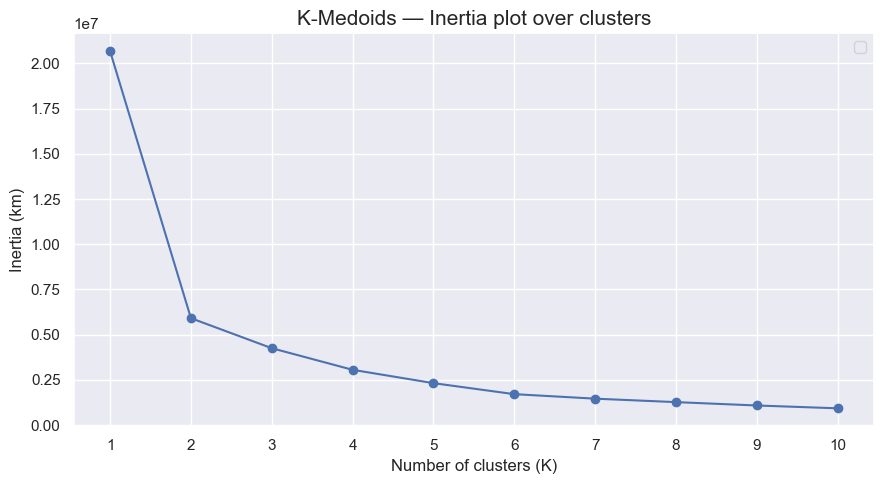

In [592]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(range_clusters), cost_w, marker="o")
ax.set_xticks(list(range_clusters))
ax.set_ylabel("Inertia (km)")
ax.set_xlabel("Number of clusters (K)")
ax.set_title("K-Medoids — Inertia plot over clusters", size=15)
ax.legend()
plt.tight_layout()
plt.show()

This inertia (within-cluster distance) curve for **K-Medoids** shows a **very steep improvement from K=1 → K=2**, followed by a continued but much more gradual decrease as K increases. The “elbow” — where adding more clusters starts yielding **diminishing returns** — appears around **K≈3–4**: inertia drops meaningfully up to this point, but the curve noticeably flattens afterwards, indicating that additional clusters mainly produce finer splits without large gains in compactness. From a practical/campaign perspective, **K=3** or **K=4** is a strong choice because it represents the elbow, capturing most of the reduction in inertia while keeping the number of territories manageable.

For n_clusters = 2, average silhouette: 0.7979


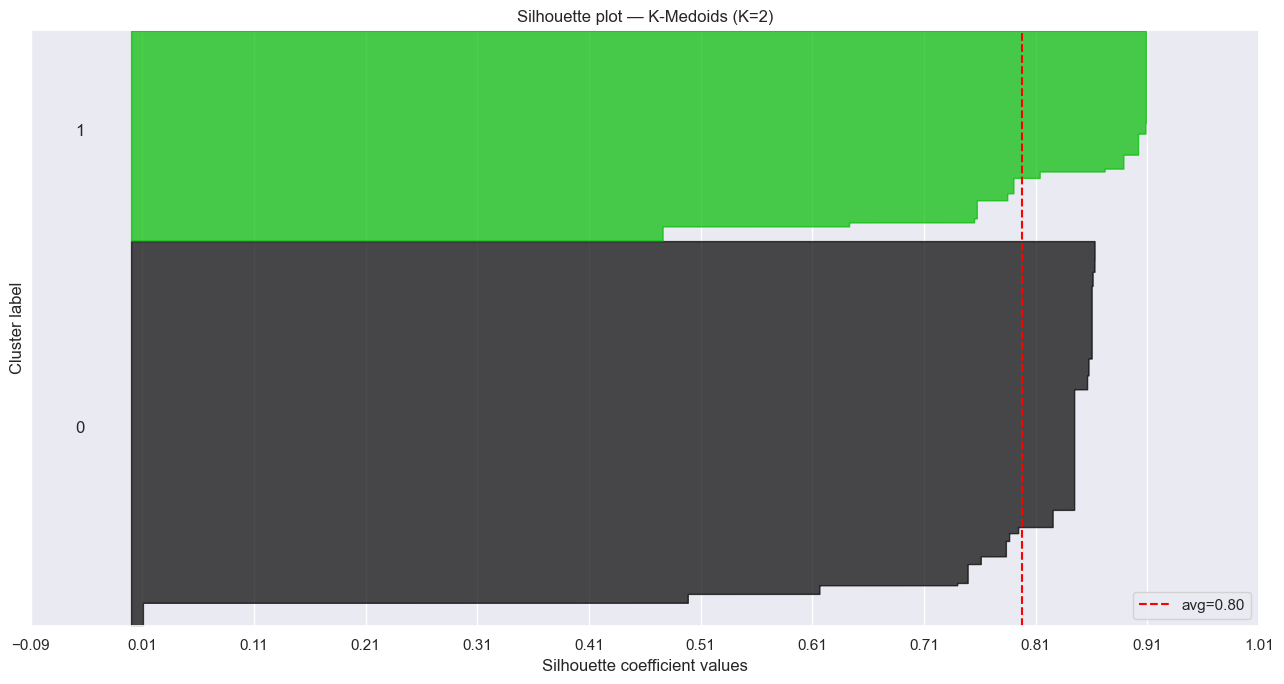

For n_clusters = 3, average silhouette: 0.6138


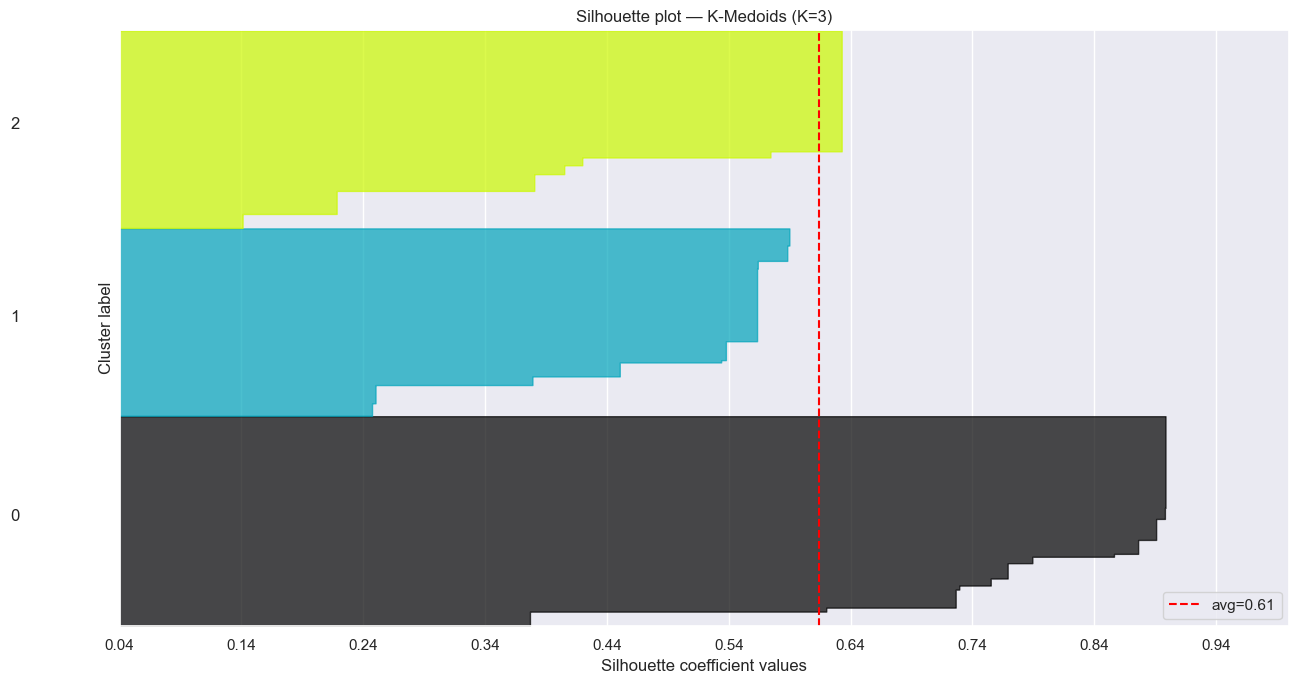

For n_clusters = 4, average silhouette: 0.6355


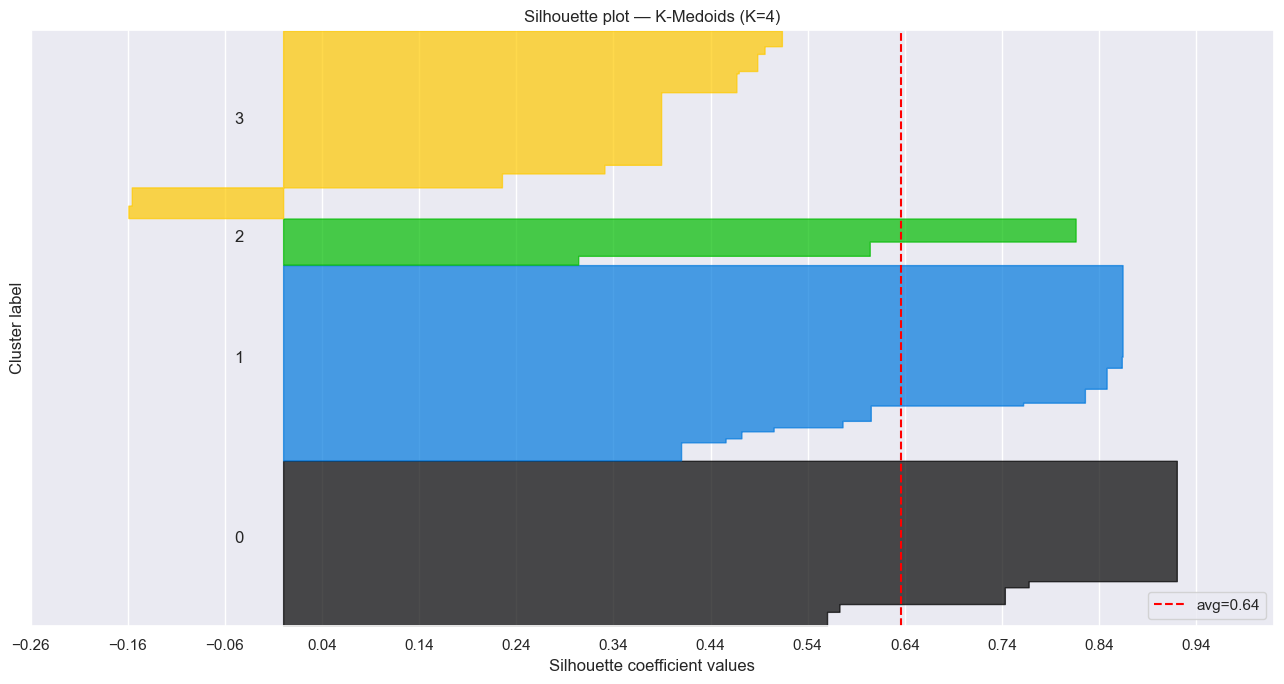

For n_clusters = 5, average silhouette: 0.7278


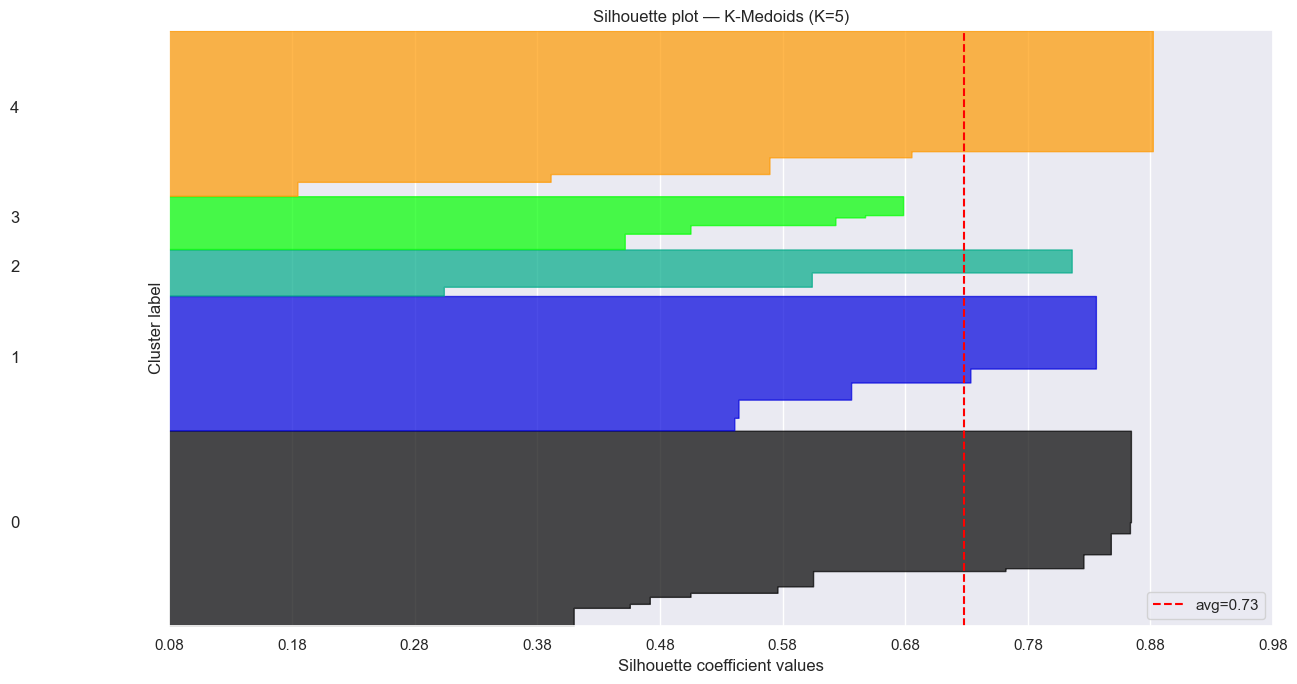

For n_clusters = 6, average silhouette: 0.7300


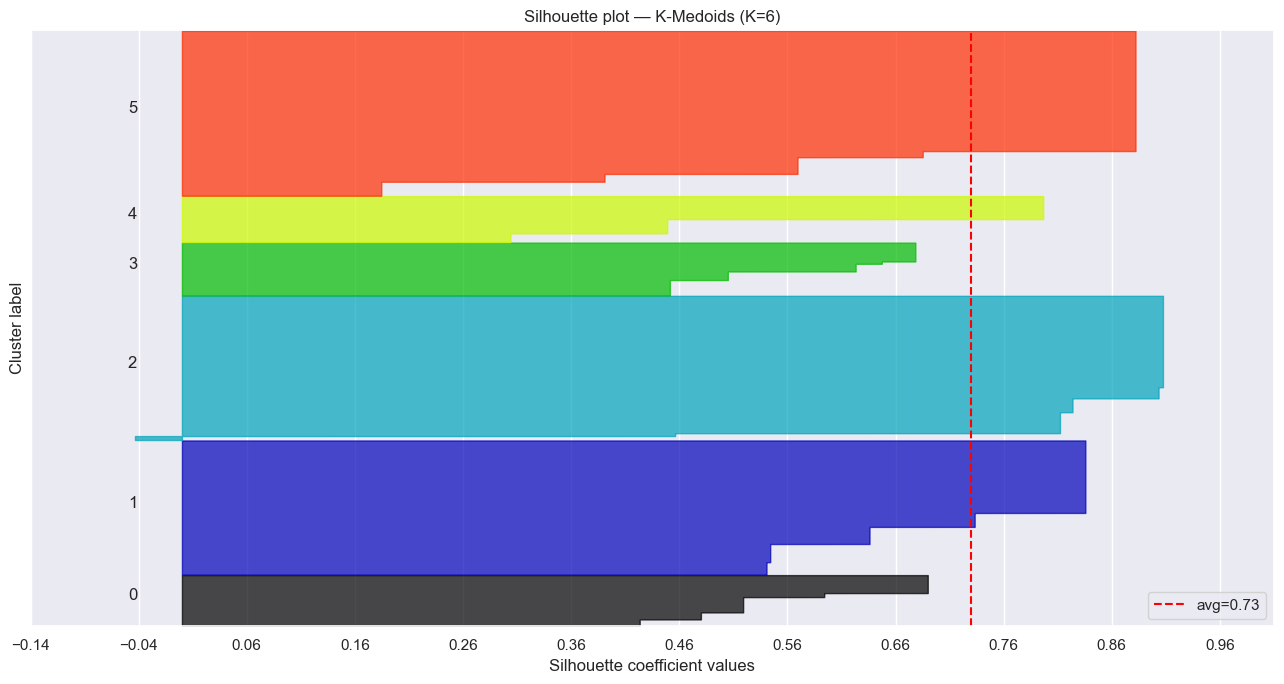

For n_clusters = 7, average silhouette: 0.7507


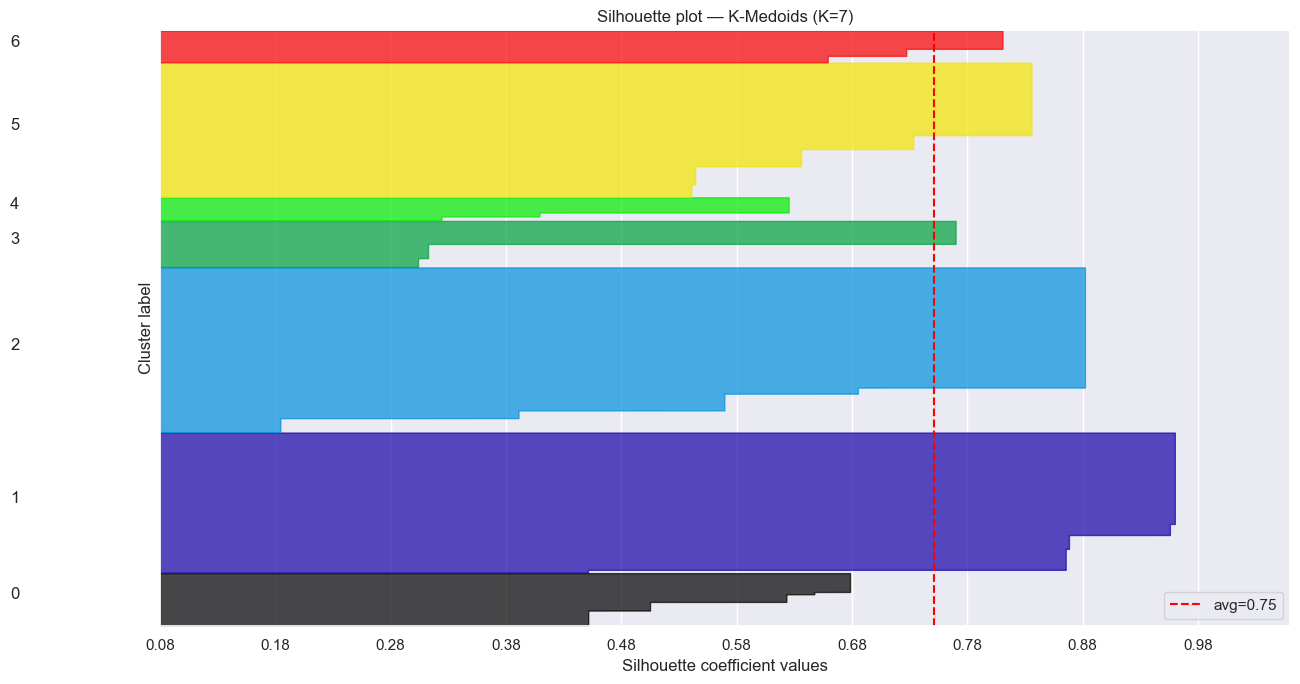

For n_clusters = 8, average silhouette: 0.7695


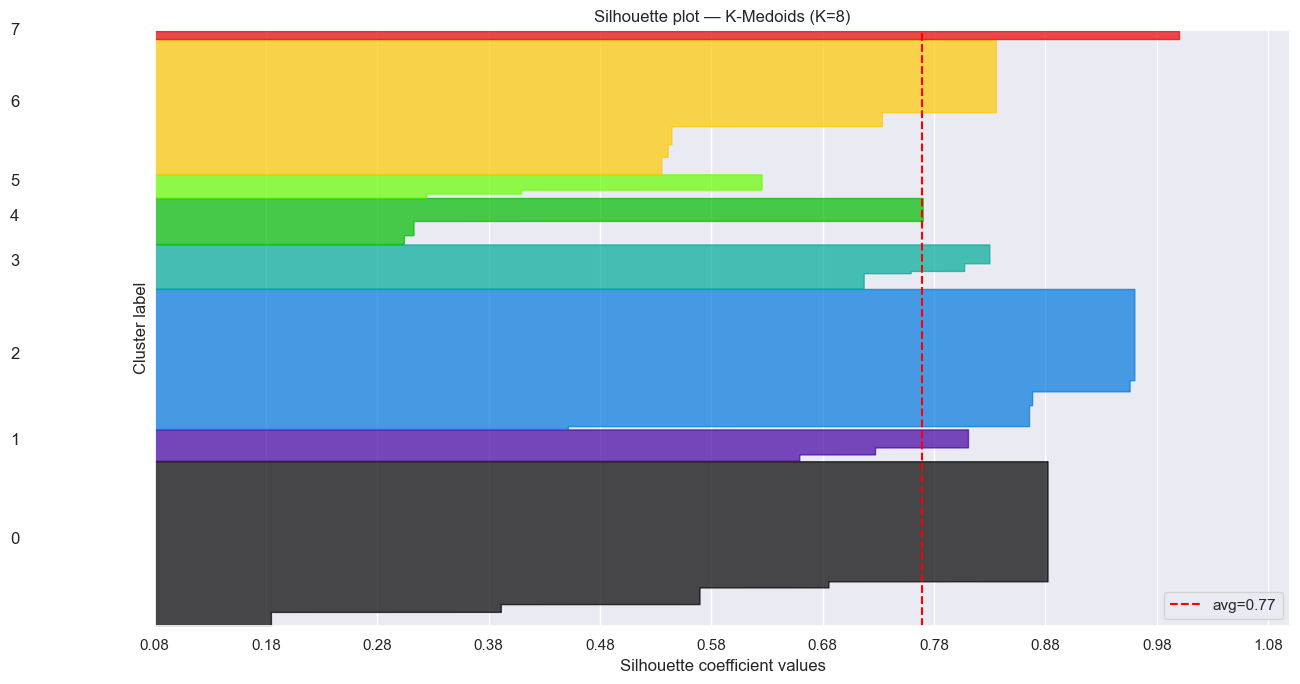

For n_clusters = 9, average silhouette: 0.7864


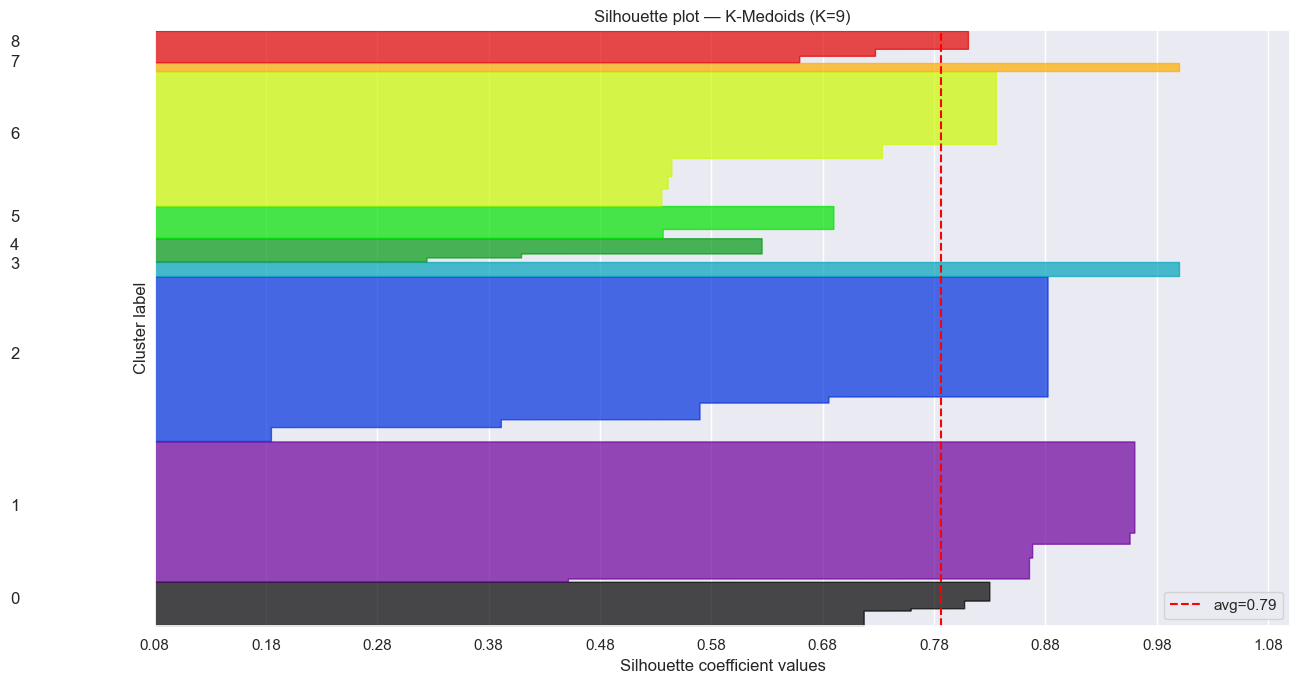

For n_clusters = 10, average silhouette: 0.7632


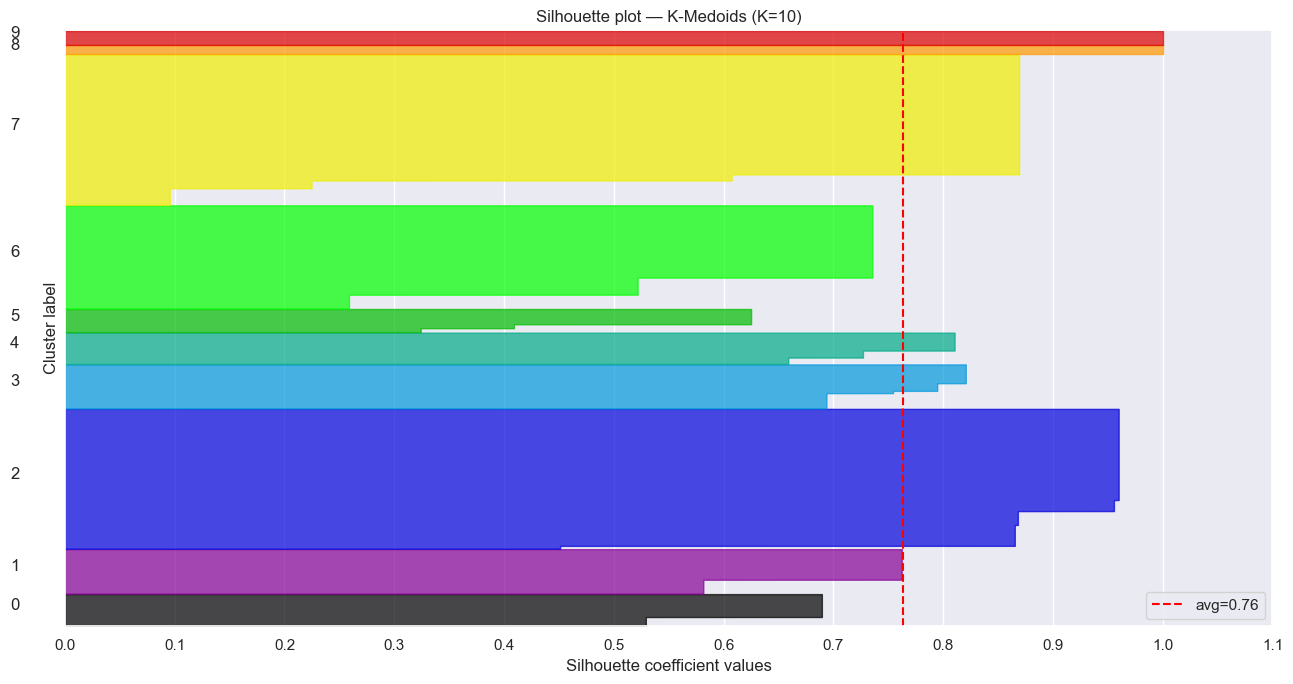

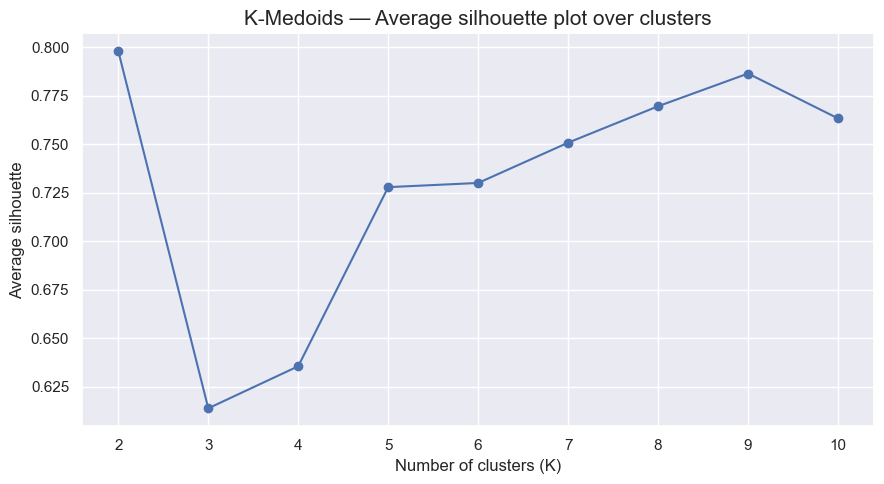

,k,avg_silhouette
0,2,0.797879
1,3,0.613834
2,4,0.635522
3,5,0.727817
4,6,0.729972
5,7,0.750733
6,8,0.769509
7,9,0.786368
8,10,0.763242


In [593]:
avg_silhouette = []

for k in range_clusters:
    if k == 1:
        continue

    model, labels = models[k]
    s = silhouette_samples(D_km, labels, metric="precomputed")
    sil_avg = float(np.mean(s))

    avg_silhouette.append((k, sil_avg))
    print(f"For n_clusters = {k}, average silhouette: {sil_avg:.4f}")

    plt.figure(figsize=(13, 7))
    y_lower = 10

    for i in range(k):
        ith_vals = s[labels == i]
        ith_vals.sort()

        size_cluster_i = ith_vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, ith_vals,
            facecolor=color, edgecolor=color, alpha=0.7
        )
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    plt.title(f"Silhouette plot — K-Medoids (K={k})")
    plt.xlabel("Silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=sil_avg, color="red", linestyle="--", label=f"avg={sil_avg:.2f}")
    plt.legend(loc="lower right")

    xmin = np.round(s.min() - 0.1, 2)
    xmax = np.round(s.max() + 0.1, 2)
    plt.xlim([xmin, xmax])
    plt.ylim([0, n_cust + (k + 1) * 10])
    plt.yticks([])
    plt.xticks(np.arange(xmin, xmax + 1e-9, 0.1))
    plt.tight_layout()
    plt.show()

avg_sil_df = pd.DataFrame(avg_silhouette, columns=["k", "avg_silhouette"])

plt.figure(figsize=(9, 5))
plt.plot(avg_sil_df["k"], avg_sil_df["avg_silhouette"], marker="o")
plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters (K)")
plt.title("K-Medoids — Average silhouette plot over clusters", size=15)
plt.tight_layout()
plt.show()

display(avg_sil_df)

Taken together, these plots assess K-Medoids cluster quality using the silhouette coefficient (within-cluster cohesion vs between-cluster separation) across different values of K. For K=3, the average silhouette is ~0.61, but the silhouette distribution is more heterogeneous: one cluster is very well separated (high values), while others contain many observations with lower silhouettes (closer to 0), suggesting blurrier boundaries and some overlap. For K=4, the average silhouette increases only slightly (~0.64) and the silhouette plot shows negative values, which indicates misassigned points and stronger overlap—so K=4 is not a good solution here. In contrast, K=5 shows a clear jump in quality, with an average silhouette of ~0.73 and most observations having consistently positive, relatively high silhouettes, indicating cleaner and better-separated clusters. This is also supported by the “Average silhouette over clusters” curve, where performance improves markedly starting around K≈5.

c:\Users\marta\Documents\01. Nova IMS\1st year\1st Semester\4.1. Data mining melhoria\project\Data-Mining-Project\Group25_EDA_Code\venv311\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\marta\Documents\01. Nova IMS\1st year\1st Semester\4.1. Data mining melhoria\project\Data-Mining-Project\Group25_EDA_Code\venv311\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\marta\Documents\01. Nova IMS\1st year\1st Semester\4.1. Data mining melhoria\project\Data-Min

K=3 metrics: {'k': 3, 'inertia': 4250846.724675983, 'cost_w': 4250846.724675983, 'silhouette_w': 0.6138344297901154}
K=6 metrics: {'k': 5, 'inertia': 2317720.58723774, 'cost_w': 2317720.58723774, 'silhouette_w': 0.7278168457200622}

K=3 customer counts:
geo_kmedoids_cluster
0    5102
2    4797
1    4560
Name: count, dtype: int64

K=5 customer counts:
geo_kmedoids_cluster
0    4755
4    4020
1    3273
3    1287
2    1124
Name: count, dtype: int64


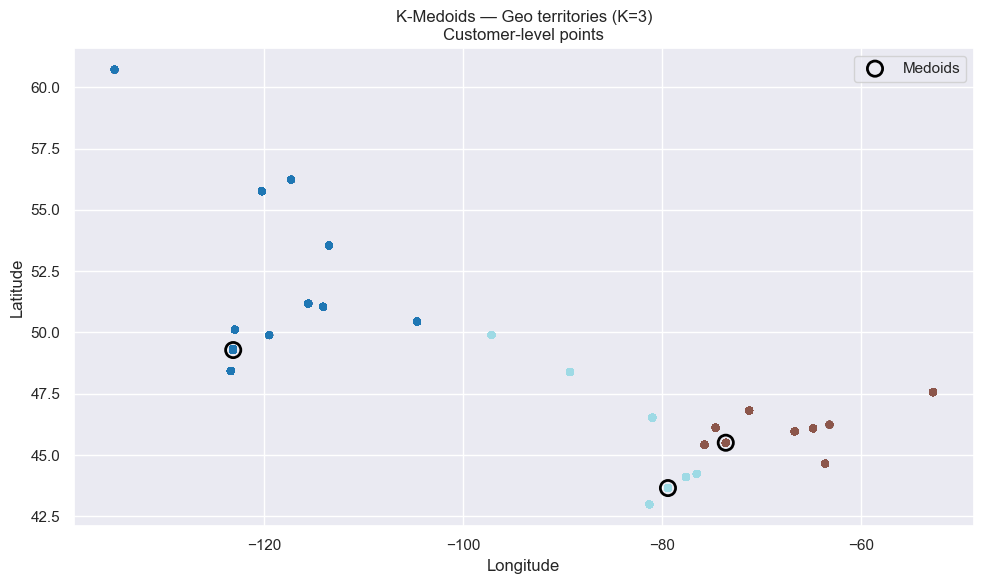

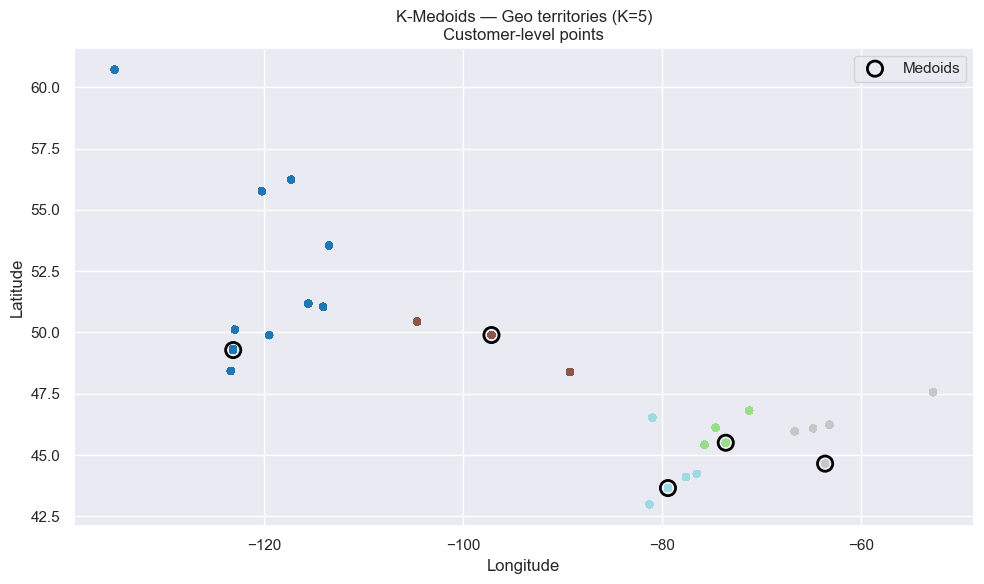

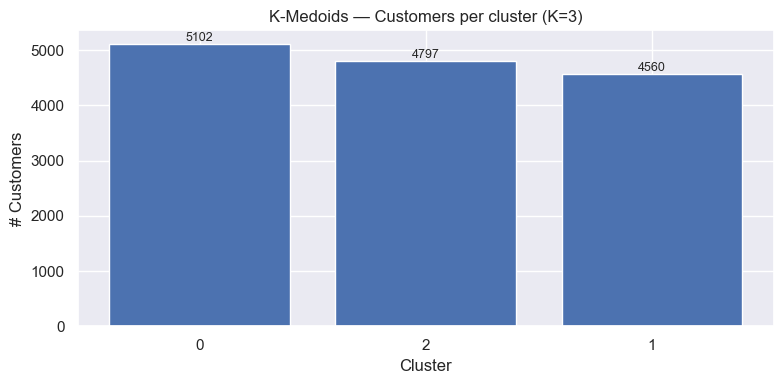

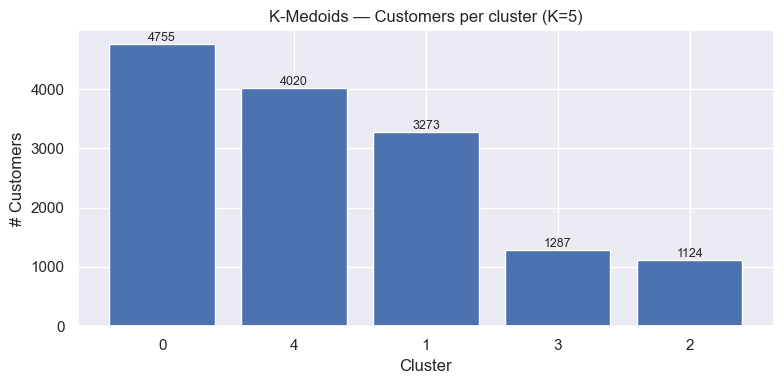

In [594]:
def build_outputs_for_k(k: int, D_km: np.ndarray, df_points: pd.DataFrame, w: np.ndarray, n_init: int = 60, random_state: int = 42):
    model, labels, inertia, cost_w = fit_kmedoids_best_weighted(D_km, k, w, n_init=n_init, random_state=random_state)
    s = silhouette_samples(D_km, labels, metric="precomputed") if k >= 2 else np.full(len(labels), np.nan)
    sil_w = float(np.sum(w * s) / np.sum(w)) if k >= 2 else np.nan

    df_labeled = df_points.copy()
    df_labeled["geo_kmedoids_cluster"] = labels
    df_labeled["is_medoid"] = 0
    df_labeled.loc[model.medoid_indices_, "is_medoid"] = 1

    metrics = {"k": k, "inertia": float(inertia), "cost_w": float(cost_w), "silhouette_w": float(sil_w)}
    return model, df_labeled, metrics


model_k3, df_k3, metrics_k3 = build_outputs_for_k(3, D_km, df_cust, w, n_init=60, random_state=42)
model_k6, df_k6, metrics_k6 = build_outputs_for_k(5, D_km, df_cust, w, n_init=60, random_state=42)

print("K=3 metrics:", metrics_k3)
print("K=6 metrics:", metrics_k6)

print("\nK=3 customer counts:")
print(df_k3["geo_kmedoids_cluster"].value_counts().sort_values(ascending=False))

print("\nK=5 customer counts:")
print(df_k6["geo_kmedoids_cluster"].value_counts().sort_values(ascending=False))

# bubble plots (customer-level)
plot_bubbles_customer_level(df_cust, df_k3["geo_kmedoids_cluster"].to_numpy(), model_k3.medoid_indices_, 3)
plot_bubbles_customer_level(df_cust, df_k6["geo_kmedoids_cluster"].to_numpy(), model_k6.medoid_indices_, 5)

# bar plots (#customers per cluster)
plot_cluster_counts_bar(df_k3, "geo_kmedoids_cluster", 3)
plot_cluster_counts_bar(df_k6, "geo_kmedoids_cluster", 5)

The two maps visualize **K-Medoids geographic territories** using customer-level latitude/longitude points, where colors indicate the assigned territory and the black-outlined markers indicate the **medoids** (representative locations that minimize within-cluster distances).

With **K=3**, the segmentation is **coarser**: one medoid anchors the western cluster (points around ~−120 longitude), while the remaining two medoids cover the broad eastern side, effectively grouping multiple distinct eastern population pockets into a smaller number of large territories. This produces simple, easy-to-operate regions, but it also means that geographically separated eastern sub-markets are treated as a single territory, which can blur local targeting.

With **K=5**, the solution becomes **more granular** and the medoids spread out to capture additional, meaningful structure—particularly across the centre/east. Instead of lumping all eastern locations together, the model introduces extra territories that separate distinct hubs (e.g., Great Lakes / Quebec corridor vs Atlantic area), and it also better isolates intermediate points that sit between the main west and east concentrations. The result is territories that are more locally coherent and better aligned with multiple population centres.


**For these reasons we decided to choose K=5.**

In [595]:
CLUSTER_COL = "geo_kmedoids_cluster"

labels_df = df_k6[[ID_COL, CLUSTER_COL]].drop_duplicates(subset=[ID_COL])
df_geo = fe_df_log.merge(labels_df, on=ID_COL, how="left")
df_geo_scaled = fe_df_scaled.merge(labels_df, on=ID_COL, how="left")

PROV_COL = "province"
CITY_COL = "city"
ZONE_COLS = ["location_code_Urban", "location_code_Suburban", "location_code_Rural"]
zone_cols = [c for c in ZONE_COLS if c in df_geo.columns]

def topk(s: pd.Series, k=3):
    return s.value_counts().head(k).index.tolist()

agg_dict = dict(
    n_customers=(ID_COL, "nunique"),
    centroid_lat=(LAT_COL, "median"),
    centroid_lon=(LON_COL, "median"),
)

if PROV_COL in df_geo.columns:
    agg_dict["top_provinces"] = (PROV_COL, lambda s: topk(s, k=2))
else:
    agg_dict["top_provinces"] = (ID_COL, lambda s: [])

if CITY_COL in df_geo.columns:
    agg_dict["top_cities"] = (CITY_COL, lambda s: topk(s, k=3))
else:
    agg_dict["top_cities"] = (ID_COL, lambda s: [])

agg_dict["pct_urban"] = ("location_code_Urban", "mean") if "location_code_Urban" in zone_cols else (ID_COL, lambda s: np.nan)
agg_dict["pct_suburban"] = ("location_code_Suburban", "mean") if "location_code_Suburban" in zone_cols else (ID_COL, lambda s: np.nan)
agg_dict["pct_rural"] = ("location_code_Rural", "mean") if "location_code_Rural" in zone_cols else (ID_COL, lambda s: np.nan)

geo_summary = (
    df_geo
    .groupby(CLUSTER_COL)
    .agg(**agg_dict)
    .reset_index()
)

for c in ["pct_urban", "pct_suburban", "pct_rural"]:
    if c in geo_summary.columns:
        geo_summary[c] = (geo_summary[c] * 100).round(1)

def dominant_area(row):
    pairs = {"Urban": row.get("pct_urban"), "Suburban": row.get("pct_suburban"), "Rural": row.get("pct_rural")}
    pairs = {k: v for k, v in pairs.items() if pd.notna(v)}
    return max(pairs, key=pairs.get) if pairs else np.nan

geo_summary["dominant_area"] = geo_summary.apply(dominant_area, axis=1)
geo_summary = geo_summary.sort_values("n_customers", ascending=False)

display(geo_summary)


,geo_kmedoids_cluster,n_customers,centroid_lat,centroid_lon,top_provinces,top_cities,pct_urban,pct_suburban,pct_rural,dominant_area
0,0,4755,49.282730,-123.120740,"[British Columbia, Alberta]","[Vancouver, Whistler, Edmonton]",32.4,33.9,33.6,Suburban
4,4,4020,43.653225,-79.383186,[Ontario],"[Toronto, Trenton, Kingston]",33.1,34.5,32.4,Suburban
1,1,3273,45.501690,-73.567253,"[Quebec, Ontario]","[Montreal, Ottawa, Quebec City]",32.1,32.8,35.1,Rural
3,3,1287,45.963589,-63.575237,"[New Brunswick, Nova Scotia]","[Halifax, Fredericton, St. John's]",32.9,35.1,32.0,Suburban
2,2,1124,49.895138,-97.138374,"[Manitoba, Saskatchewan]","[Winnipeg, Regina, Thunder Bay]",33.2,34.0,32.8,Suburban


For **K-Medoids (K=5)**, the geographic segmentation produces five campaign territories anchored around Canada’s main population corridors, with a clear size hierarchy. The largest territory (cluster **0**, **4,755** customers) is centred in **British Columbia/Alberta**, dominated by **Vancouver/Whistler/Edmonton**, indicating a broad Western market that blends major BC metros with Alberta reach. The second-largest territory (cluster **4**, **4,020** customers) is an **Ontario** hub centred on **Toronto** (plus Trenton/Kingston), capturing the densest customer concentration in the country. Cluster **1** (**3,273** customers) spans **Quebec + Ontario** and is centred around **Montréal/Ottawa/Quebec City**, representing the core Quebec–National Capital corridor and is the only territory with **Rural** as the dominant area type (35.1% rural vs 32.8% suburban), suggesting a relatively more dispersed customer footprint. The remaining two clusters are smaller but still actionable: cluster **3** (**1,287** customers) covers the Atlantic region (**New Brunswick/Nova Scotia**) around **Halifax/Fredericton/St. John’s**, and cluster **2** (**1,124** customers) captures the Prairies (**Manitoba/Saskatchewan**) around **Winnipeg/Regina/Thunder Bay**. Across all territories the Urban/Suburban/Rural mix is fairly balanced (~32–35% each), but **Suburban** dominates in four of the five clusters, consistent with customers being concentrated around metro peripheries rather than purely urban cores.


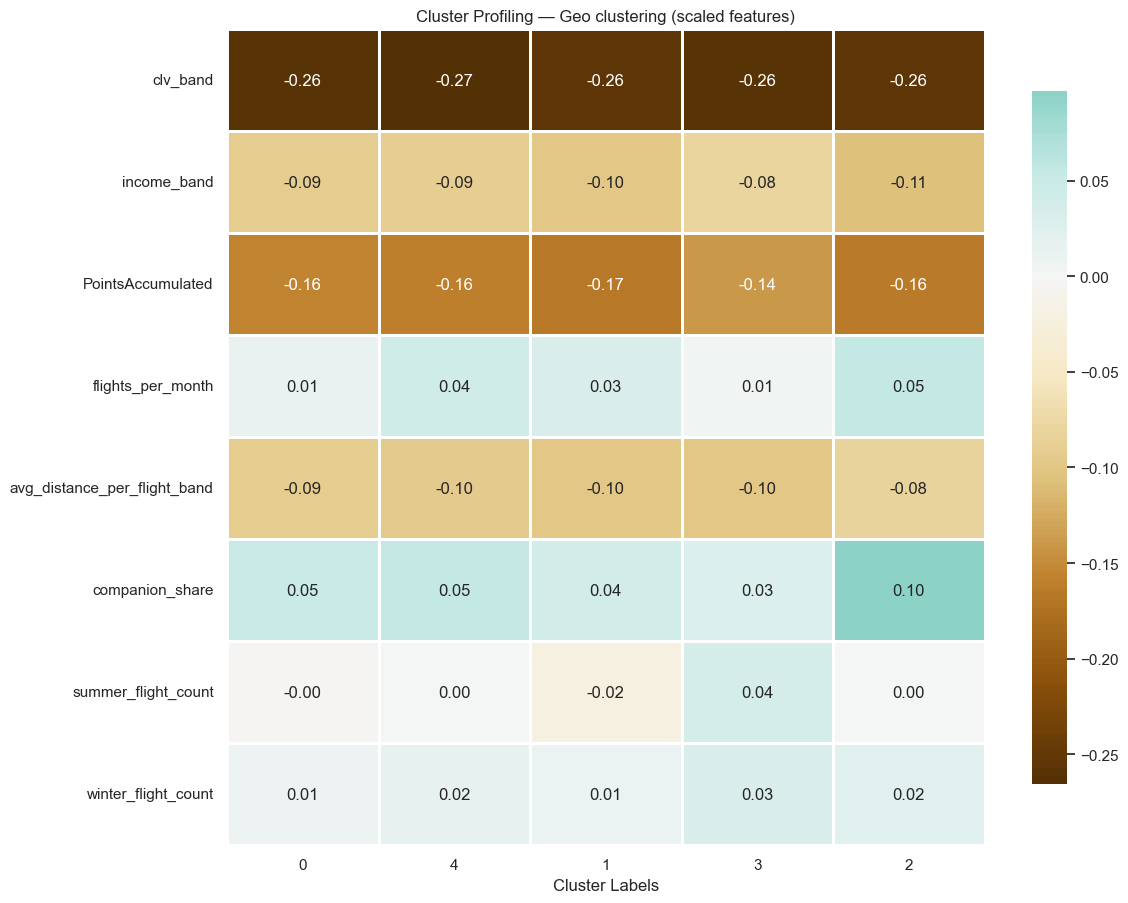

In [596]:
FEATURE_COLS = [
    "clv_band",
    "income_band",
    "PointsAccumulated",
    "flights_per_month",
    "avg_distance_per_flight_band",
    "companion_share",
    "summer_flight_count",
    "winter_flight_count",
]
feat_cols = [c for c in FEATURE_COLS if c in df_geo_scaled.columns]

profile = df_geo_scaled.groupby(CLUSTER_COL)[feat_cols].mean().T
cluster_order = (
    df_geo_scaled.groupby(CLUSTER_COL)[ID_COL].nunique()
    .sort_values(ascending=False)
    .index
)
profile = profile.loc[:, cluster_order]

n_rows, n_cols = profile.shape
fig_w = max(12, 1.4 * n_cols + 3)
fig_h = max(6, 0.9 * n_rows + 2)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    profile,
    center=0,
    annot=True,
    fmt=".2f",
    cmap="BrBG",
    linewidths=2.0,
    linecolor="white",
    cbar_kws={"shrink": 0.85},
    ax=ax
)
ax.set_xlabel("Cluster Labels")
ax.set_ylabel("")
ax.set_title("Cluster Profiling — Geo clustering (scaled features)")
plt.tight_layout()
plt.show()



This profiling heatmap summarizes the **mean scaled feature values** for each **K-Medoids geographic cluster (K=5)**, where values above 0 indicate **above-average** levels relative to the full dataset and values below 0 indicate **below-average** levels. Overall, the clusters look **behaviourally very similar**: all territories are slightly below average on **CLV band** (~−0.26/−0.27), **income band** (~−0.08 to −0.11), **PointsAccumulated** (~−0.14 to −0.17), and **average distance per flight** (~−0.08 to −0.10), suggesting that the geo segmentation is not strongly separating customers by value or long-haul intensity. The clearest differentiators are **engagement and travel style**: **flights_per_month** is mildly above average in every cluster but peaks in clusters **2** (~0.05) and **4** (~0.04), while **companion_share** is also above average everywhere and is noticeably highest in cluster **2** (~0.10), indicating a territory with relatively more companion travel. Seasonality effects are small across the board (summer and winter counts close to 0), with only a slight uplift in **summer_flight_count** for cluster **3** (~0.04) and a modest increase in **winter_flight_count** for cluster **3** (~0.03). In short, these territories are primarily **geographic groupings** with only subtle behavioural differences, and the most actionable profiling signal is that cluster **2** stands out as the most **social/frequent travel** segment.

# Hierarchical Clustering:

Customer-level rows: 14459
Estimated D_km size (float32): 0.78 GB
Estimated D_km size (float64): 1.56 GB


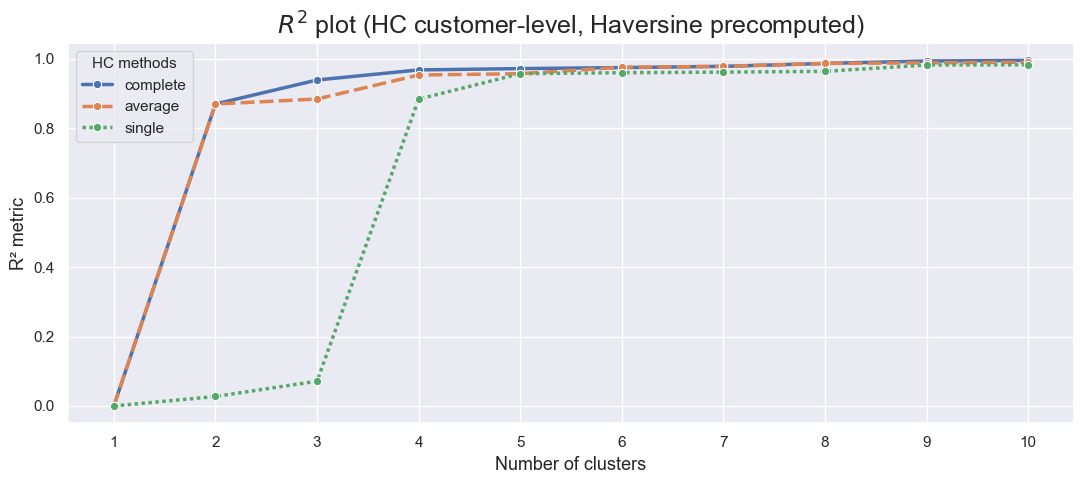

In [597]:
LAT_COL = "latitude"
LON_COL = "longitude"
EARTH_RADIUS_KM = 6371.0

X_deg = (
    fe_df_log[[LAT_COL, LON_COL]]
    .dropna()
    .to_numpy(dtype=np.float64)
)
n = X_deg.shape[0]

def estimate_mem_gb(n, dtype=np.float32):
    bytes_per = np.dtype(dtype).itemsize
    return (n * n * bytes_per) / (1024**3)

print(f"Customer-level rows: {n}")
print(f"Estimated D_km size (float32): {estimate_mem_gb(n, np.float32):.2f} GB")
print(f"Estimated D_km size (float64): {estimate_mem_gb(n, np.float64):.2f} GB")

try:
    X_rad = np.radians(X_deg)
    D_km = haversine_distances(X_rad)  
    D_km = (D_km * EARTH_RADIUS_KM).astype(np.float32)  
    np.fill_diagonal(D_km, 0.0)
except MemoryError:
    raise MemoryError(
        "MemoryError: D_km customer-level é grande demais. "
        "Se isto acontecer, usa unique locations + weights (recomendado)."
    )

def get_ss(df_, feats):
    df2 = df_[feats]
    return np.sum(df2.var(ddof=0) * df2.shape[0])

def get_ssw(df_, feats, label_col):
    return (
        df_[feats + [label_col]]
        .groupby(label_col)
        .apply(lambda g: get_ss(g, feats), include_groups=False)
        .sum()
    )

def get_rsq(df_, feats, label_col):
    sst = get_ss(df_, feats)
    ssw = get_ssw(df_, feats, label_col)
    return (sst - ssw) / sst if sst > 0 else np.nan

def _hc_precomputed(k, linkage):
    try:
        return AgglomerativeClustering(n_clusters=k, linkage=linkage, metric="precomputed")
    except TypeError:
        return AgglomerativeClustering(n_clusters=k, linkage=linkage, affinity="precomputed")

def get_r2_hc_precomputed(df_X, D, link_method, max_nclus=10, min_nclus=1):
    feats = df_X.columns.tolist()
    r2 = []
    for k in range(min_nclus, max_nclus + 1):
        hc = _hc_precomputed(k, link_method)
        labels = hc.fit_predict(D)
        tmp = df_X.copy()
        tmp["labels"] = labels
        r2.append(get_rsq(tmp, feats, "labels"))
    return np.array(r2)

hc_methods = ["complete", "average", "single"]  
max_nclus = 10

X_for_r2 = pd.DataFrame(X_deg, columns=[LAT_COL, LON_COL])

r2_hc = np.vstack([
    get_r2_hc_precomputed(X_for_r2, D_km, link_method=link, max_nclus=max_nclus)
    for link in hc_methods
])

r2_df = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods)

sns.set()
plt.figure(figsize=(11, 5))
sns.lineplot(data=r2_df, linewidth=2.5, marker="o")
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R² metric", fontsize=13)
plt.title(r"$R^2$ plot (HC customer-level, Haversine precomputed)", fontsize=18)
plt.tight_layout()
plt.show()


This R^2 curve shows how much geographic variance is explained by Hierarchical Clustering (HC) as the number of clusters 𝐾 increases, comparing three linkage strategies (complete, average, single) using precomputed Haversine distances. 2
 rises sharply from K=1 to 𝐾=2 for both complete and average, indicating that moving from one territory to two captures most of the large-scale geographic separation in the data. After that, gains become progressively smaller: complete linkage continues to improve from 𝐾=2 to 𝐾=5.
 
This plot supports complete linkage as the most consistent option across small 𝐾: it achieves high 𝑅^2 early and reaches the plateau quickly.

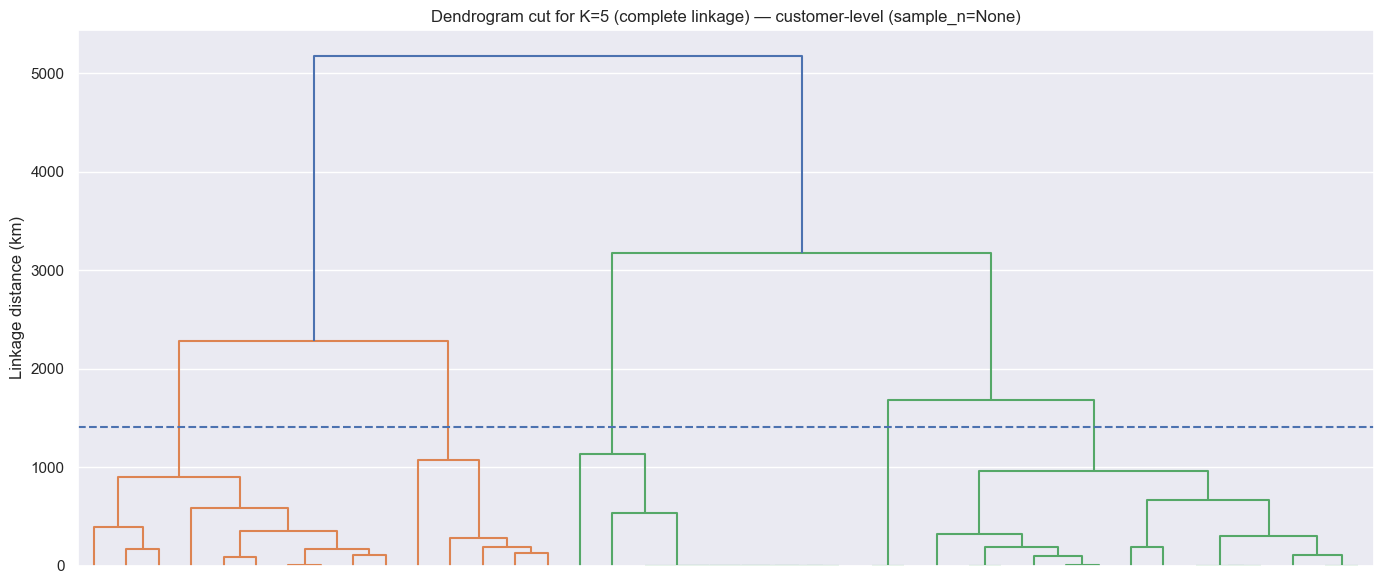

Cut height for K=5: h ≈ 1407.16 km


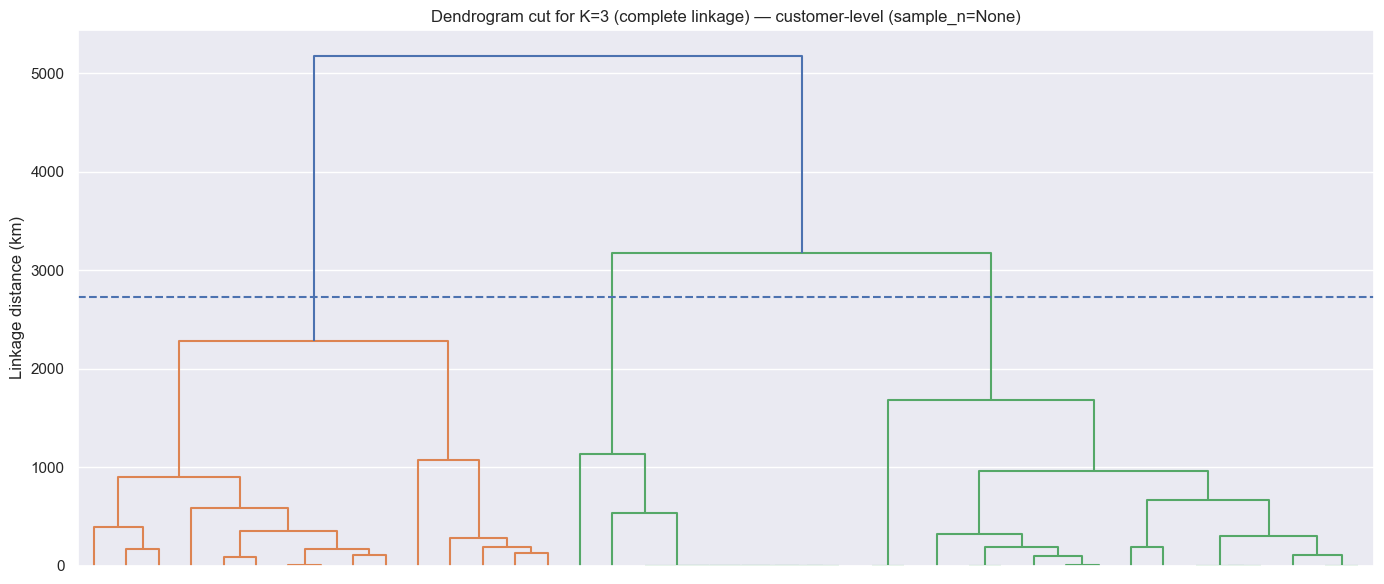

Cut height for K=3: h ≈ 2724.77 km


In [598]:
LAT_COL = "latitude"
LON_COL = "longitude"
EARTH_RADIUS_KM = 6371.0

X_deg_all = fe_df_log[[LAT_COL, LON_COL]].dropna().to_numpy(dtype=np.float64)
n_all = X_deg_all.shape[0]

rng = np.random.default_rng(42)

if sample_n is not None and n_all > sample_n:
    idx = rng.choice(n_all, size=sample_n, replace=False)
    X_deg = X_deg_all[idx]
else:
    X_deg = X_deg_all

X_rad = np.radians(X_deg)

D_km = (haversine_distances(X_rad) * EARTH_RADIUS_KM).astype(np.float32)
D_km = 0.5 * (D_km + D_km.T)
np.fill_diagonal(D_km, 0.0)

d_condensed = squareform(D_km, checks=False)
Z = linkage(d_condensed, method="complete")  

def cut_height_for_k(Z, k):
    n = Z.shape[0] + 1
    if k <= 1:
        return Z[-1, 2] + 1e-9
    if k >= n:
        return 0.0
    m = n - k
    return (Z[m - 1, 2] + Z[m, 2]) / 2.0

for K in [5, 3]:
    h = cut_height_for_k(Z, K)

    plt.figure(figsize=(14, 6))
    dendrogram(
        Z,
        truncate_mode="lastp",  
        p=40,                   
        show_leaf_counts=True,
        no_labels=True
    )
    plt.axhline(y=h, linestyle="--")
    plt.title(f"Dendrogram cut for K={K} (complete linkage) — customer-level (sample_n={sample_n})")
    plt.ylabel("Linkage distance (km)")
    plt.tight_layout()
    plt.show()

    print(f"Cut height for K={K}: h ≈ {h:.2f} km")


These dendrograms show the **hierarchical structure of customer locations** under **complete-linkage HC** using precomputed Haversine distances, with the dashed horizontal line indicating the **cut height** that yields the chosen number of territories. For **K=3**, the cut is made at a **higher linkage distance**, producing three very broad “macro-regions” that only separate after large geographic gaps: this reflects the dominant coast-to-coast separation and results in **coarse, highly aggregated territories**. 

For **K=5**, the cut height is **lower**, which splits the same tree earlier and creates **two additional, more local sub-territories** within the larger east/west structure. The large vertical jumps near the top of both trees indicate that the biggest merges happen only at very large distances, i.e., the data contain a few **strongly separated geographic groupings**; choosing **K=5** leverages this by adding granularity while still cutting well below the largest merges, whereas **K=3** prioritizes simplicity at the expense of local differentiation.

Customer-level rows: 14459
Estimated D_km size (float32): 0.78 GB
Estimated D_km size (float64): 1.56 GB

K=3 customer counts:
geo_hc_cluster_k3
0    8580
1    4755
2    1124
Name: count, dtype: int64

K=5 customer counts:
geo_hc_cluster_k5
3    7293
2    4658
1    1287
0    1124
4      97
Name: count, dtype: int64


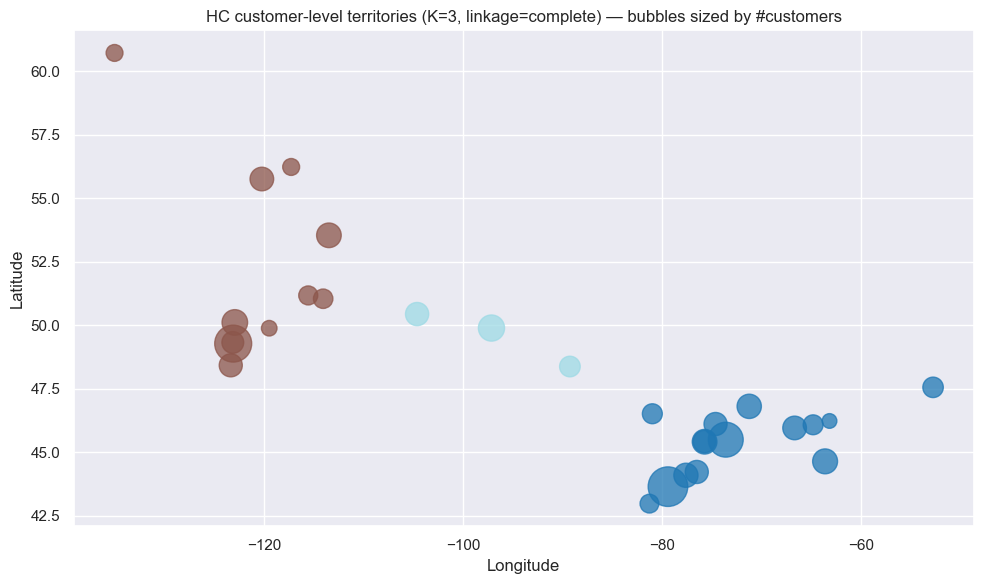

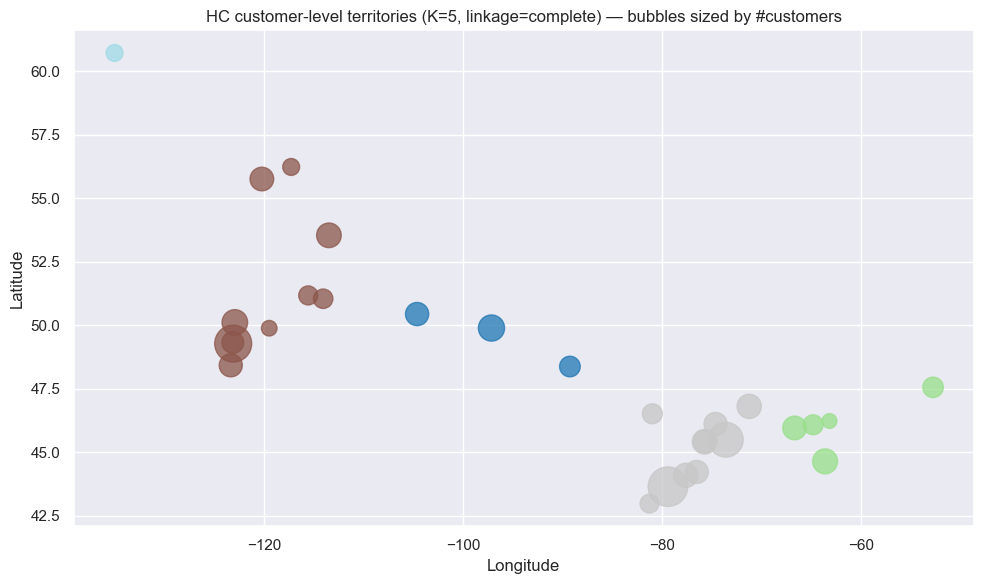

In [599]:
ID_COL  = "Loyalty#"
LAT_COL = "latitude"
LON_COL = "longitude"
EARTH_RADIUS_KM = 6371.0

df_src = fe_df_log.copy()

df_xy = df_src[[ID_COL, LAT_COL, LON_COL]].dropna().reset_index(drop=True)
n = len(df_xy)

def est_gb(n, dtype=np.float32):
    return (n * n * np.dtype(dtype).itemsize) / (1024**3)

print(f"Customer-level rows: {n}")
print(f"Estimated D_km size (float32): {est_gb(n, np.float32):.2f} GB")
print(f"Estimated D_km size (float64): {est_gb(n, np.float64):.2f} GB")

X_rad = np.radians(df_xy[[LAT_COL, LON_COL]].to_numpy(dtype=np.float64))

D_km = (haversine_distances(X_rad) * EARTH_RADIUS_KM).astype(np.float32)

D_km = 0.5 * (D_km + D_km.T)
np.fill_diagonal(D_km, 0.0)

def fit_hc_precomputed(D_km: np.ndarray, n_clusters: int, linkage: str = "complete") -> np.ndarray:
    try:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric="precomputed",
            linkage=linkage
        )
    except TypeError:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            affinity="precomputed",
            linkage=linkage
        )
    return model.fit_predict(D_km)

linkage_method = "complete"  

labels_k3 = fit_hc_precomputed(D_km, n_clusters=3, linkage=linkage_method)
labels_k5 = fit_hc_precomputed(D_km, n_clusters=5, linkage=linkage_method)

df_geo_k3 = df_xy.copy()
df_geo_k5 = df_xy.copy()
df_geo_k3["geo_hc_cluster_k3"] = labels_k3
df_geo_k5["geo_hc_cluster_k5"] = labels_k5

print("\nK=3 customer counts:")
print(df_geo_k3["geo_hc_cluster_k3"].value_counts().sort_values(ascending=False))

print("\nK=5 customer counts:")
print(df_geo_k5["geo_hc_cluster_k5"].value_counts().sort_values(ascending=False))

def bubble_plot_from_customer_level(df_geo_k: pd.DataFrame, cluster_col: str, title: str, size_scale: float = 15.0):
    loc = (
        df_geo_k.groupby([LAT_COL, LON_COL])[ID_COL]
                .nunique()
                .reset_index(name="n_customers")
    )

    loc_cluster = (
        df_geo_k.groupby([LAT_COL, LON_COL])[cluster_col]
                .agg(lambda s: s.mode().iat[0] if len(s.mode()) else s.iloc[0])
                .reset_index(name="cluster")
    )

    loc = loc.merge(loc_cluster, on=[LAT_COL, LON_COL], how="left")

    sizes = np.sqrt(loc["n_customers"].to_numpy()) * size_scale

    plt.figure(figsize=(10, 6))
    plt.scatter(
        loc[LON_COL], loc[LAT_COL],
        s=sizes, alpha=0.75,
        c=loc["cluster"], cmap="tab20"
    )
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()

bubble_plot_from_customer_level(
    df_geo_k3,
    cluster_col="geo_hc_cluster_k3",
    title=f"HC customer-level territories (K=3, linkage={linkage_method}) — bubbles sized by #customers"
)

bubble_plot_from_customer_level(
    df_geo_k5,
    cluster_col="geo_hc_cluster_k5",
    title=f"HC customer-level territories (K=5, linkage={linkage_method}) — bubbles sized by #customers"
)

These bubble maps show **hierarchical (complete-linkage) geographic territories** at two levels of granularity, where each point is a location and bubble size reflects the **number of customers at that location**. With **K=3**, the solution yields **three broad macro-territories**: a clear **West cluster** (around longitudes ~−125), a **Central/Prairie corridor** (few locations around ~−105 to −90), and a large **East cluster** (around ~−80 to −55) that groups multiple eastern hubs into a single operational territory. 

With **K=5**, the same high-level structure remains, but the model adds **two extra territories** by splitting the large East region into more locally coherent sub-territories and better isolating intermediate central locations. Overall, **K=3** prioritizes simplicity (fewer, very large regions) but can blur distinct eastern sub-markets, whereas **K=5** provides **more actionable regional specificity** while still preserving compact, geographically coherent groupings.

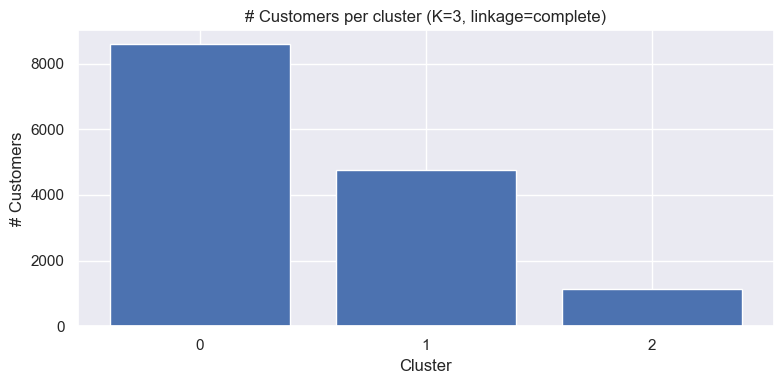

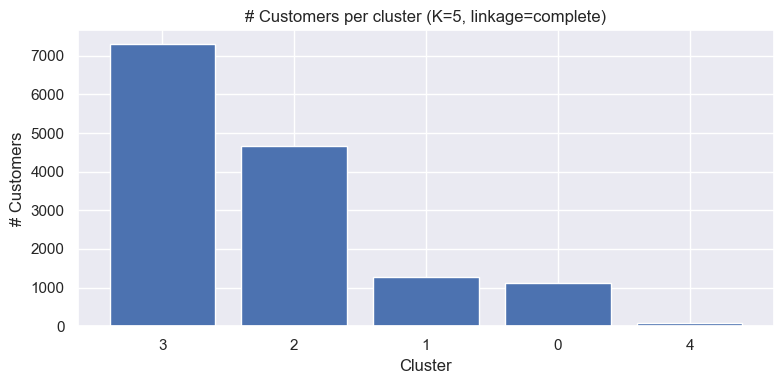

In [600]:
def barplot_cluster_counts(df_geo: pd.DataFrame, cluster_col: str, title: str):
    counts = (
        df_geo.groupby(cluster_col)[ID_COL]
              .nunique()
              .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel("Cluster")
    plt.ylabel("# Customers")
    plt.tight_layout()
    plt.show()

# K=3
barplot_cluster_counts(
    df_geo_k3,
    cluster_col="geo_hc_cluster_k3",
    title=f"# Customers per cluster (K=3, linkage={linkage_method})"
)

# K=5
barplot_cluster_counts(
    df_geo_k5,
    cluster_col="geo_hc_cluster_k5",
    title=f"# Customers per cluster (K=5, linkage={linkage_method})"
)


These bar charts show the **customer distribution across hierarchical (complete-linkage) geographic clusters** for two choices of granularity. 

With **K=3**, the segmentation is **highly imbalanced**: one very large territory (cluster 0) contains the majority of customers, a second territory (cluster 1) is medium-sized, and the third (cluster 2) is much smaller. This indicates that at K=3 the model is effectively capturing the dominant macro-structure (one main population corridor plus two smaller regions), but it may be **too coarse** for differentiated activation because most customers sit in a single territory. 

With **K=5**, the distribution becomes more informative: the two largest territories still account for most customers, but some of the previously “merged” mass is split into additional **mid-sized** and **small** territories, improving regional specificity. However, K=5 also introduces one **very small cluster** (cluster 4), which may be operationally weak or unstable.

**For these reasons, we decided to choose K=5 for our geo-based segmentation.**

In [601]:
CLUSTER_COL = "geo_hc_cluster_k5"

labels_df = (
    df_geo_k5[[ID_COL, CLUSTER_COL]]
    .drop_duplicates(subset=[ID_COL])
)

df_geo_hc = fe_df_log.merge(labels_df, on=ID_COL, how="left")
df_geo_hc_scaled_hc = fe_df_scaled.merge(labels_df, on=ID_COL, how="left")

PROV_COL = "province"
CITY_COL = "city"
ZONE_COLS = ["location_code_Urban", "location_code_Suburban", "location_code_Rural"]
zone_cols = [c for c in ZONE_COLS if c in df_geo_hc.columns]

def topk(s: pd.Series, k=3):
    return s.value_counts().head(k).index.tolist()

agg_dict = dict(
    n_customers=(ID_COL, "nunique"),
    centroid_lat=(LAT_COL, "median"),
    centroid_lon=(LON_COL, "median"),
)

agg_dict["top_provinces"] = (PROV_COL, lambda s: topk(s, k=2)) if PROV_COL in df_geo_hc.columns else (ID_COL, lambda s: [])
agg_dict["top_cities"]    = (CITY_COL, lambda s: topk(s, k=3)) if CITY_COL in df_geo_hc.columns else (ID_COL, lambda s: [])

agg_dict["pct_urban"]    = ("location_code_Urban", "mean")    if "location_code_Urban"    in zone_cols else (ID_COL, lambda s: np.nan)
agg_dict["pct_suburban"] = ("location_code_Suburban", "mean") if "location_code_Suburban" in zone_cols else (ID_COL, lambda s: np.nan)
agg_dict["pct_rural"]    = ("location_code_Rural", "mean")    if "location_code_Rural"    in zone_cols else (ID_COL, lambda s: np.nan)

geo_summary_hc = (
    df_geo_hc
    .groupby(CLUSTER_COL)
    .agg(**agg_dict)
    .reset_index()
)

for c in ["pct_urban", "pct_suburban", "pct_rural"]:
    if c in geo_summary_hc.columns:
        geo_summary_hc[c] = (geo_summary_hc[c] * 100).round(1)

def dominant_area(row):
    pairs = {
        "Urban": row.get("pct_urban"),
        "Suburban": row.get("pct_suburban"),
        "Rural": row.get("pct_rural"),
    }
    pairs = {k: v for k, v in pairs.items() if pd.notna(v)}
    return max(pairs, key=pairs.get) if pairs else np.nan

geo_summary_hc["dominant_area"] = geo_summary_hc.apply(dominant_area, axis=1)
geo_summary_hc = geo_summary_hc.sort_values("n_customers", ascending=False)

display(geo_summary_hc)

,geo_hc_cluster_k5,n_customers,centroid_lat,centroid_lon,top_provinces,top_cities,pct_urban,pct_suburban,pct_rural,dominant_area
3,3,7293,44.231171,-77.576309,"[Ontario, Quebec]","[Toronto, Montreal, Ottawa]",32.6,33.8,33.6,Suburban
2,2,4658,49.282730,-123.120740,"[British Columbia, Alberta]","[Vancouver, Whistler, Edmonton]",32.5,34.0,33.5,Suburban
1,1,1287,45.963589,-63.575237,"[New Brunswick, Nova Scotia]","[Halifax, Fredericton, St. John's]",32.9,35.1,32.0,Suburban
0,0,1124,49.895138,-97.138374,"[Manitoba, Saskatchewan]","[Winnipeg, Regina, Thunder Bay]",33.2,34.0,32.8,Suburban
4,4,97,60.721188,-135.056840,[Yukon],[Whitehorse],29.9,32.0,38.1,Rural


This table summarizes the **Hierarchical Clustering geo territories (K=5, complete linkage)** and shows that the segmentation is **highly concentrated in a few large hubs**, with one clear outlier micro-territory. The largest territory (**cluster 3**, **7,293 customers**) spans **Ontario + Quebec** and is anchored around **Toronto / Montreal / Ottawa**, representing the main population corridor; it has a balanced Urban/Suburban/Rural mix but is marginally **Suburban-dominant**. The second-largest territory (**cluster 2**, **4,658 customers**) covers **British Columbia + Alberta**, centred on **Vancouver / Whistler / Edmonton**, again with a very balanced area-type split and **Suburban** as the dominant category. Two smaller but still campaign-usable territories capture the **Atlantic region** (**cluster 1**, **1,287 customers**, centred on **Halifax / Fredericton / St. John’s**) and the **Prairies** (**cluster 0**, **1,124 customers**, centred on **Winnipeg / Regina / Thunder Bay**), both also Suburban-dominant. Finally, **cluster 4** is a very small and geographically isolated territory (**97 customers**) centred on **Whitehorse (Yukon)**, with **Rural** as the dominant area type—this is likely an outlier-driven micro-cluster and may be operationally weak, making it a candidate for merging into the nearest large territory or treating as “other/remote” depending on campaign constraints.

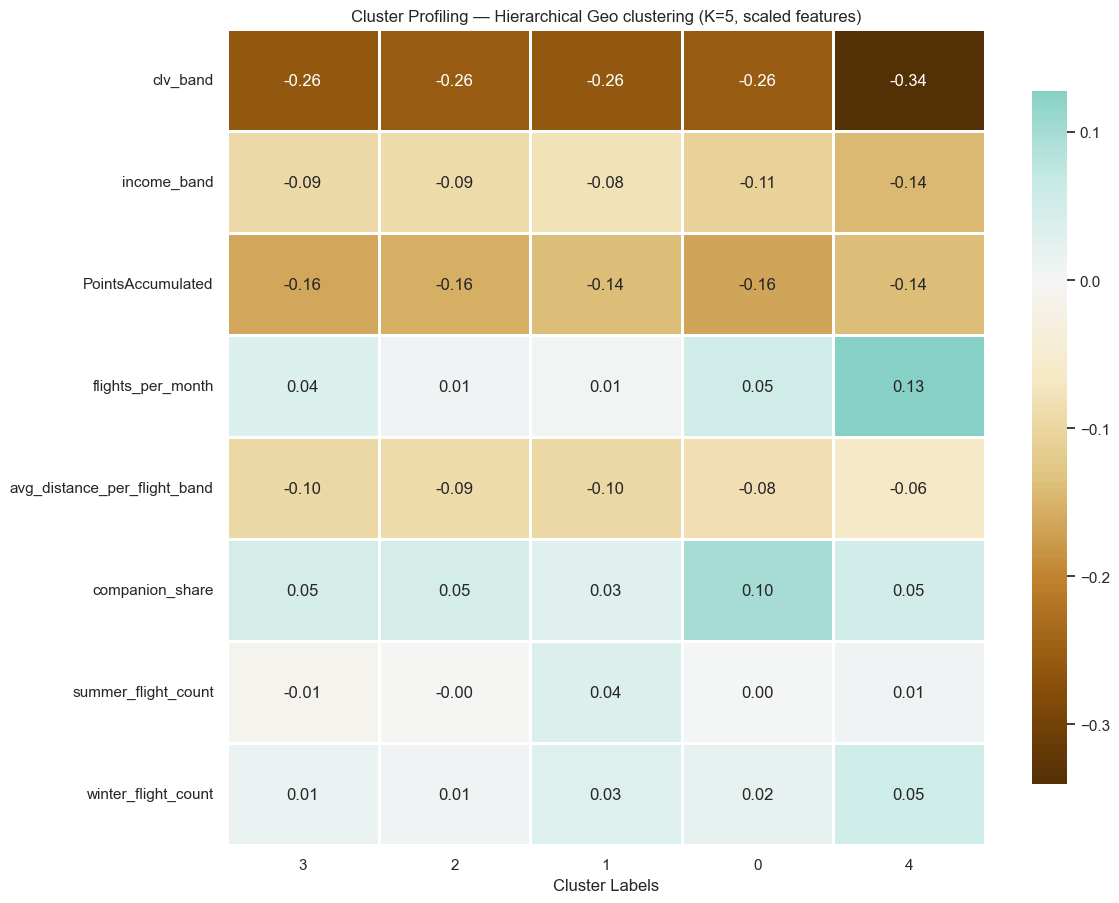

In [602]:
FEATURE_COLS = [
    "clv_band",
    "income_band",
    "PointsAccumulated",
    "flights_per_month",
    "avg_distance_per_flight_band",
    "companion_share",
    "summer_flight_count",
    "winter_flight_count",
]

def plot_hc_profiling_heatmap(df_geo_scaled: pd.DataFrame, cluster_col: str, title: str):
    feat_cols = [c for c in FEATURE_COLS if c in df_geo_scaled.columns]

    feat_cols_num = [
        c for c in feat_cols
        if pd.api.types.is_numeric_dtype(df_geo_scaled[c])
    ]

    profile = df_geo_scaled.groupby(cluster_col)[feat_cols_num].mean().T

    cluster_order = (
        df_geo_scaled.groupby(cluster_col)[ID_COL].nunique()
        .sort_values(ascending=False)
        .index
    )
    profile = profile.loc[:, cluster_order]

    n_rows, n_cols = profile.shape
    fig_w = max(12, 1.4 * n_cols + 3)
    fig_h = max(6, 0.9 * n_rows + 2)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        profile,
        center=0,
        annot=True,
        fmt=".2f",
        cmap="BrBG",
        linewidths=2.0,
        linecolor="white",
        cbar_kws={"shrink": 0.85},
        ax=ax
    )
    ax.set_xlabel("Cluster Labels")
    ax.set_ylabel("")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_hc_profiling_heatmap(
    df_geo_scaled=df_geo_hc_scaled_hc,
    cluster_col="geo_hc_cluster_k5",
    title="Cluster Profiling — Hierarchical Geo clustering (K=5, scaled features)"
)


This profiling heatmap compares **mean scaled feature values** across the **Hierarchical Clustering geo territories (K=5)**, where values above 0 indicate **above-average** levels relative to the full customer base and values below 0 indicate **below-average** levels. Overall, clusters are quite similar on “value” dimensions: **CLV band**, **income band**, **PointsAccumulated**, and **avg_distance_per_flight_band** are consistently **below average** across all territories, suggesting that the geographic segmentation is not strongly separating customers by economic/CLV profile. The most actionable differences appear in **travel behaviour**. Cluster **4** stands out as the most **high-frequency** territory, with **flights_per_month** clearly above average (**0.13**) and the highest **winter_flight_count** (**0.05**), even though it also has the lowest **CLV** (−0.34) and **income** (−0.14). Cluster **0** also shows higher engagement and more group travel, with elevated **flights_per_month** (**0.05**) and a notably higher **companion_share** (**0.10**). Cluster **1** shows the clearest seasonal signal, with **summer_flight_count** above average (**0.04**) and a modest increase in **winter_flight_count** (**0.03**). In short, the territories are geographically coherent but **only weakly differentiated by value**, with the main profiling signal being one territory (cluster 4) that is **more frequent-flying** and another (cluster 0) that is **more companion-oriented**.


In [603]:
ID_COL = "Loyalty#"

KM_COL = "geo_kmedoids_cluster"   
HC_COL = "geo_hc_cluster_k5"     

labels_km = df_k6[[ID_COL, KM_COL]].drop_duplicates(subset=[ID_COL])
labels_hc = df_geo_k5[[ID_COL, HC_COL]].drop_duplicates(subset=[ID_COL])

df_ct = labels_hc.merge(labels_km, on=ID_COL, how="inner")

ct_counts = pd.crosstab(df_ct[HC_COL], df_ct[KM_COL])
display(ct_counts)

ct_rowpct = (pd.crosstab(df_ct[HC_COL], df_ct[KM_COL], normalize="index") * 100).round(1)
display(ct_rowpct)

ct_colpct = (pd.crosstab(df_ct[HC_COL], df_ct[KM_COL], normalize="columns") * 100).round(1)
display(ct_colpct)


geo_kmedoids_cluster,0,1,2,3,4
geo_hc_cluster_k5,,,,,
0,0,0,1124,0,0
1,0,0,0,1287,0
2,4658,0,0,0,0
3,0,3273,0,0,4020
4,97,0,0,0,0


geo_kmedoids_cluster,0,1,2,3,4
geo_hc_cluster_k5,,,,,
0,0.0,0.0,100.0,0.0,0.0
1,0.0,0.0,0.0,100.0,0.0
2,100.0,0.0,0.0,0.0,0.0
3,0.0,44.9,0.0,0.0,55.1
4,100.0,0.0,0.0,0.0,0.0


geo_kmedoids_cluster,0,1,2,3,4
geo_hc_cluster_k5,,,,,
0,0.0,0.0,100.0,0.0,0.0
1,0.0,0.0,0.0,100.0,0.0
2,98.0,0.0,0.0,0.0,0.0
3,0.0,100.0,0.0,0.0,100.0
4,2.0,0.0,0.0,0.0,0.0


These cross-tabs show a **very strong alignment** between the **Hierarchical Clustering (HC, K=5)** and **K-Medoids (K=5)** territories: most HC clusters map **almost one-to-one** to a single K-Medoids cluster. The main difference is that HC cluster **3** is **split across two** K-Medoids territories—about **44.9%** goes to K-Medoids cluster **1** and **55.1%** to cluster **4**, indicating that K-Medoids subdivides what HC treats as a single corridor into two distinct territories. Overall, the segmentation is highly consistent across methods, with only one major region being partitioned differently.